# Torque-tracking integral loop vs baseline (RR_calf demag)

**비교 목적**: 같은 A+(coupled) 정책 + 같은 PPO 체크포인트로, 드라이버 안의 토크 추종 적분 루프를 켰을 때(`aplus_tloop`)와 끄고 PD-only 였던 기존 실험(`aplus`) 의 q 추종 / 전류 신호 차이를 본다.

**실험 조건 (양쪽 동일)**:
- task: `Unitree-Go2-Flat-Coupled[-Tloop]-Electric` (cfg 차이는 `use_torque_loop` 만)
- 체크포인트: `logs/rsl_rl/aplus_dynprm4/2026-04-28_13-27-02_seed42/model_1999.pt`
- 명령: vx=0.5 m/s, vy=0, wz=0
- 감자: RR_calf 단일 모터, factor ∈ {1.0, 0.8, 0.6, 0.4}
- 1000 step (= 20 s) 로깅

**가설**: 적분 루프가 켜지면 감자가 깊어져도 q_des−q 오차는 baseline 수준에 머무르고, 대신 I_cmd / I_actual 이 크게 상승해야 한다.

In [77]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_ROOT = Path('./data')
FACTORS = [1.0, 0.8, 0.6, 0.4]
JOINT = 'RR_calf_joint'

def case_path(policy: str, factor: float) -> Path:
    if factor >= 1.0:
        return DATA_ROOT / policy / 'healthy.npz'
    return DATA_ROOT / policy / f'RR_{factor:.1f}.npz'

def load_case(policy: str, factor: float):
    p = case_path(policy, factor)
    if not p.exists():
        raise FileNotFoundError(p)
    d = np.load(p, allow_pickle=True)
    meta = json.loads(str(d['meta']))
    return d, meta

def col_idx(meta, joint_name):
    return meta['q_all_joint_names'].index(joint_name)

for f in FACTORS:
    for p in ('aplus', 'aplus_tloop_ki200'):
        try:
            _ = case_path(p, f).resolve(strict=True)
            print(f'OK  {p:<12s} factor={f}')
        except FileNotFoundError:
            print(f'MISSING  {p:<12s} factor={f}')

OK  aplus        factor=1.0
OK  aplus_tloop_ki050 factor=1.0
OK  aplus        factor=0.8
OK  aplus_tloop_ki050 factor=0.8
OK  aplus        factor=0.6
OK  aplus_tloop_ki050 factor=0.6
OK  aplus        factor=0.4
OK  aplus_tloop_ki050 factor=0.4


## 1. 정상상태 q 추종 오차 요약 — RR_calf

두 정책 × 4 demag 케이스 = 8 셀. 각 셀에서 RR_calf 의 (q_des - q_actual) 의 RMS / mean / max-abs 를 마지막 10초 (500 step) 윈도우로 잡아 표로 정리.

- 적분 루프 OFF: factor 가 작아질수록 정상상태 droop 이 커져야 함 (≈ 1/α 배).
- 적분 루프 ON: factor 와 관계없이 healthy 수준 유지 가설.

In [78]:
import pandas as pd

def err_stats(d, meta, joint_name, tail_n=500):
    j = col_idx(meta, joint_name)
    q_des = d['q_des'][:, j]
    q     = d['q_all'][:, j]
    err   = q_des - q
    tail  = err[-tail_n:]
    return {
        'rms_err':  float(np.sqrt(np.mean(tail**2))),
        'mean_err': float(np.mean(tail)),
        'max_abs':  float(np.max(np.abs(tail))),
    }

rows = []
for f in FACTORS:
    for p in ('aplus', 'aplus_tloop_ki200'):
        try:
            d, m = load_case(p, f)
        except FileNotFoundError:
            continue
        s = err_stats(d, m, JOINT)
        s.update({'policy': p, 'factor': f})
        rows.append(s)
df = pd.DataFrame(rows).set_index(['factor', 'policy'])[['rms_err', 'mean_err', 'max_abs']]
df.style.format('{:.4f}')

## 2. q_des / q_actual / 추종 오차 시계열 — OFF / ON 별도 그림

윗줄: q_des(점선) vs q_actual(실선). 아랫줄: q_des − q_actual.
왼쪽부터 factor = 1.0 / 0.8 / 0.6 / 0.4. 두 정책을 **별도 figure**로 분리해서 그림 (OFF=blue, ON=red).

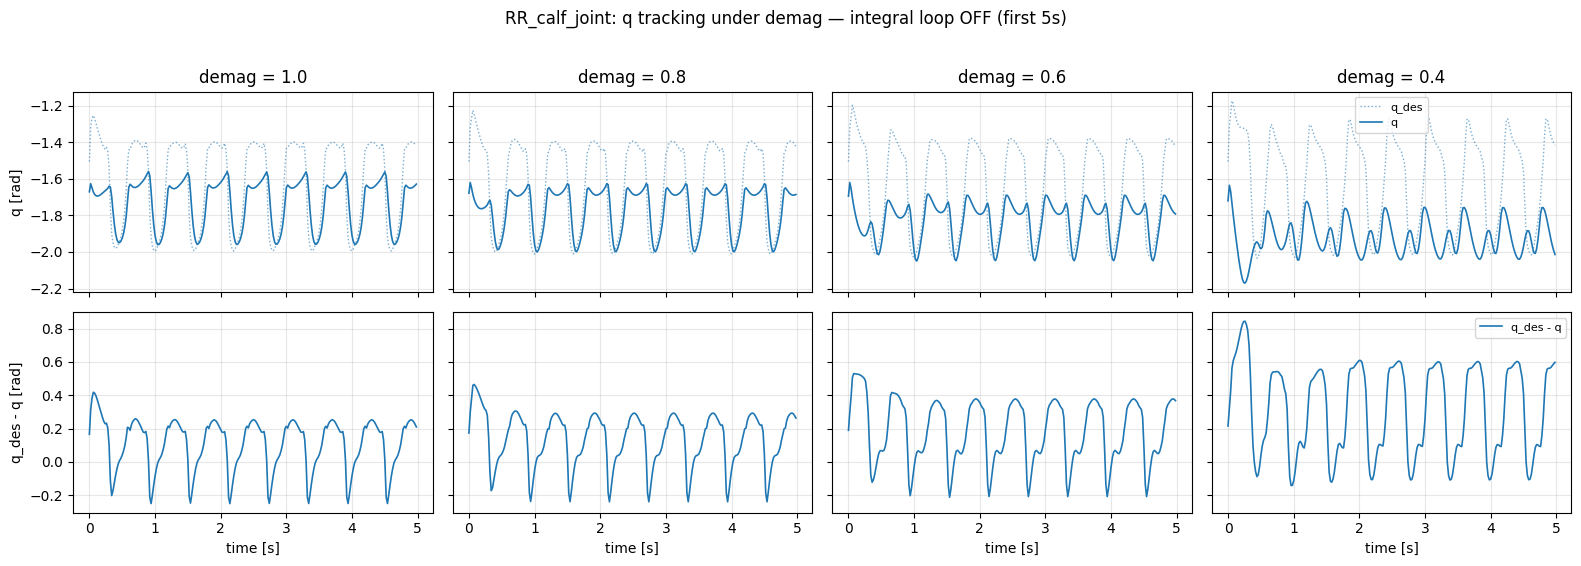

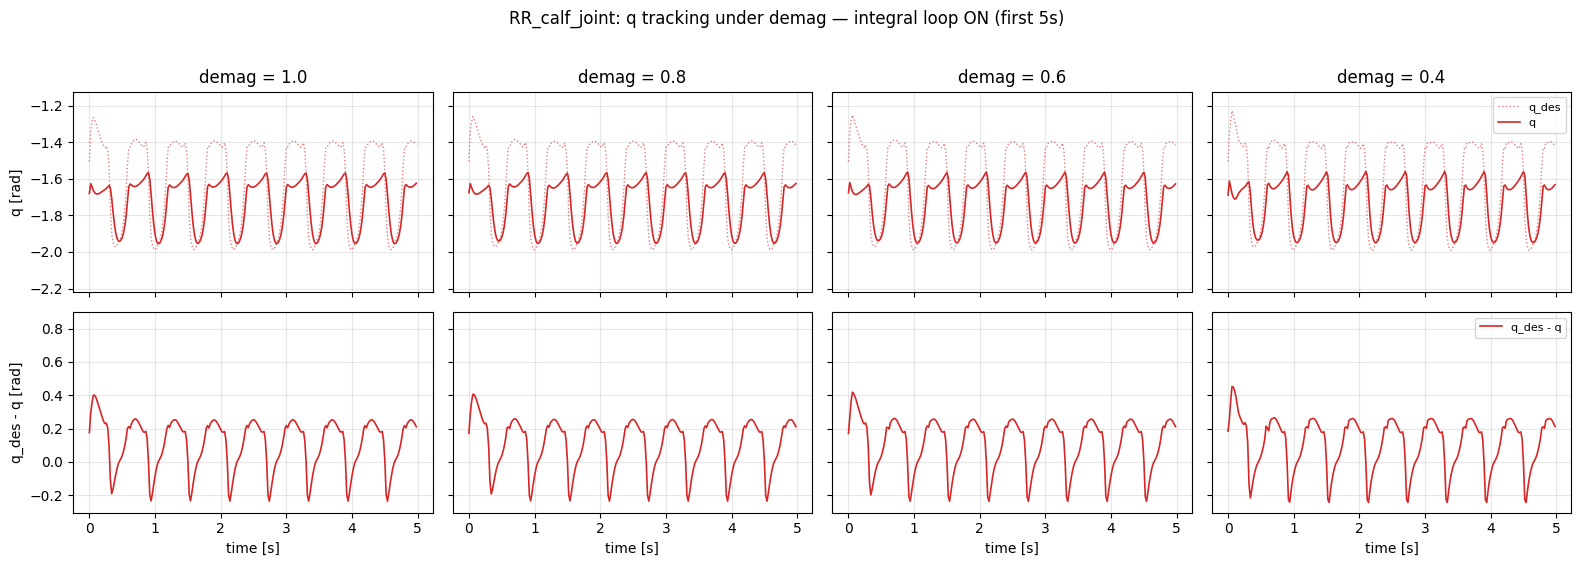

In [79]:
color = {'aplus': 'tab:blue', 'aplus_tloop_ki200': 'tab:red'}
label = {'aplus': 'integral loop OFF', 'aplus_tloop_ki200': 'integral loop ON'}

# 사용자 조절: 시계열 시간축 길이 [s]. None 이면 전체 시뮬 길이.
T_MAX_S = 5.0


def _q_ylims(t_max_s=None, pad=0.05):
    """OFF/ON × 모든 factor 를 t_max_s 윈도우로 잘라 행별 글로벌 y-범위 산출."""
    q_lo, q_hi = +np.inf, -np.inf
    e_lo, e_hi = +np.inf, -np.inf
    for p in ('aplus', 'aplus_tloop_ki200'):
        for f in FACTORS:
            try:
                d, m = load_case(p, f)
            except FileNotFoundError:
                continue
            j = col_idx(m, JOINT)
            n = (m['num_steps'] if t_max_s is None
                 else min(m['num_steps'], int(round(t_max_s / m['dt']))))
            q_des = d['q_des'][:n, j]
            q     = d['q_all'][:n, j]
            err   = q_des - q
            q_lo = min(q_lo, float(np.min(q_des)), float(np.min(q)))
            q_hi = max(q_hi, float(np.max(q_des)), float(np.max(q)))
            e_lo = min(e_lo, float(np.min(err)))
            e_hi = max(e_hi, float(np.max(err)))
    def expand(lo, hi):
        m = pad * (hi - lo if hi > lo else 1.0)
        return lo - m, hi + m
    return expand(q_lo, q_hi), expand(e_lo, e_hi)


def plot_q_tracking(policy: str, t_max_s=None):
    if t_max_s is None:
        t_max_s = T_MAX_S
    Q_YLIM, E_YLIM = _q_ylims(t_max_s)
    fig, axes = plt.subplots(2, len(FACTORS), figsize=(4*len(FACTORS), 5.5),
                             sharex=True, sharey='row')
    for ci, f in enumerate(FACTORS):
        ax_top = axes[0, ci]
        ax_bot = axes[1, ci]
        try:
            d, m = load_case(policy, f)
        except FileNotFoundError:
            ax_top.set_title(f'demag = {f} (missing)')
            continue
        j = col_idx(m, JOINT)
        n = (m['num_steps'] if t_max_s is None
             else min(m['num_steps'], int(round(t_max_s / m['dt']))))
        t = np.arange(n) * m['dt']
        q_des = d['q_des'][:n, j]
        q     = d['q_all'][:n, j]
        ax_top.plot(t, q_des, color=color[policy], ls=':', lw=1.0, alpha=0.6,
                    label='q_des')
        ax_top.plot(t, q,     color=color[policy], ls='-', lw=1.2,
                    label='q')
        ax_bot.plot(t, q_des - q, color=color[policy], lw=1.2,
                    label='q_des - q')
        ax_top.set_title(f'demag = {f}')
        ax_top.grid(alpha=0.3)
        ax_bot.grid(alpha=0.3)
        if ci == 0:
            ax_top.set_ylabel('q [rad]')
            ax_bot.set_ylabel('q_des - q [rad]')
        ax_bot.set_xlabel('time [s]')
    axes[0, 0].set_ylim(*Q_YLIM)
    axes[1, 0].set_ylim(*E_YLIM)
    axes[0, -1].legend(fontsize=8, loc='best')
    axes[1, -1].legend(fontsize=8, loc='best')
    win_str = f' (first {t_max_s:.0f}s)' if t_max_s is not None else ''
    fig.suptitle(f'{JOINT}: q tracking under demag — {label[policy]}{win_str}', y=1.02)
    fig.tight_layout()
    return fig


fig_off = plot_q_tracking('aplus')
fig_on  = plot_q_tracking('aplus_tloop_ki200')


## 3. 토크 / 전류 신호 — 진단 feature 검증 (OFF / ON 별도 그림)

OFF 케이스에서는 τ_actual = α·τ_cmd 로 갈라지고, ON 케이스에서는 τ_actual ≈ τ_cmd 가 유지되며 대신 I_cmd / I_actual 이 ≈ 1/α 배로 부풀어야 함. 각 정책을 **별도 figure**로 분리.

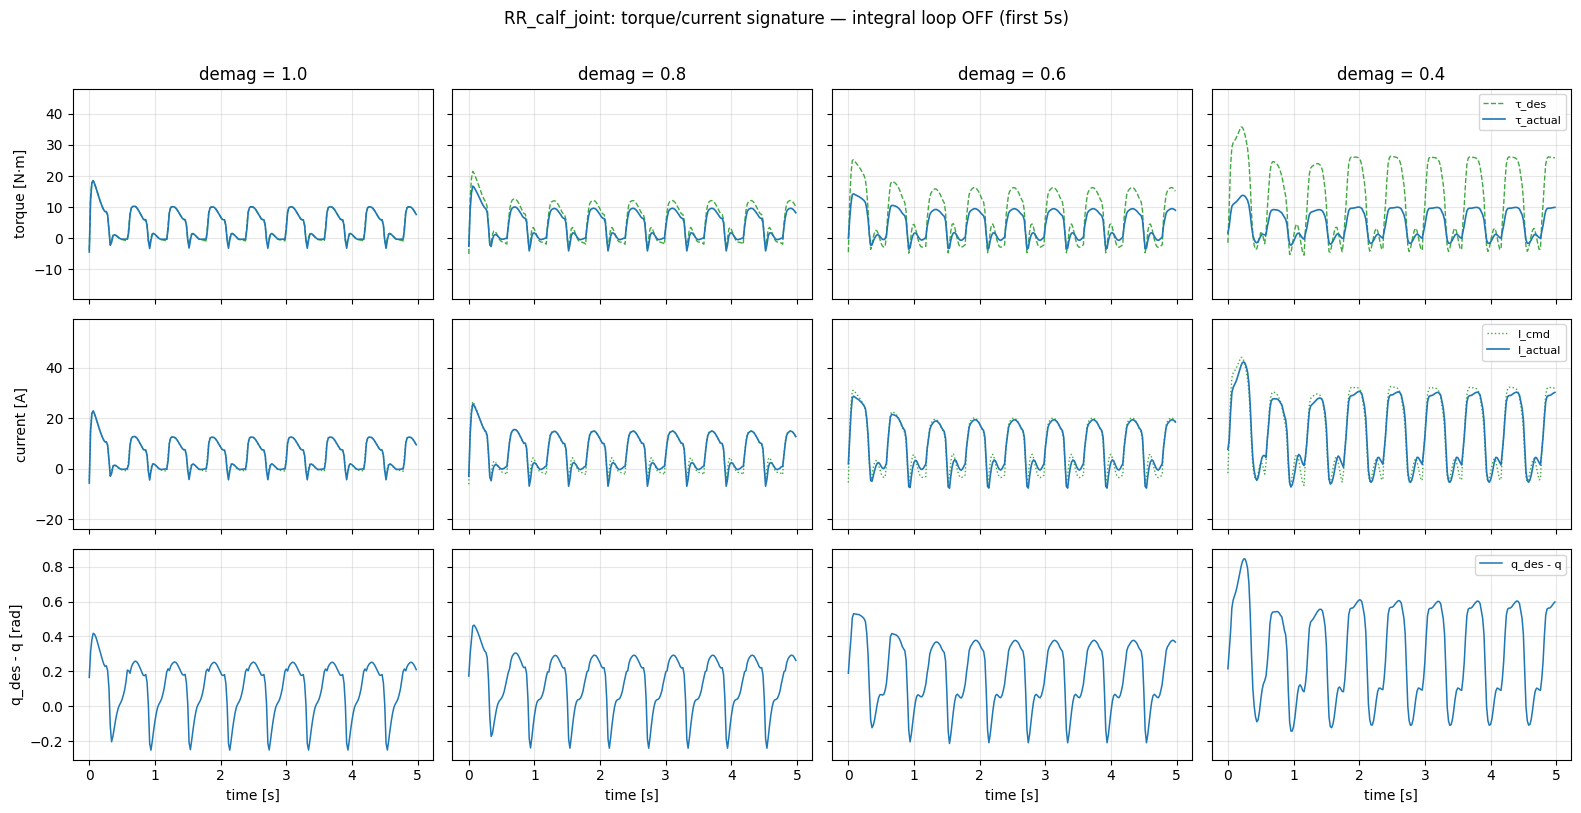

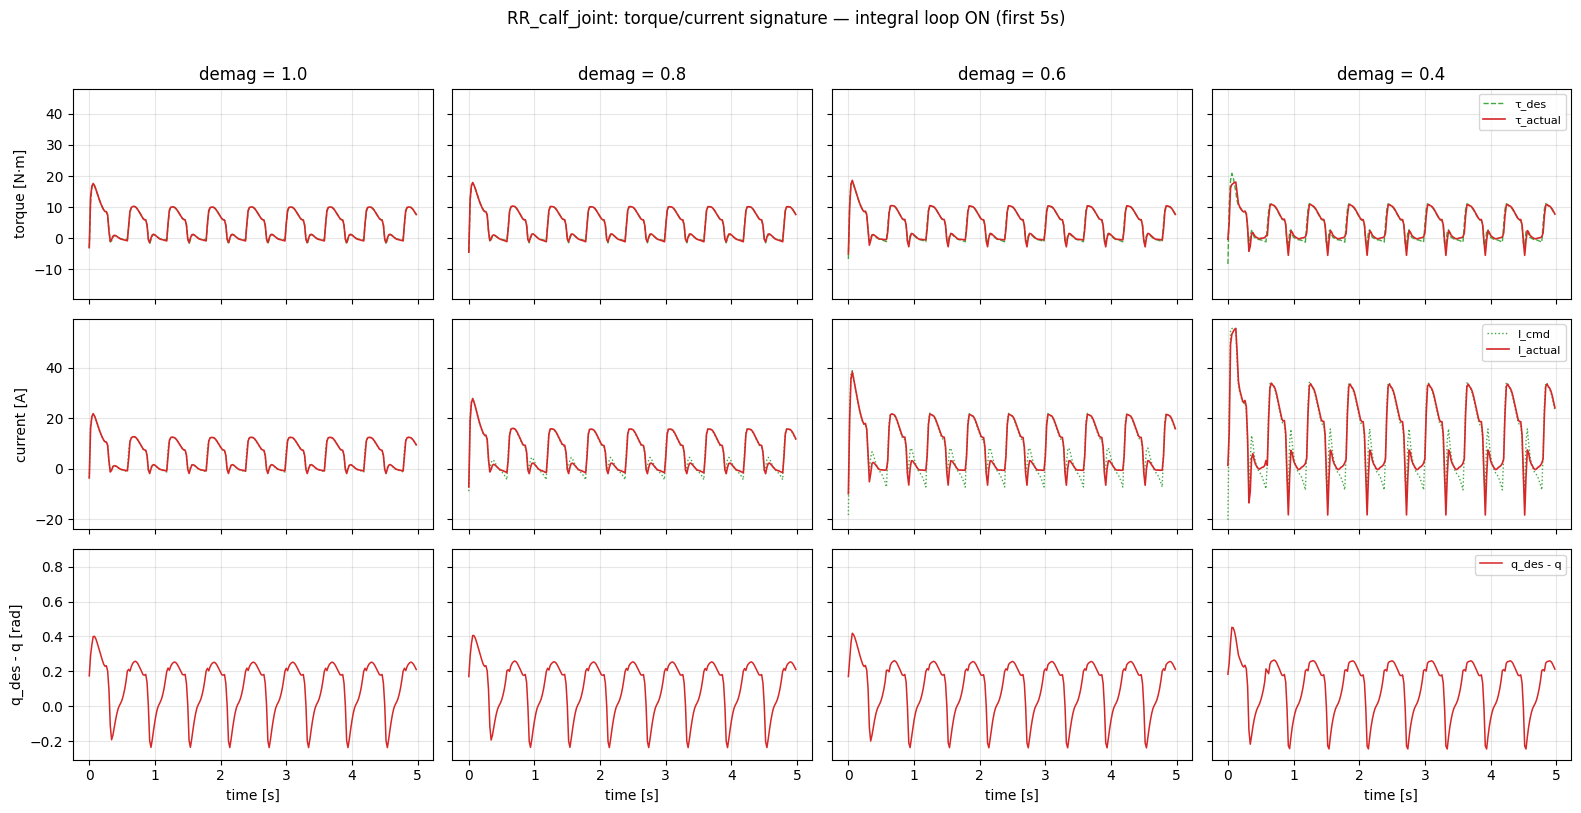

In [80]:
# 신호별 색 (정책색은 actual 라인에만 사용 — des/cmd 는 정책 무관 고정색).
SIG_COLOR = {
    'tau_des': 'tab:green',    # PD + DC envelope 출력
    'tau_cmd': 'tab:green',   # ctrl × Kt_nom (V_bus clamp 후, 적분 보정 포함)
    'I_cmd':   'tab:green',
}

# T_MAX_S 는 cell-5 에서 정의. 여기서 별도 지정도 가능.


def _tau_I_ylims(t_max_s=None, pad=0.05):
    """OFF/ON × 모든 factor 를 t_max_s 윈도우로 잘라 행별 글로벌 y-범위 산출."""
    tau_lo, tau_hi = +np.inf, -np.inf
    I_lo,   I_hi   = +np.inf, -np.inf
    e_lo,   e_hi   = +np.inf, -np.inf
    for p in ('aplus', 'aplus_tloop_ki200'):
        for f in FACTORS:
            try:
                d, m = load_case(p, f)
            except FileNotFoundError:
                continue
            j = col_idx(m, JOINT)
            n = (m['num_steps'] if t_max_s is None
                 else min(m['num_steps'], int(round(t_max_s / m['dt']))))
            tau_lo = min(tau_lo,
                         float(np.min(d['tau_cmd'][:n, j])),
                         float(np.min(d['tau_des'][:n, j])),
                         float(np.min(d['tau_actual'][:n, j])))
            tau_hi = max(tau_hi,
                         float(np.max(d['tau_cmd'][:n, j])),
                         float(np.max(d['tau_des'][:n, j])),
                         float(np.max(d['tau_actual'][:n, j])))
            I_lo = min(I_lo, float(np.min(d['I_cmd'][:n, j])),
                       float(np.min(d['I_actual'][:n, j])))
            I_hi = max(I_hi, float(np.max(d['I_cmd'][:n, j])),
                       float(np.max(d['I_actual'][:n, j])))
            err = d['q_des'][:n, j] - d['q_all'][:n, j]
            e_lo = min(e_lo, float(np.min(err)))
            e_hi = max(e_hi, float(np.max(err)))
    def expand(lo, hi):
        m = pad * (hi - lo if hi > lo else 1.0)
        return lo - m, hi + m
    return expand(tau_lo, tau_hi), expand(I_lo, I_hi), expand(e_lo, e_hi)


def plot_torque_current(policy: str, t_max_s=None):
    if t_max_s is None:
        t_max_s = T_MAX_S
    TAU_YLIM, I_YLIM, QE_YLIM = _tau_I_ylims(t_max_s)
    fig, axes = plt.subplots(3, len(FACTORS), figsize=(4*len(FACTORS), 8.0),
                             sharex=True, sharey='row')
    for ci, f in enumerate(FACTORS):
        ax_tau = axes[0, ci]
        ax_I   = axes[1, ci]
        ax_qe  = axes[2, ci]
        try:
            d, m = load_case(policy, f)
        except FileNotFoundError:
            ax_tau.set_title(f'demag = {f} (missing)')
            continue
        j = col_idx(m, JOINT)
        n = (m['num_steps'] if t_max_s is None
             else min(m['num_steps'], int(round(t_max_s / m['dt']))))
        t = np.arange(n) * m['dt']
        ax_tau.plot(t, d['tau_des'][:n, j],    color=SIG_COLOR['tau_des'], ls='--', lw=1.0, alpha=0.9,
                    label='τ_des')
        # ax_tau.plot(t, d['tau_cmd'][:n, j],    color=SIG_COLOR['tau_cmd'], ls=':',  lw=1.0, alpha=0.9,
        #             label='τ_cmd')
        ax_tau.plot(t, d['tau_actual'][:n, j], color=color[policy], ls='-', lw=1.2,
                    label='τ_actual')
        ax_I.plot(t, d['I_cmd'][:n, j],    color=SIG_COLOR['I_cmd'], ls=':', lw=1.0, alpha=0.9,
                  label='I_cmd')
        ax_I.plot(t, d['I_actual'][:n, j], color=color[policy], ls='-', lw=1.2,
                  label='I_actual')
        ax_qe.plot(t, d['q_des'][:n, j] - d['q_all'][:n, j], color=color[policy], lw=1.1,
                   label='q_des - q')
        ax_tau.set_title(f'demag = {f}')
        for ax in (ax_tau, ax_I, ax_qe):
            ax.grid(alpha=0.3)
        if ci == 0:
            ax_tau.set_ylabel('torque [N·m]')
            ax_I.set_ylabel('current [A]')
            ax_qe.set_ylabel('q_des - q [rad]')
        ax_qe.set_xlabel('time [s]')
    axes[0, 0].set_ylim(*TAU_YLIM)
    axes[1, 0].set_ylim(*I_YLIM)
    axes[2, 0].set_ylim(*QE_YLIM)
    axes[0, -1].legend(fontsize=8, loc='best')
    axes[1, -1].legend(fontsize=8, loc='best')
    axes[2, -1].legend(fontsize=8, loc='best')
    win_str = f' (first {t_max_s:.0f}s)' if t_max_s is not None else ''
    fig.suptitle(f'{JOINT}: torque/current signature — {label[policy]}{win_str}', y=1.01)
    fig.tight_layout()
    return fig


fig_off = plot_torque_current('aplus')
fig_on  = plot_torque_current('aplus_tloop_ki200')


## 3'. 적분기 정착(수렴) 분석 — `aplus_tloop`

### 분석 방향
1. **상대비 정착 임계** — healthy 절대값이 아닌, 자기 자신의 tail mean 의 90 % 라이즈 / 90 % 디케이로 정착 시점을 정의. α=1.0 은 tail≈0 이라 정착 정의 불가 → NaN, "정착 무의미" 로 표시.
2. **1차 시스템 fit** — `I_int(t) ≈ I_int_ss · (1 − exp(−t/τ_loop))` 를 transient 에 `scipy.optimize.curve_fit` 로 피팅. 측정 τ_loop_fit 와 이론 τ_loop_theory 비교.
3. **Overshoot / peak metric** — peak |I_int|, peak time, overshoot ratio, 적분 도메인 환산 (peak / Ki), integral_max 대비 % 표.

### 이론
적분 동역학 (V_bus = ∞ 가정 하 정확):
$$
\frac{d}{dt}\,\text{integral} \;=\; (1-\alpha)\,\tau_\text{des} \;-\; \alpha\,K_t\,g_r\,K_i \cdot \text{integral}.
$$
1차 LTI → 시상수
$$
\tau_\text{loop} \;=\; \frac{1}{\alpha\,K_t\,g_r\,K_i} \;=\; \frac{1}{\alpha \cdot 0.81 \cdot 50}.
$$
α=0.8 → 30.9 ms, α=0.6 → 41.2 ms, α=0.4 → 61.7 ms.

정상상태:
$$
\text{integral}_\text{ss} \;=\; \frac{(1-\alpha)\,\tau_\text{des}}{\alpha\,K_t\,g_r\,K_i},
\qquad
I_\text{int,ss} \;=\; K_i\,\text{integral}_\text{ss} \;=\; \Big(\tfrac{1}{\alpha}-1\Big)\,I_\text{des,base}.
$$

### Windup 모니터링
α=0.4 처럼 transient peak 가 정상상태값보다 크게 부풀면 적분기가 anti-windup 클램프(`integral_max=0.5 A·s`, `Ki·integral_max=25 A`) 에 닿을 위험이 있다. 이를 직접 비교.

=== Settling table (relative thresholds, dwell 0.3s) ===
  rolling window = 1.0s, tail = last 5.0s
  alpha=1.0 -> |I_int_tail| < 0.1 A: settling undefined (NaN)
  healthy <|err|>_tail = 0.189 N*m (reference)


,t_err_90% [s],t_int_90% [s],I_int tail [A],I_int predicted [A],tail vs pred [%]
factor,,,,,
1.000000,-,-,0.008,0.000,-
0.800000,0.440,0.320,1.186,1.256,-5.575
0.600000,0.700,0.320,3.176,3.390,-6.316
0.400000,1.300,0.320,7.382,7.923,-6.828



=== Peak / overshoot table (windup risk) ===
  integrator cap = K_i * integral_max = 50 * 0.5 = 25.0 A


,peak |I_int| [A],t_peak [s],overshoot peak/tail,peak integral [A*s],%-of-integral_max,clipped
factor,,,,,,
1.000000,1.356,0.040,-,0.027,5.423,False
0.800000,4.080,0.140,3.441,0.082,16.318,False
0.600000,10.195,0.160,3.210,0.204,40.779,False
0.400000,20.382,0.240,2.761,0.408,81.527,False



=== 1st-order fit table ===
  Theory: tau_loop = 1 / (alpha * K_t*g_r * K_i) = 1 / (alpha * 0.8102 * 50)
  Fit fallback: window 2.0 s -> 5*tau_th -> 3*tau_th, sanity 0.2 < tau_fit/tau_th < 5.0


,tau_loop_fit [ms],tau_loop_theory [ms],tau ratio fit/theory,I_ss_fit [A],I_ss_predicted [A],fit window [s]
factor,,,,,,
1.000000,-,24.684,-,-,0.000,-
0.800000,13.195,30.855,0.428,1.892,1.256,2.000
0.600000,19.928,41.140,0.484,4.925,3.390,2.000
0.400000,21.977,61.710,0.356,10.733,7.923,2.000


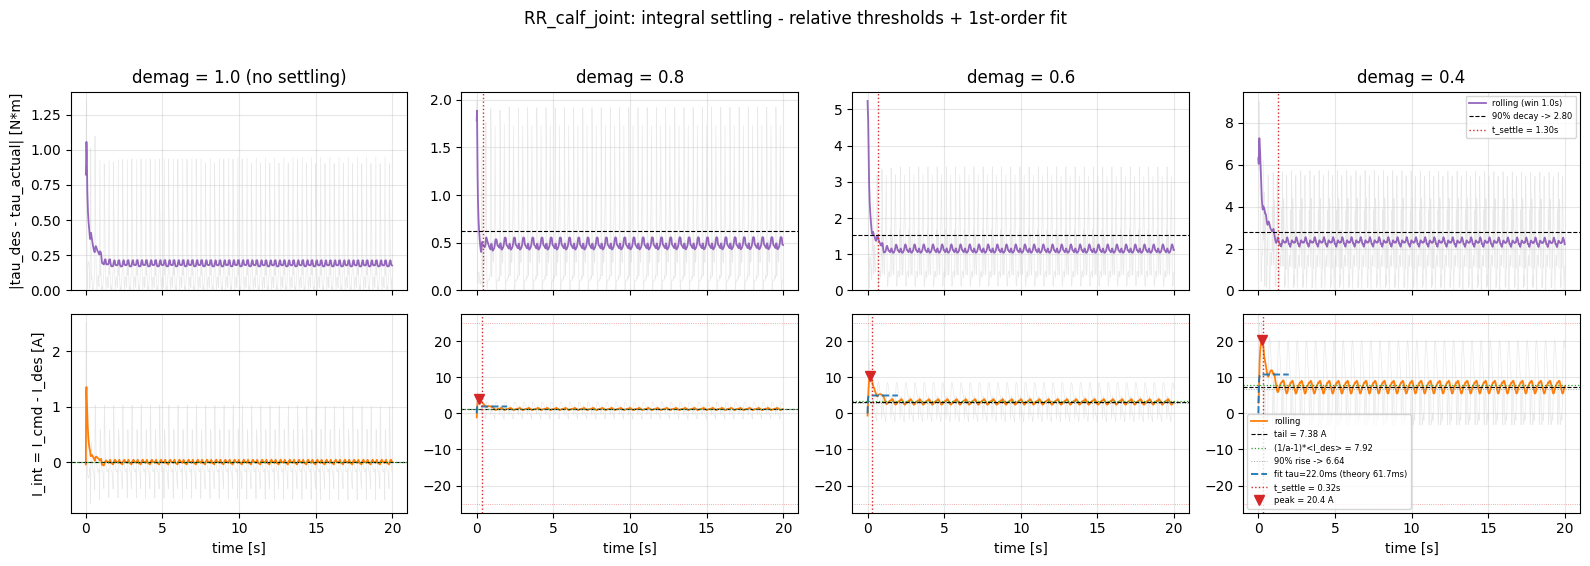

In [81]:
# ═══════════════════════════════════════════════════════════════════════
#  적분 루프 정착 분석 — relative thresholds + 1st-order fit + peak metrics
#  단일 출처: 모든 cfg 상수는 이 셀 상단에서만 정의.
#  go2_constants.py:_APLUS_TLOOP_MOTOR 와 동기화 필요.
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import display
from scipy.optimize import curve_fit

# ── 물리 / cfg 상수 (single source of truth) ──────────────────────
KT      = 0.128                  # [N·m / A]   토크 상수
GR      = 6.33                   #             감속비
KT_GR   = KT * GR                # ≈ 0.8102    joint torque per amp
KI      = 50.0                   # [(A·s)/(N·m·s)]  적분 게인
INTEGRAL_MAX = 0.5               # [A·s]       anti-windup 클램프
I_INT_CAP    = KI * INTEGRAL_MAX  # 25.0 A     적분 기여 전류 상한

# ── 분석 파라미터 ────────────────────────────────────────────────
WIN_S          = 1.0             # rolling-mean 윈도우 [s]
TAIL_S         = 5.0             # 정상상태 추정 tail 윈도우 [s]
PEAK_PROBE_S   = 1.0             # |err| transient peak 탐색 [s]
RISE_FRAC      = 0.9             # 90 % rise / 90 % decay
TAIL_NEAR_ZERO = 0.1             # |I_int_tail| < 이 값이면 정착 정의 불가 (α=1)
DWELL_S        = 0.3             # 임계 통과 후 머무름 [s]


# ── 헬퍼 ─────────────────────────────────────────────────────────
def rolling_mean(x, win):
    """Right-aligned 이동평균 (앞 인덱스는 짧은 평균)."""
    x = np.asarray(x, dtype=np.float64)
    cs = np.concatenate(([0.0], np.cumsum(x)))
    out = np.empty_like(x)
    for i in range(len(x)):
        a = max(0, i + 1 - win)
        out[i] = (cs[i + 1] - cs[a]) / (i + 1 - a)
    return out


def first_order_step(t, I_ss, tau):
    return I_ss * (1.0 - np.exp(-t / tau))


def first_cross_dwell(signal, threshold, sign, dwell):
    """sign·(signal − threshold) ≥ 0 이 dwell step 연속되는 첫 인덱스."""
    cond = (signal >= threshold) if sign >= 0 else (signal <= threshold)
    if cond.size < dwell:
        return None
    cnt = 0
    for i, c in enumerate(cond):
        cnt = cnt + 1 if c else 0
        if cnt >= dwell:
            return i - dwell + 1
    return None


def fit_first_order(t_arr, sig, tau_th, ss_guess):
    """전체 → 좁은 윈도우 순으로 fallback 시도. 반환 (I_ss, tau, win_used)|None.

    candidates: 2.0 s (overshoot 포함), 5·τ_th (~95 % settled), 3·τ_th (rise 위주).
    sanity: 0.2 < τ_fit/τ_th < 5.0 통과 첫 결과 채택."""
    dt_local = float(t_arr[1] - t_arr[0])
    candidates = [2.0,
                  max(0.5, 5.0 * tau_th),
                  max(0.3, 3.0 * tau_th)]
    for end_t in candidates:
        n = int(round(end_t / dt_local))
        n = max(4, min(n, len(t_arr)))
        try:
            popt, _ = curve_fit(
                first_order_step, t_arr[:n], sig[:n],
                p0=[ss_guess, max(tau_th, 1e-3)],
                bounds=([-np.inf, 1e-4], [np.inf, 10.0]),
                maxfev=5000,
            )
            ratio = popt[1] / max(tau_th, 1e-9)
            if 0.2 < ratio < 5.0:
                return float(popt[0]), float(popt[1]), float(end_t)
        except Exception:
            continue
    return None


# ── healthy(α=1.0) 의 err tail 평균 (참고용) ──────────────────────
d_h, m_h = load_case('aplus_tloop_ki200', 1.0)
j_h = col_idx(m_h, JOINT)
dt_h = float(m_h['dt'])
win_h = max(1, int(round(WIN_S / dt_h)))
err_h_s = rolling_mean(np.abs(d_h['tau_des'][:, j_h] - d_h['tau_actual'][:, j_h]), win_h)
err_baseline_tail = float(np.mean(err_h_s[-int(round(TAIL_S/dt_h)):]))


# ── 그림 + per-factor 계산 ──────────────────────────────────────
# sharey 제거: demag 가 심해질수록 |err| / I_int 진폭이 커져 약한 패널을 가림.
# 각 factor 패널이 자기 신호 범위에 맞춰 자동 스케일하도록 둠.
fig, axes = plt.subplots(2, len(FACTORS), figsize=(4*len(FACTORS), 5.5),
                         sharex=True)

settle_rows = []
peak_rows   = []
fit_rows    = []

for ci, f in enumerate(FACTORS):
    try:
        d, m = load_case('aplus_tloop_ki200', f)
    except FileNotFoundError:
        for ax in axes[:, ci]:
            ax.set_title(f'demag = {f} (missing)')
        continue
    j = col_idx(m, JOINT)
    dt = float(m['dt'])
    t = np.arange(m['num_steps']) * dt
    win    = max(1, int(round(WIN_S / dt)))
    tail_n = int(round(TAIL_S / dt))
    peak_n = int(round(PEAK_PROBE_S / dt))
    dwell  = max(1, int(round(DWELL_S / dt)))

    err   = np.abs(d['tau_des'][:, j] - d['tau_actual'][:, j])
    I_int = d['I_cmd'][:, j] - d['I_des'][:, j]
    err_s  = rolling_mean(err, win)
    Iint_s = rolling_mean(I_int, win)

    # 정상상태 추정
    err_tail   = float(np.mean(err_s[-tail_n:]))
    Iint_tail  = float(np.mean(Iint_s[-tail_n:]))
    Idesb_tail = float(np.mean(d['I_des'][:, j][-tail_n:]))
    Iint_predicted = (1.0/f - 1.0) * Idesb_tail if f > 0 else float('nan')
    tau_theory = 1.0 / (f * KT_GR * KI) if f > 0 else float('nan')

    settling_meaningful = abs(Iint_tail) >= TAIL_NEAR_ZERO

    # ─── 정착 시점 (relative-ratio 방식) ───────────────────────
    if settling_meaningful:
        sign  = +1 if Iint_tail > 0 else -1
        I_thr = RISE_FRAC * Iint_tail
        idx = first_cross_dwell(Iint_s, I_thr, sign=sign, dwell=dwell)
        t_int_settle = (idx + dwell - 1) * dt if idx is not None else float('nan')

        peak_t_idx = int(np.argmax(err_s[:peak_n]))
        peak_err   = float(err_s[peak_t_idx])
        err_thr    = 0.1 * (peak_err - err_tail) + err_tail
        idx_e = first_cross_dwell(err_s[peak_t_idx:], err_thr, sign=-1, dwell=dwell)
        t_err_settle = ((peak_t_idx + idx_e + dwell - 1) * dt
                        if idx_e is not None else float('nan'))
    else:
        t_int_settle = float('nan')
        t_err_settle = float('nan')
        peak_err     = float('nan')
        err_thr      = float('nan')
        I_thr        = float('nan')

    # ─── peak / overshoot ──────────────────────────────────────
    pidx          = int(np.argmax(np.abs(Iint_s)))
    peak_signed   = float(Iint_s[pidx])
    peak_abs      = abs(peak_signed)
    peak_t        = pidx * dt
    overshoot     = (peak_signed / Iint_tail) if settling_meaningful else float('nan')
    peak_integral = peak_abs / KI                                # [A·s]
    peak_pct      = peak_integral / INTEGRAL_MAX * 100.0
    clipped       = peak_integral >= INTEGRAL_MAX - 1e-6

    # ─── 1차계 fit ─────────────────────────────────────────────
    if settling_meaningful:
        res = fit_first_order(t, Iint_s, tau_theory, Iint_tail)
        if res is not None:
            Iss_fit, tau_fit, win_used = res
            n_fit       = int(round(win_used / dt))
            t_fit_grid  = t[:n_fit]
            fit_curve   = first_order_step(t_fit_grid, Iss_fit, tau_fit)
        else:
            Iss_fit, tau_fit = float('nan'), float('nan')
            t_fit_grid, fit_curve, win_used = None, None, float('nan')
    else:
        Iss_fit, tau_fit = float('nan'), float('nan')
        t_fit_grid, fit_curve, win_used = None, None, float('nan')

    # ─── 그림 ──────────────────────────────────────────────────
    ax_err = axes[0, ci]
    ax_int = axes[1, ci]

    ax_err.plot(t, err, color='lightgray', lw=0.5, alpha=0.5)
    ax_err.plot(t, err_s, color='tab:purple', lw=1.3,
                label=f'rolling (win {WIN_S:.1f}s)')
    if not np.isnan(err_thr):
        ax_err.axhline(err_thr, color='k', ls='--', lw=0.8,
                       label=f'90% decay -> {err_thr:.2f}')
    if not np.isnan(t_err_settle):
        ax_err.axvline(t_err_settle, color='tab:red', ls=':', lw=1.0,
                       label=f't_settle = {t_err_settle:.2f}s')
    title_extra = ' (no settling)' if not settling_meaningful else ''
    ax_err.set_title(f'demag = {f}{title_extra}')
    ax_err.grid(alpha=0.3)
    ax_err.set_ylim(bottom=0)

    ax_int.plot(t, I_int, color='lightgray', lw=0.5, alpha=0.5)
    ax_int.plot(t, Iint_s, color='tab:orange', lw=1.3, label='rolling')
    ax_int.axhline(Iint_tail, color='k', ls='--', lw=0.8,
                   label=f'tail = {Iint_tail:.2f} A')
    if not np.isnan(Iint_predicted):
        ax_int.axhline(Iint_predicted, color='tab:green', ls=':', lw=0.9,
                       label=f'(1/a-1)*<I_des> = {Iint_predicted:.2f}')
    if not np.isnan(I_thr):
        ax_int.axhline(I_thr, color='gray', ls=':', lw=0.7, alpha=0.7,
                       label=f'90% rise -> {I_thr:.2f}')
    if fit_curve is not None:
        ax_int.plot(t_fit_grid, fit_curve, color='tab:blue', ls='--', lw=1.4, alpha=0.95,
                    label=f'fit tau={tau_fit*1000:.1f}ms (theory {tau_theory*1000:.1f}ms)')
    if not np.isnan(t_int_settle):
        ax_int.axvline(t_int_settle, color='tab:red', ls=':', lw=1.0,
                       label=f't_settle = {t_int_settle:.2f}s')
    if settling_meaningful:
        ax_int.plot(peak_t, peak_signed, 'v', color='tab:red', ms=7,
                    label=f'peak = {peak_signed:.1f} A')
        # 적분기 천장 (Ki·integral_max = 25 A) 점선 (참고)
        ax_int.axhline(I_INT_CAP, color='tab:red', ls=':', lw=0.6, alpha=0.5)
        ax_int.axhline(-I_INT_CAP, color='tab:red', ls=':', lw=0.6, alpha=0.5)
    ax_int.grid(alpha=0.3)
    ax_int.set_xlabel('time [s]')

    if ci == 0:
        ax_err.set_ylabel('|tau_des - tau_actual| [N*m]')
        ax_int.set_ylabel('I_int = I_cmd - I_des [A]')

    settle_rows.append({
        'factor': f,
        't_err_90% [s]':         t_err_settle,
        't_int_90% [s]':         t_int_settle,
        'I_int tail [A]':        Iint_tail,
        'I_int predicted [A]':   Iint_predicted,
        'tail vs pred [%]':      ((Iint_tail - Iint_predicted) / Iint_predicted * 100.0
                                  if abs(Iint_predicted) > 1e-6 else float('nan')),
    })
    peak_rows.append({
        'factor': f,
        'peak |I_int| [A]':       peak_abs,
        't_peak [s]':             peak_t,
        'overshoot peak/tail':    overshoot,
        'peak integral [A*s]':    peak_integral,
        '%-of-integral_max':      peak_pct,
        'clipped':                clipped,
    })
    fit_rows.append({
        'factor': f,
        'tau_loop_fit [ms]':    tau_fit * 1000.0,
        'tau_loop_theory [ms]': tau_theory * 1000.0,
        'tau ratio fit/theory': (tau_fit / tau_theory) if not np.isnan(tau_fit) else float('nan'),
        'I_ss_fit [A]':         Iss_fit,
        'I_ss_predicted [A]':   Iint_predicted,
        'fit window [s]':       win_used,
    })

axes[0, -1].legend(fontsize=6, loc='best')
axes[1, -1].legend(fontsize=6, loc='best')
fig.suptitle(f'{JOINT}: integral settling - relative thresholds + 1st-order fit', y=1.02)
fig.tight_layout()


# ── 표 출력 ────────────────────────────────────────────────────
print(f'=== Settling table (relative thresholds, dwell {DWELL_S:.1f}s) ===')
print(f'  rolling window = {WIN_S:.1f}s, tail = last {TAIL_S:.1f}s')
print(f'  alpha=1.0 -> |I_int_tail| < {TAIL_NEAR_ZERO} A: settling undefined (NaN)')
print(f'  healthy <|err|>_tail = {err_baseline_tail:.3f} N*m (reference)')
settle_df = pd.DataFrame(settle_rows).set_index('factor')
display(settle_df.style.format('{:.3f}', na_rep='-'))

print(f'\n=== Peak / overshoot table (windup risk) ===')
print(f'  integrator cap = K_i * integral_max = {KI:.0f} * {INTEGRAL_MAX} = {I_INT_CAP:.1f} A')
peak_df = pd.DataFrame(peak_rows).set_index('factor')
peak_fmt = {c: ('{}' if c == 'clipped' else '{:.3f}') for c in peak_df.columns}
display(peak_df.style.format(peak_fmt, na_rep='-'))

print(f'\n=== 1st-order fit table ===')
print(f'  Theory: tau_loop = 1 / (alpha * K_t*g_r * K_i) = 1 / (alpha * {KT_GR:.4f} * {KI:.0f})')
print(f'  Fit fallback: window 2.0 s -> 5*tau_th -> 3*tau_th, sanity 0.2 < tau_fit/tau_th < 5.0')
fit_df = pd.DataFrame(fit_rows).set_index('factor')
display(fit_df.style.format('{:.3f}', na_rep='-'))

## 3''. Cascade 가설 검증 — inner integrator vs outer policy loop

**핵심 질문**: demag 발생 시 정책 outer loop과 driver 적분기 inner loop 중 누가 먼저 보상하고, 어떤 시간 스케일로 협동하는가?

**가설**: cascade 구조라면 inner (driver, 시상수 ~30–60 ms 이론) 가 빠르게 먼저 반응하고, outer (정책 GRU + dynamics 응답) 는 자세 피드백을 받아 늦게 반응한다. 이전 분석에서 inner fit τ ≈ 13–22 ms 로 이론(31–62 ms)의 35–50 % 인데, 이는 outer 보상이 들어와 적분기가 봐야 할 error 가 빨리 줄어드는 효과일 가능성이 높음 — 본 분석으로 검증.

**신호 정의**:
- `inner_torque_comp = I_int · K_t·g_r = (I_cmd − I_des) · K_t·g_r` [N·m] — 적분기가 토크에 더한 양.
- `outer_torque_comp_A = τ_des(t) − ⟨τ_des⟩_healthy` [N·m] — 정책이 PD 출력을 healthy 정상상태 대비 얼마나 끌어올렸는지.
- `pos_error = q_des − q` [rad] — 정책이 q_des 를 끌어올린 효과의 직접 관찰 (PD 입력).

**정상상태 이론 (V_bus = ∞, 적분기 정착 후)**:
$$
\tau_\text{actual} \approx \tau_\text{des,policy} \quad\Longleftrightarrow\quad
\underbrace{(1-\alpha)\,\tau_\text{des}}_{\text{drop to fill}}
= \underbrace{\alpha\,K_t g_r K_i\,\text{integral}}_{\alpha\cdot\text{inner}}
\;+\;\alpha\,(\tau_\text{des} - \tau_\text{des,healthy})\;\text{(이론적 분해는 전제 다양, 표·그림으로 측정).}
$$

α=0.4 처럼 깊은 demag 에선 정상상태 inner share + outer share 가 (1−α)·⟨τ_des,healthy⟩ 부족분을 어떻게 메우는지가 핵심.

  joint = RR_calf_joint, kp = 40.0, kd = 2.0
  healthy <tau_des>_tail = 4.045 N*m

=== Cascade timing & share table (Definition A, zoom = first 5s) ===
  smoothing rolling window = 100 ms
  predicted_inner_ss = (1-a)/a * <tau_des>_healthy = (1-a)/a * 4.045
  cascade hypothesis -> t_peak_inner < t_peak_outer (or t_50 same).


,t_peak_inner [ms],t_peak_outer [ms],t_50_inner [ms],t_50_outer [ms],inner_ss [N*m],predicted_inner_ss [N*m],inner ratio meas/pred [%],outer_ss [N*m],inner share [%]
factor,,,,,,,,,
0.800000,120.00,120.00,20.00,0.00,0.98,1.01,97.03,-0.05,105.48
0.600000,140.00,120.00,40.00,0.00,2.63,2.70,97.40,-0.00,100.11
0.400000,160.00,120.00,20.00,40.00,6.10,6.07,100.45,0.16,97.49


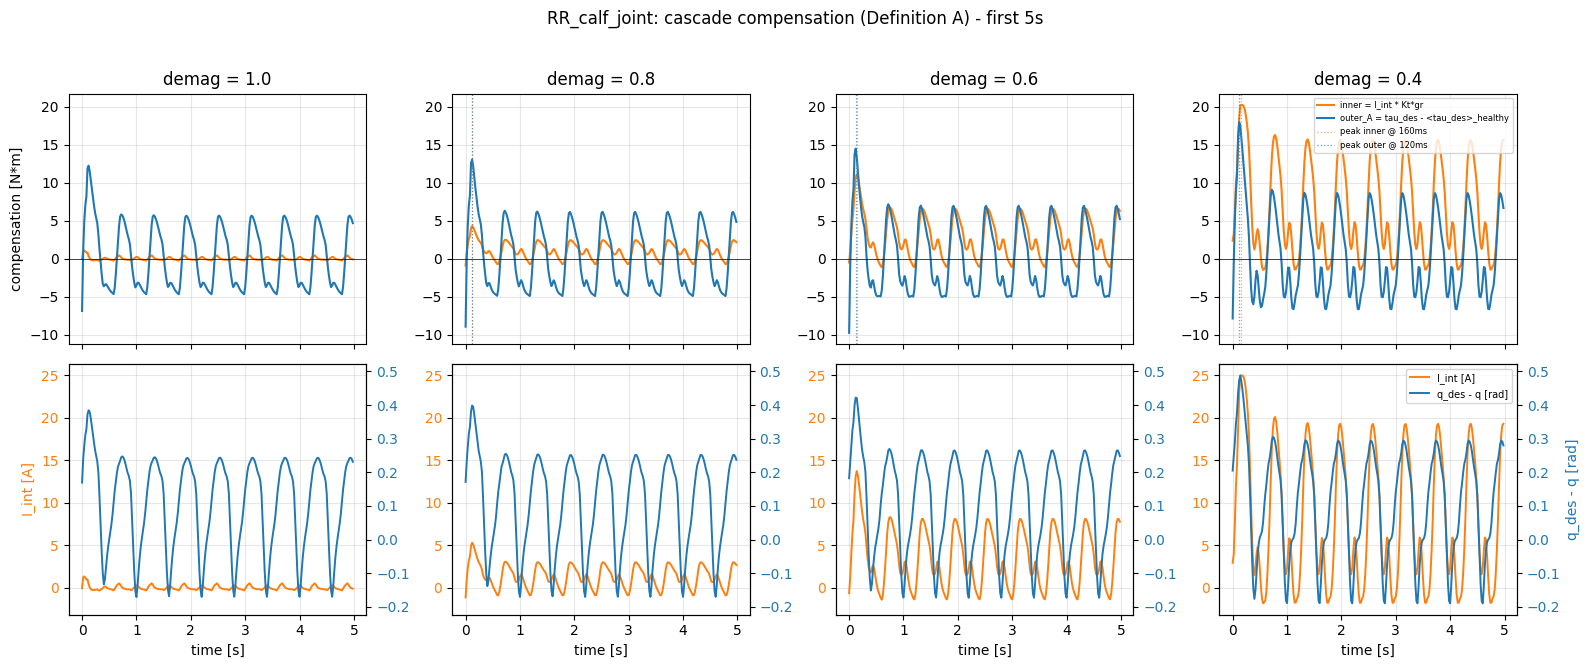

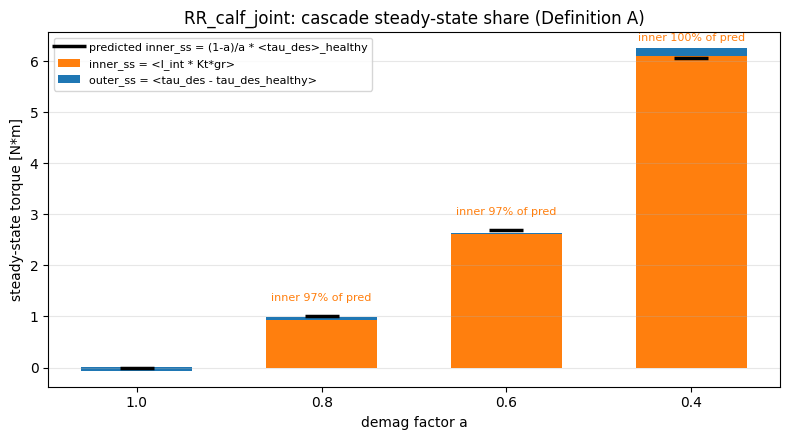

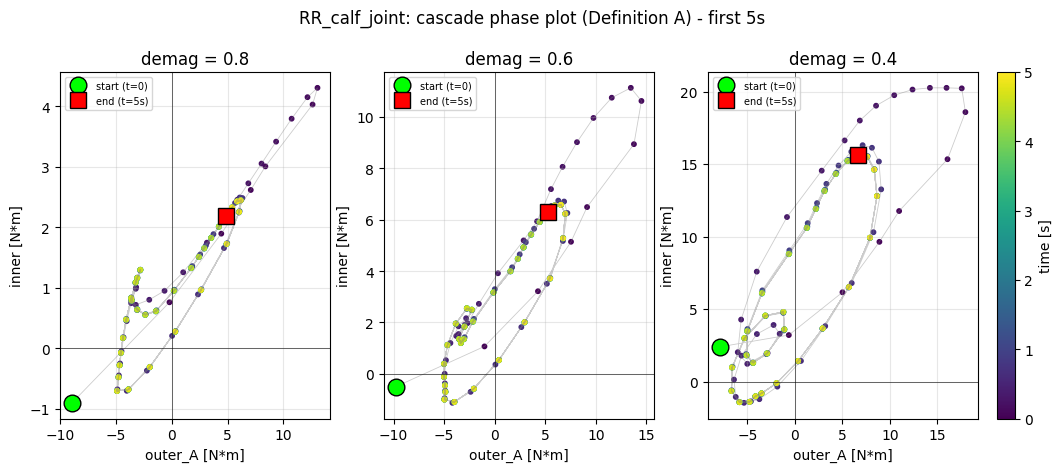

In [82]:
# ═══════════════════════════════════════════════════════════════════════
#  Cascade hypothesis: inner (integrator) vs outer (policy) compensation
#  cell-9 의 KT_GR, KI, rolling_mean, TAIL_S 를 그대로 사용 (cell-9 먼저 실행).
# ═══════════════════════════════════════════════════════════════════════
import matplotlib as mpl

# PD gains (go2_constants.py:_APLUS_TLOOP_*) — joint type → (kp, kd)
PD_GAINS = {
    'hip':   (20.0, 1.0),
    'thigh': (20.0, 1.0),
    'calf':  (40.0, 2.0),
}
def get_pd_gains(joint_name):
    for kw, g in PD_GAINS.items():
        if kw in joint_name:
            return g
    return PD_GAINS['calf']

CASCADE_SMOOTH_S = 0.1   # rolling-mean window for plot smoothing [s]
CASCADE_ZOOM_S   = 5.0   # rising edge zoom [s]


# ── Per-joint cascade analysis function ─────────────────────────
def cascade_analysis(joint=JOINT, factors=FACTORS):
    """Return (cases dict, healthy tau_des steady-state, smooth_n)."""
    smooth_n = max(1, int(round(CASCADE_SMOOTH_S / 0.020)))

    d_h, m_h = load_case('aplus_tloop_ki200', 1.0)
    j_h = col_idx(m_h, joint)
    dt_h = float(m_h['dt'])
    tail_h_n = int(round(TAIL_S / dt_h))
    tau_des_h_ss = float(np.mean(d_h['tau_des'][:, j_h][-tail_h_n:]))

    cases = {}
    for f in factors:
        try:
            d, m = load_case('aplus_tloop_ki200', f)
        except FileNotFoundError:
            continue
        j = col_idx(m, joint)
        dt = float(m['dt'])
        kp, kd = get_pd_gains(joint)
        n = m['num_steps']
        t = np.arange(n) * dt

        I_int    = d['I_cmd'][:, j] - d['I_des'][:, j]
        inner_tc = I_int * KT_GR
        outer_tc = d['tau_des'][:, j] - tau_des_h_ss
        pos_err  = d['q_des'][:, j] - d['q_all'][:, j]

        cases[f] = {
            't': t, 'dt': dt, 'kp': kp, 'kd': kd,
            'I_int':           rolling_mean(I_int, smooth_n),
            'inner_torque':    rolling_mean(inner_tc, smooth_n),
            'outer_torque_A':  rolling_mean(outer_tc, smooth_n),
            'pos_err':         rolling_mean(pos_err, smooth_n),
            'pos_err_torque':  rolling_mean(kp * pos_err, smooth_n),
            'tau_des':         rolling_mean(d['tau_des'][:, j], smooth_n),
            'tau_actual':      rolling_mean(d['tau_actual'][:, j], smooth_n),
            # Raw (non-smoothed) for downstream signals (e.g. q_des, qd_all access)
            '_d':              d, '_j': j, '_m': m,
        }
    return cases, tau_des_h_ss, smooth_n


cases, tau_des_h_ss, smooth_n = cascade_analysis(JOINT)
print(f'  joint = {JOINT}, kp = {get_pd_gains(JOINT)[0]}, kd = {get_pd_gains(JOINT)[1]}')
print(f'  healthy <tau_des>_tail = {tau_des_h_ss:.3f} N*m')


# ════════════════════════════════════════════════════════════════════
#  그림 1 — rising edge zoom (4 panels x 2 rows, Definition A)
# ════════════════════════════════════════════════════════════════════
# ── Compute global y-ranges for unified comparison across factors ──
def _comp_ranges(cases, key_outer='outer_torque_A', key_pe='pos_err',
                 zoom_s=CASCADE_ZOOM_S, pad=0.05):
    comp_lo = iint_lo = pe_lo = +np.inf
    comp_hi = iint_hi = pe_hi = -np.inf
    for f, c in cases.items():
        zn = int(round(zoom_s / c['dt']))
        inner = c['inner_torque'][:zn]; outer = c[key_outer][:zn]
        Iint  = c['I_int'][:zn];        pe    = c[key_pe][:zn]
        comp_lo = min(comp_lo, float(inner.min()), float(outer.min()))
        comp_hi = max(comp_hi, float(inner.max()), float(outer.max()))
        iint_lo = min(iint_lo, float(Iint.min()))
        iint_hi = max(iint_hi, float(Iint.max()))
        pe_lo   = min(pe_lo,   float(pe.min()))
        pe_hi   = max(pe_hi,   float(pe.max()))
    def expand(lo, hi):
        m = pad * (hi - lo if hi > lo else 1.0)
        return lo - m, hi + m
    return expand(comp_lo, comp_hi), expand(iint_lo, iint_hi), expand(pe_lo, pe_hi)


COMP_YLIM_A, IINT_YLIM, POSERR_YLIM_A = _comp_ranges(cases, 'outer_torque_A', 'pos_err')

fig1, axes1 = plt.subplots(2, len(FACTORS), figsize=(4*len(FACTORS), 6.5),
                            sharex=True)

for ci, f in enumerate(FACTORS):
    if f not in cases:
        for ax in axes1[:, ci]:
            ax.set_title(f'demag = {f} (missing)')
        continue
    c = cases[f]
    zn = int(round(CASCADE_ZOOM_S / c['dt']))
    t = c['t'][:zn]

    # ── Top: torque-domain compensation ───
    ax_top = axes1[0, ci]
    inner = c['inner_torque'][:zn]
    outer = c['outer_torque_A'][:zn]
    ax_top.plot(t, inner, color='tab:orange', lw=1.5,
                label='inner = I_int * Kt*gr')
    ax_top.plot(t, outer, color='tab:blue', lw=1.5,
                label='outer_A = tau_des - <tau_des>_healthy')
    ax_top.axhline(0, color='k', lw=0.5)

    if f < 1.0:
        idx_in  = int(np.argmax(np.abs(inner)))
        idx_out = int(np.argmax(np.abs(outer)))
        ax_top.axvline(t[idx_in],  color='tab:orange', ls=':', lw=0.9, alpha=0.7,
                       label=f'peak inner @ {t[idx_in]*1000:.0f}ms')
        ax_top.axvline(t[idx_out], color='tab:blue',   ls=':', lw=0.9, alpha=0.7,
                       label=f'peak outer @ {t[idx_out]*1000:.0f}ms')

    ax_top.set_title(f'demag = {f}')
    ax_top.grid(alpha=0.3)
    if ci == 0:
        ax_top.set_ylabel('compensation [N*m]')

    # ── Bottom: I_int [A] (left) + pos_err [rad] (right twin axis) ───
    ax_bot = axes1[1, ci]
    I_int = c['I_int'][:zn]
    pos_err = c['pos_err'][:zn]
    l1 = ax_bot.plot(t, I_int, color='tab:orange', lw=1.4, label='I_int [A]')[0]
    ax_bot.tick_params(axis='y', labelcolor='tab:orange')

    ax_bot2 = ax_bot.twinx()
    l2 = ax_bot2.plot(t, pos_err, color='tab:blue', lw=1.4, label='q_des - q [rad]')[0]
    ax_bot2.tick_params(axis='y', labelcolor='tab:blue')

    ax_bot.grid(alpha=0.3)
    ax_bot.set_xlabel('time [s]')
    if ci == 0:
        ax_bot.set_ylabel('I_int [A]', color='tab:orange')
    if ci == len(FACTORS) - 1:
        ax_bot2.set_ylabel('q_des - q [rad]', color='tab:blue')
        ax_bot.legend(handles=[l1, l2], fontsize=7, loc='upper right')

    # Unified y-limits (compute_ranges 결과 적용 — twin axes 별도 설정 필요)
    ax_top.set_ylim(*COMP_YLIM_A)
    ax_bot.set_ylim(*IINT_YLIM)
    ax_bot2.set_ylim(*POSERR_YLIM_A)

axes1[0, -1].legend(fontsize=6, loc='best')
fig1.suptitle(f'{JOINT}: cascade compensation (Definition A) - first {CASCADE_ZOOM_S:.0f}s',
              y=1.02)
fig1.tight_layout()


# ════════════════════════════════════════════════════════════════════
#  그림 2 — 정상상태 분담 (stacked bar) + inner_ss 이론 예측 overlay
#  predicted_inner_ss = (1-a)/a * <tau_des>_healthy
#  유도: SS 에서 tau_actual=tau_des, plant=alpha*Kt*gr*I_cmd 로부터.
# ════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(1, 1, figsize=(8, 4.5))
xs = np.arange(len(FACTORS))
inner_ss_arr     = np.zeros(len(FACTORS))
outer_ss_arr     = np.zeros(len(FACTORS))
pred_inner_ss_arr= np.zeros(len(FACTORS))

for i, f in enumerate(FACTORS):
    if f not in cases:
        continue
    c = cases[f]
    tail_n = int(round(TAIL_S / c['dt']))
    inner_ss_arr[i]      = float(np.mean(c['inner_torque'][-tail_n:]))
    outer_ss_arr[i]      = float(np.mean(c['outer_torque_A'][-tail_n:]))
    pred_inner_ss_arr[i] = ((1 - f) / f * tau_des_h_ss) if f > 0 else 0.0

ax2.bar(xs, inner_ss_arr, 0.6, color='tab:orange',
        label='inner_ss = <I_int * Kt*gr>')
ax2.bar(xs, outer_ss_arr, 0.6, bottom=inner_ss_arr, color='tab:blue',
        label='outer_ss = <tau_des - tau_des_healthy>')
ax2.plot(xs, pred_inner_ss_arr, 'k_', ms=24, mew=2.5,
         label='predicted inner_ss = (1-a)/a * <tau_des>_healthy')
for i, f in enumerate(FACTORS):
    if f >= 1.0 or pred_inner_ss_arr[i] < 1e-6:
        continue
    ratio = inner_ss_arr[i] / pred_inner_ss_arr[i] * 100.0
    ax2.text(xs[i], max(inner_ss_arr[i], pred_inner_ss_arr[i]) + 0.3,
             f'inner {ratio:.0f}% of pred',
             ha='center', fontsize=8, color='tab:orange')

ax2.set_xticks(xs)
ax2.set_xticklabels([f'{f}' for f in FACTORS])
ax2.set_xlabel('demag factor a')
ax2.set_ylabel('steady-state torque [N*m]')
ax2.set_title(f'{JOINT}: cascade steady-state share (Definition A)')
ax2.grid(alpha=0.3, axis='y')
ax2.legend(fontsize=8, loc='upper left')
fig2.tight_layout()


# ════════════════════════════════════════════════════════════════════
#  그림 3 — Phase plot (Definition A, color = time)
# ════════════════════════════════════════════════════════════════════
factors_demag = [f for f in FACTORS if f < 1.0 and f in cases]
if factors_demag:
    fig3, axes3 = plt.subplots(1, len(factors_demag),
                                figsize=(4.2*len(factors_demag), 4.5))
    if len(factors_demag) == 1:
        axes3 = [axes3]
    norm = mpl.colors.Normalize(vmin=0, vmax=CASCADE_ZOOM_S)
    for ax, f in zip(axes3, factors_demag):
        c = cases[f]
        zn = int(round(CASCADE_ZOOM_S / c['dt']))
        outer = c['outer_torque_A'][:zn]
        inner = c['inner_torque'][:zn]
        t = c['t'][:zn]
        ax.plot(outer, inner, color='gray', lw=0.6, alpha=0.4)
        sc = ax.scatter(outer, inner, c=t, cmap='viridis', s=10, norm=norm)
        ax.plot(outer[0], inner[0], 'o', color='lime', ms=12, mec='k',
                label='start (t=0)')
        ax.plot(outer[-1], inner[-1], 's', color='red', ms=12, mec='k',
                label=f'end (t={CASCADE_ZOOM_S:.0f}s)')
        ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
        ax.set_xlabel('outer_A [N*m]')
        ax.set_ylabel('inner [N*m]')
        ax.set_title(f'demag = {f}')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7, loc='best')
    fig3.colorbar(sc, ax=axes3, label='time [s]', fraction=0.04, pad=0.02)
    fig3.suptitle(f'{JOINT}: cascade phase plot (Definition A) - first {CASCADE_ZOOM_S:.0f}s',
                  y=1.02)


# ════════════════════════════════════════════════════════════════════
#  표 — Cascade timing & share (Definition A)
# ════════════════════════════════════════════════════════════════════
def first_at_frac(signal, ss, frac):
    """Sign-aware first index where signal crosses frac*ss."""
    if abs(ss) < 1e-3:
        return None
    sign = +1 if ss > 0 else -1
    thr = frac * ss
    cond = (signal >= thr) if sign > 0 else (signal <= thr)
    hits = np.where(cond)[0]
    return int(hits[0]) if hits.size else None


cascade_rows = []
for f in FACTORS:
    if f not in cases or f >= 1.0:
        continue
    c = cases[f]
    zn = int(round(CASCADE_ZOOM_S / c['dt']))
    inner_z = c['inner_torque'][:zn]
    outer_z = c['outer_torque_A'][:zn]
    t_z     = c['t'][:zn]

    tail_n  = int(round(TAIL_S / c['dt']))
    inner_ss= float(np.mean(c['inner_torque'][-tail_n:]))
    outer_ss= float(np.mean(c['outer_torque_A'][-tail_n:]))
    pred_inner_ss = (1 - f) / f * tau_des_h_ss if f > 0 else 0.0

    idx_in_pk  = int(np.argmax(np.abs(inner_z)))
    idx_out_pk = int(np.argmax(np.abs(outer_z)))
    t_peak_in  = t_z[idx_in_pk]
    t_peak_out = t_z[idx_out_pk]

    idx_in_50  = first_at_frac(inner_z, inner_ss, 0.5)
    idx_out_50 = first_at_frac(outer_z, outer_ss, 0.5)
    t50_in  = t_z[idx_in_50]  if idx_in_50  is not None else float('nan')
    t50_out = t_z[idx_out_50] if idx_out_50 is not None else float('nan')

    inner_share = inner_ss / max(inner_ss + outer_ss, 1e-6) * 100.0

    cascade_rows.append({
        'factor':                  f,
        't_peak_inner [ms]':       t_peak_in * 1000,
        't_peak_outer [ms]':       t_peak_out * 1000,
        't_50_inner [ms]':         t50_in * 1000  if not np.isnan(t50_in)  else float('nan'),
        't_50_outer [ms]':         t50_out * 1000 if not np.isnan(t50_out) else float('nan'),
        'inner_ss [N*m]':          inner_ss,
        'predicted_inner_ss [N*m]':pred_inner_ss,
        'inner ratio meas/pred [%]': inner_ss / max(pred_inner_ss, 1e-6) * 100.0,
        'outer_ss [N*m]':          outer_ss,
        'inner share [%]':         inner_share,
    })

print(f'\n=== Cascade timing & share table (Definition A, zoom = first {CASCADE_ZOOM_S:.0f}s) ===')
print(f'  smoothing rolling window = {CASCADE_SMOOTH_S*1000:.0f} ms')
print(f'  predicted_inner_ss = (1-a)/a * <tau_des>_healthy = (1-a)/a * {tau_des_h_ss:.3f}')
print(f'  cascade hypothesis -> t_peak_inner < t_peak_outer (or t_50 same).')
cascade_df = pd.DataFrame(cascade_rows).set_index('factor')
display(cascade_df.style.format('{:.2f}', na_rep='-'))

## 3'''. Cascade 가설 검증 — Definition B (position-error 기반)

정의 A 의 한계: outer 신호 = `τ_des(t) − ⟨τ_des⟩_healthy` 가 시변 baseline 으로 빼졌기 때문에 부호 변동·위상이 왜곡되어 시간 측정이 신뢰하기 어렵다 (특히 phase plot 에서 outer 음수 영역으로 빠지는 게 baseline shift 인지 진짜 over-correction 인지 모호).

**정의 B**: 정책의 자세 회복 응답을 **position error 도메인에서 직접** 측정.

```
pos_error  = q_des − q                              [rad]
vel_error  = q̇_des − q̇   (mjlab joint pos action: q̇_des = 0)
outer_response_B = k_p · pos_error + k_d · vel_error  [N·m]
                 = k_p · (q_des − q) − k_d · q̇         (PD 출력 자체)
```

이 신호의 장점:
- baseline subtraction 없음 — transient 와 정상상태 모두 같은 도메인.
- demag 발생 시: 다리가 처짐 → pos_error 증가 → 정책이 q_des 끌어올려 회복 → pos_error 감쇠.
- **|pos_error| transient 에 1차 exp 감쇠 fit** 으로 정책 outer loop 의 effective 시상수 τ_outer 를 직접 추출.
- 이전 cell-9 의 inner τ_fit (≈22 ms) 과 비교: τ_outer ≫ τ_inner 면 cascade 가설 부분 부활, 비슷하면 동시 작동 확정.

**검증 산출물**:
- 그림 4: 정의 B 기반 zoom (4×2, 정의 A 그림 1 과 동일 layout).
- 그림 5: 정의 B 기반 phase plot.
- 표 2: 정의 B timing 비교 + `order` 컬럼 (inner first / outer first / synchronous).
- 표 3: τ_inner_fit vs τ_outer_fit 비율.

=== Cascade timing & order (Definition B, zoom = first 5s) ===
  outer_B = kp*(q_des-q) + kd*(0-qd)  (qd_des assumed 0; mjlab joint pos action)
  order: |delta_t_50| < 10 ms -> synchronous; else inner/outer first
  |pos_err| exp decay fit: A * exp(-t/tau_outer) + offset, peak in [0, 1s], fit window 1 s after peak


,t_peak_inner [ms],t_peak_outer_B [ms],t_50_inner [ms],t_50_outer_B [ms],order,pos_err_peak [rad],pos_err_offset [rad],tau_outer_fit [ms],t_peak_pe [ms]
factor,,,,,,,,,
0.800000,120.00,120.00,20.00,20.00,synchronous,0.45,0.14,100.13,120.00
0.600000,140.00,120.00,40.00,20.00,outer first,0.48,0.14,98.59,120.00
0.400000,160.00,120.00,20.00,20.00,synchronous,0.56,0.15,98.76,140.00



=== tau_inner_fit vs tau_outer_fit ===
  inner: 1st-order fit on I_int (cell-9 fit_first_order, identical params)
  outer: 1st-order exp decay fit on |pos_err| transient
  cascade hypothesis -> ratio outer/inner >> 1 (outer slower); ~1 -> synchronous


,tau_inner_fit [ms],tau_outer_fit [ms],tau_inner_theory [ms],ratio outer/inner
factor,,,,
0.800000,10.07,100.13,30.86,9.94
0.600000,15.93,98.59,41.14,6.19
0.400000,17.21,98.76,61.71,5.74


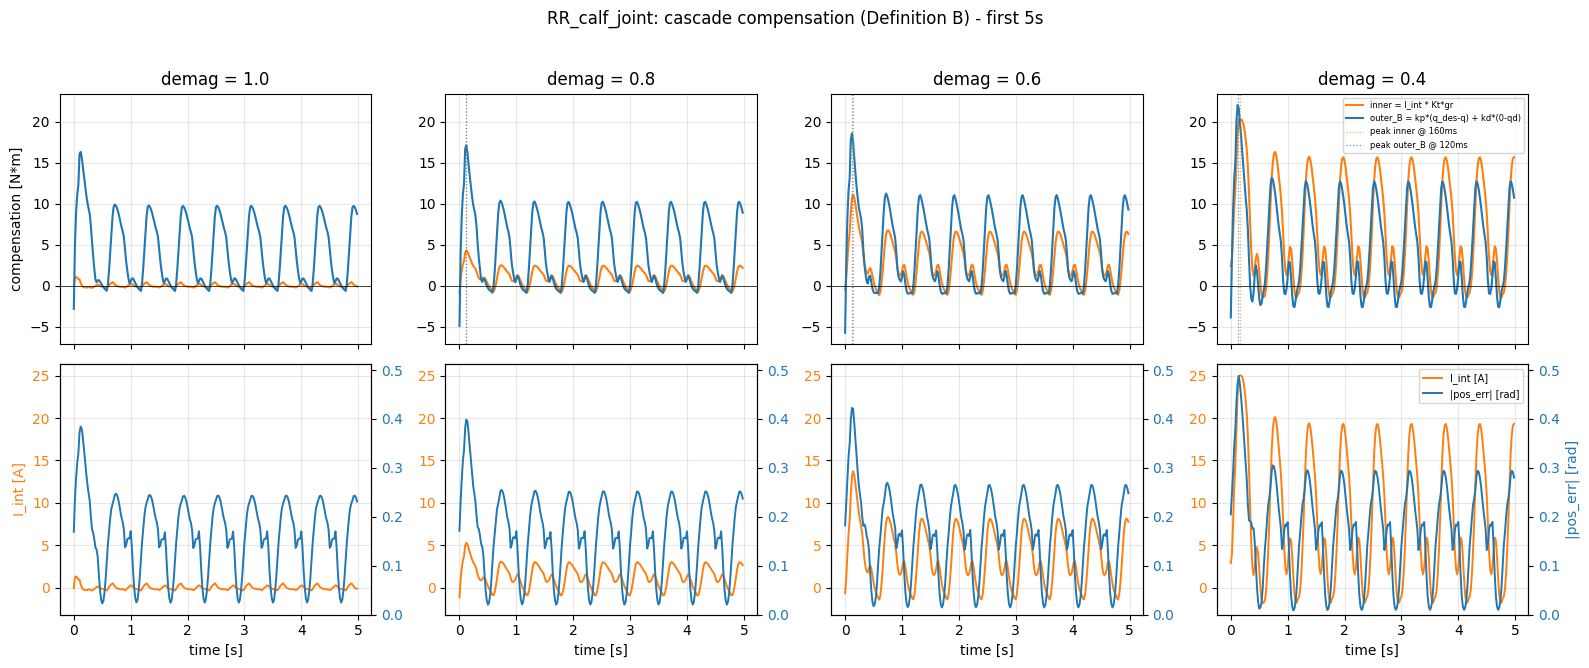

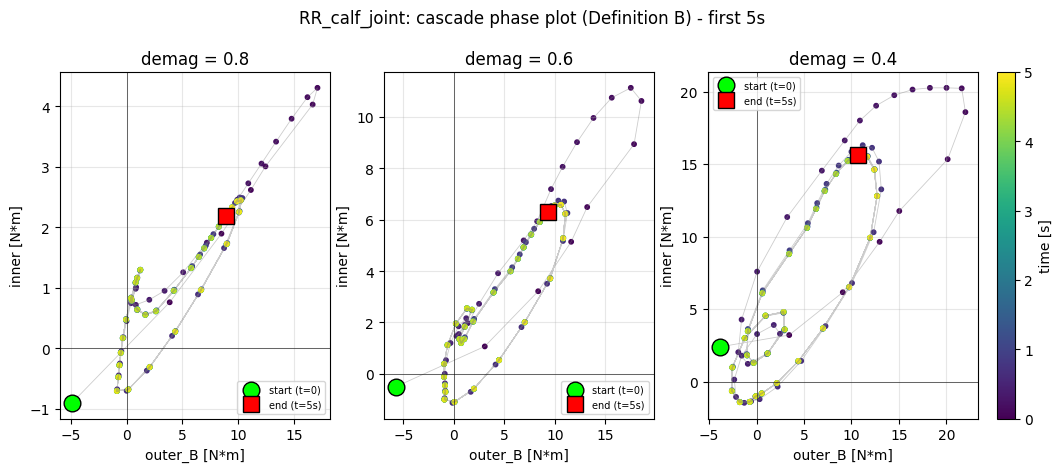

In [83]:
# ═══════════════════════════════════════════════════════════════════════
#  Definition B 분석 — outer = kp*(q_des-q) + kd*(0-qd)
#  cell-11 의 cases 딕트에 outer_response_B / pos_err_abs 필드 추가하고
#  정의 A 와 동일 구조의 그림·표를 만듦.
# ═══════════════════════════════════════════════════════════════════════

# ── cases dict 에 정의 B 필드 추가 (raw npz 는 _d 로 캐싱돼 있음) ─
for f in FACTORS:
    if f not in cases:
        continue
    c = cases[f]
    d, j, kp, kd = c['_d'], c['_j'], c['kp'], c['kd']
    pos_err = d['q_des'][:, j] - d['q_all'][:, j]
    qd      = d['qd_all'][:, j]
    outer_B = kp * pos_err + kd * (0.0 - qd)         # PD 출력 자체
    c['outer_response_B'] = rolling_mean(outer_B, smooth_n)
    c['pos_err_abs']      = rolling_mean(np.abs(pos_err), smooth_n)


# ════════════════════════════════════════════════════════════════════
#  그림 4 — Definition B zoom (4 panels x 2 rows)
# ════════════════════════════════════════════════════════════════════
# ── Compute global y-ranges for Definition B (uses |pos_err|) ──
COMP_YLIM_B, _, POSERR_ABS_YLIM = _comp_ranges(cases, 'outer_response_B', 'pos_err_abs')

fig4, axes4 = plt.subplots(2, len(FACTORS), figsize=(4*len(FACTORS), 6.5),
                            sharex=True)

for ci, f in enumerate(FACTORS):
    if f not in cases:
        for ax in axes4[:, ci]:
            ax.set_title(f'demag = {f} (missing)')
        continue
    c = cases[f]
    zn = int(round(CASCADE_ZOOM_S / c['dt']))
    t = c['t'][:zn]

    ax_top = axes4[0, ci]
    inner   = c['inner_torque'][:zn]
    outer_B = c['outer_response_B'][:zn]
    ax_top.plot(t, inner,   color='tab:orange', lw=1.5, label='inner = I_int * Kt*gr')
    ax_top.plot(t, outer_B, color='tab:blue',   lw=1.5,
                label='outer_B = kp*(q_des-q) + kd*(0-qd)')
    ax_top.axhline(0, color='k', lw=0.5)

    if f < 1.0:
        idx_in    = int(np.argmax(np.abs(inner)))
        idx_outB  = int(np.argmax(np.abs(outer_B)))
        ax_top.axvline(t[idx_in],   color='tab:orange', ls=':', lw=0.9, alpha=0.7,
                       label=f'peak inner @ {t[idx_in]*1000:.0f}ms')
        ax_top.axvline(t[idx_outB], color='tab:blue',   ls=':', lw=0.9, alpha=0.7,
                       label=f'peak outer_B @ {t[idx_outB]*1000:.0f}ms')

    ax_top.set_title(f'demag = {f}')
    ax_top.grid(alpha=0.3)
    if ci == 0:
        ax_top.set_ylabel('compensation [N*m]')

    ax_bot = axes4[1, ci]
    I_int   = c['I_int'][:zn]
    pos_abs = c['pos_err_abs'][:zn]
    l1 = ax_bot.plot(t, I_int, color='tab:orange', lw=1.4, label='I_int [A]')[0]
    ax_bot.tick_params(axis='y', labelcolor='tab:orange')

    ax_bot2 = ax_bot.twinx()
    l2 = ax_bot2.plot(t, pos_abs, color='tab:blue', lw=1.4, label='|pos_err| [rad]')[0]
    ax_bot2.tick_params(axis='y', labelcolor='tab:blue')

    ax_bot.grid(alpha=0.3)
    ax_bot.set_xlabel('time [s]')
    if ci == 0:
        ax_bot.set_ylabel('I_int [A]', color='tab:orange')
    if ci == len(FACTORS) - 1:
        ax_bot2.set_ylabel('|pos_err| [rad]', color='tab:blue')
        ax_bot.legend(handles=[l1, l2], fontsize=7, loc='upper right')

    # Unified y-limits (compute_ranges 결과 적용)
    ax_top.set_ylim(*COMP_YLIM_B)
    ax_bot.set_ylim(*IINT_YLIM)        # I_int 범위는 A/B 동일 (같은 cases 에서 계산)
    ax_bot2.set_ylim(0, POSERR_ABS_YLIM[1])   # |pos_err| 는 양수만

axes4[0, -1].legend(fontsize=6, loc='best')
fig4.suptitle(f'{JOINT}: cascade compensation (Definition B) - first {CASCADE_ZOOM_S:.0f}s',
              y=1.02)
fig4.tight_layout()


# ════════════════════════════════════════════════════════════════════
#  그림 5 — Phase plot (Definition B, color = time)
# ════════════════════════════════════════════════════════════════════
factors_demag = [f for f in FACTORS if f < 1.0 and f in cases]
if factors_demag:
    fig5, axes5 = plt.subplots(1, len(factors_demag),
                                figsize=(4.2*len(factors_demag), 4.5))
    if len(factors_demag) == 1:
        axes5 = [axes5]
    norm = mpl.colors.Normalize(vmin=0, vmax=CASCADE_ZOOM_S)
    for ax, f in zip(axes5, factors_demag):
        c = cases[f]
        zn = int(round(CASCADE_ZOOM_S / c['dt']))
        outer_B = c['outer_response_B'][:zn]
        inner   = c['inner_torque'][:zn]
        t = c['t'][:zn]
        ax.plot(outer_B, inner, color='gray', lw=0.6, alpha=0.4)
        sc = ax.scatter(outer_B, inner, c=t, cmap='viridis', s=10, norm=norm)
        ax.plot(outer_B[0],  inner[0],  'o', color='lime', ms=12, mec='k',
                label='start (t=0)')
        ax.plot(outer_B[-1], inner[-1], 's', color='red',  ms=12, mec='k',
                label=f'end (t={CASCADE_ZOOM_S:.0f}s)')
        ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
        ax.set_xlabel('outer_B [N*m]')
        ax.set_ylabel('inner [N*m]')
        ax.set_title(f'demag = {f}')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7, loc='best')
    fig5.colorbar(sc, ax=axes5, label='time [s]', fraction=0.04, pad=0.02)
    fig5.suptitle(f'{JOINT}: cascade phase plot (Definition B) - first {CASCADE_ZOOM_S:.0f}s',
                  y=1.02)


# ════════════════════════════════════════════════════════════════════
#  표 2 — Cascade timing & order (Definition B) + |pos_err| exp decay fit
# ════════════════════════════════════════════════════════════════════
def exp_decay(t, A, tau, offset):
    return A * np.exp(-t / tau) + offset


def fit_pos_err_decay(sig_smooth, dt_local, peak_search_s=1.0, fit_max_s=1.0):
    """Find peak of |pos_err| in [0, peak_search_s], fit exp decay from peak.

    Returns (A_fit, tau_outer, offset, t_peak) or None.
    """
    pn = int(round(peak_search_s / dt_local))
    pre = sig_smooth[:pn]
    pidx = int(np.argmax(np.abs(pre)))
    peak = float(pre[pidx])
    if abs(peak) < 1e-3:
        return None
    n_decay = int(round(fit_max_s / dt_local))
    n_decay = min(n_decay, len(sig_smooth) - pidx)
    if n_decay < 5:
        return None
    t_dec   = np.arange(n_decay) * dt_local
    sig_dec = sig_smooth[pidx:pidx + n_decay]
    try:
        popt, _ = curve_fit(
            exp_decay, t_dec, sig_dec,
            p0=[peak, 0.1, sig_dec[-1]],
            bounds=([-np.inf, 1e-3, -np.inf], [np.inf, 5.0, np.inf]),
            maxfev=5000,
        )
        return float(popt[0]), float(popt[1]), float(popt[2]), pidx * dt_local
    except Exception:
        return None


cascade_B_rows = []
for f in FACTORS:
    if f not in cases or f >= 1.0:
        continue
    c = cases[f]
    zn = int(round(CASCADE_ZOOM_S / c['dt']))
    inner_z   = c['inner_torque'][:zn]
    outer_B_z = c['outer_response_B'][:zn]
    t_z       = c['t'][:zn]

    tail_n      = int(round(TAIL_S / c['dt']))
    inner_ss    = float(np.mean(c['inner_torque'][-tail_n:]))
    outer_B_ss  = float(np.mean(c['outer_response_B'][-tail_n:]))

    idx_in_pk    = int(np.argmax(np.abs(inner_z)))
    idx_outB_pk  = int(np.argmax(np.abs(outer_B_z)))
    t_peak_in    = t_z[idx_in_pk]
    t_peak_outB  = t_z[idx_outB_pk]

    idx_in_50    = first_at_frac(inner_z,   inner_ss,   0.5)
    idx_outB_50  = first_at_frac(outer_B_z, outer_B_ss, 0.5)
    t50_in   = t_z[idx_in_50]   if idx_in_50   is not None else float('nan')
    t50_outB = t_z[idx_outB_50] if idx_outB_50 is not None else float('nan')

    # Order classification (10 ms 임계로 동시성 판정)
    if not np.isnan(t50_in) and not np.isnan(t50_outB):
        delta_ms = (t50_outB - t50_in) * 1000
        if abs(delta_ms) < 10:
            order = 'synchronous'
        elif delta_ms > 0:
            order = 'inner first'
        else:
            order = 'outer first'
    else:
        order = '-'

    # |pos_err| exp decay fit
    fit_res = fit_pos_err_decay(c['pos_err_abs'], c['dt'], peak_search_s=1.0, fit_max_s=1.0)
    if fit_res is not None:
        A_fit, tau_outer_fit, offset_fit, t_peak_pe = fit_res
    else:
        A_fit, tau_outer_fit, offset_fit, t_peak_pe = (
            float('nan'), float('nan'), float('nan'), float('nan'))

    cascade_B_rows.append({
        'factor':                  f,
        't_peak_inner [ms]':       t_peak_in   * 1000,
        't_peak_outer_B [ms]':     t_peak_outB * 1000,
        't_50_inner [ms]':         t50_in   * 1000 if not np.isnan(t50_in)   else float('nan'),
        't_50_outer_B [ms]':       t50_outB * 1000 if not np.isnan(t50_outB) else float('nan'),
        'order':                   order,
        'pos_err_peak [rad]':      A_fit + offset_fit if not np.isnan(A_fit) else float('nan'),
        'pos_err_offset [rad]':    offset_fit,
        'tau_outer_fit [ms]':      tau_outer_fit * 1000,
        't_peak_pe [ms]':          t_peak_pe * 1000,
    })

print(f'=== Cascade timing & order (Definition B, zoom = first {CASCADE_ZOOM_S:.0f}s) ===')
print(f'  outer_B = kp*(q_des-q) + kd*(0-qd)  (qd_des assumed 0; mjlab joint pos action)')
print(f'  order: |delta_t_50| < 10 ms -> synchronous; else inner/outer first')
print(f'  |pos_err| exp decay fit: A * exp(-t/tau_outer) + offset, peak in [0, 1s], fit window 1 s after peak')
cascade_B_df = pd.DataFrame(cascade_B_rows).set_index('factor')
display(cascade_B_df.style.format(
    {c: '{}' if c == 'order' else '{:.2f}' for c in cascade_B_df.columns},
    na_rep='-'))


# ════════════════════════════════════════════════════════════════════
#  표 3 — tau_inner_fit vs tau_outer_fit ratio
# ════════════════════════════════════════════════════════════════════
ratio_rows = []
for f in FACTORS:
    if f not in cases or f >= 1.0:
        continue
    c = cases[f]
    # Inner tau: 1차계 fit on I_int (cell-9 의 fit_first_order 재사용)
    tau_th = 1.0 / (f * KT_GR * KI)
    tail_n = int(round(TAIL_S / c['dt']))
    Iint_tail_mean = float(np.mean(c['I_int'][-tail_n:]))
    res = fit_first_order(c['t'], c['I_int'], tau_th, Iint_tail_mean)
    tau_inner_s = res[1] if res is not None else float('nan')

    # Outer tau (from above row)
    row = next(r for r in cascade_B_rows if r['factor'] == f)
    tau_outer_ms = row['tau_outer_fit [ms]']
    tau_outer_s  = tau_outer_ms / 1000.0 if not np.isnan(tau_outer_ms) else float('nan')

    ratio = (tau_outer_s / tau_inner_s
             if not np.isnan(tau_inner_s) and not np.isnan(tau_outer_s) and tau_inner_s > 0
             else float('nan'))

    ratio_rows.append({
        'factor':                f,
        'tau_inner_fit [ms]':    tau_inner_s * 1000 if not np.isnan(tau_inner_s) else float('nan'),
        'tau_outer_fit [ms]':    tau_outer_ms,
        'tau_inner_theory [ms]': tau_th * 1000,
        'ratio outer/inner':     ratio,
    })

print(f'\n=== tau_inner_fit vs tau_outer_fit ===')
print(f'  inner: 1st-order fit on I_int (cell-9 fit_first_order, identical params)')
print(f'  outer: 1st-order exp decay fit on |pos_err| transient')
print(f'  cascade hypothesis -> ratio outer/inner >> 1 (outer slower); ~1 -> synchronous')
ratio_df = pd.DataFrame(ratio_rows).set_index('factor')
display(ratio_df.style.format('{:.2f}', na_rep='-'))

## 3''''. 적분기 단독 시상수 측정 — q_freeze 격리 실험

이전 분석에서 `τ_inner_fit ≈ 10–17 ms` 가 이론값 `τ_inner_theory ≈ 31–62 ms` 의 **1/3 ~ 1/4** 로 나옴. 두 가설:
- **(A) outer forcing 압축**: 정책이 forcing 을 시간에 따라 키우면서 적분기가 본 effective error 가 더 빨리 줄어 τ 짧게 보임.
- **(B) 다른 artifact**: gait disturbance, V_bus 미세 효과, 5 ms ZOH, 2차 동역학 등.

**격리 방법**: 추론 시 **첫 step 의 q_des 를 freeze** 하고 모든 후속 step 에 동일 action 적용. 정책 GRU 는 계속 update 되지만 plant 입장에선 q_des = const → outer forcing 시간 변화 0 → 적분기 단독 응답.

**예측**:
- 가설 A: `τ_inner_qf / τ_inner_theory ≈ 1.0 ± 0.2`
- 가설 B: `τ_inner_qf / τ_inner_theory < 0.5` 여전히

### 실행

```
bash results/demag_rerun_aplus_ke_fixed/run_aplus_tloop_qfreeze_RR.sh
```

다리가 1–2 s 후 무너질 수 있어 5 s (250 step) 만 기록. 첫 transient 만 깨끗하면 충분. 데이터는 `data/aplus_tloop_qfreeze/{healthy,RR_0.8,RR_0.6,RR_0.4}.npz` 로 저장됨.

`run_demag_experiment.py` 에 `--qfreeze` flag 추가됨: 정책은 매 step 호출돼 GRU 가 update 되지만 출력은 t=0 값으로 고정. 출력 디렉터리에 `_qfreeze` 접미사 자동 추가.

[OK] aplus_tloop_qfreeze 가용 factor: [1.0, 0.8, 0.6, 0.4]

=== tau_inner: policy ON vs q_freeze vs theory ===
  hypothesis A (outer forcing compresses tau): qf/theory -> ~1.0 +/- 0.2
  hypothesis B (other artifact): qf/theory still < 0.5


,tau_on [ms],tau_qf [ms],tau_theory [ms],qf/theory ratio,qf/on ratio,I_ss_qf [A]
factor,,,,,,
0.800000,10.07,63.76,30.86,2.07,6.33,3.03
0.600000,15.93,98.46,41.14,2.39,6.18,8.73
0.400000,17.21,132.48,61.71,2.15,7.70,22.08


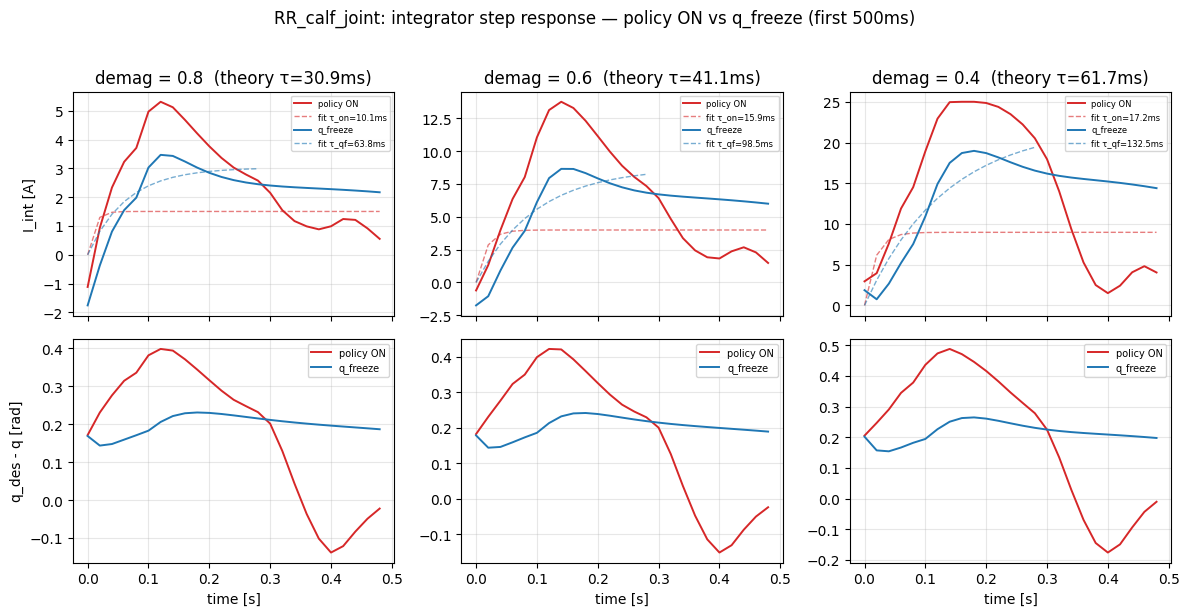

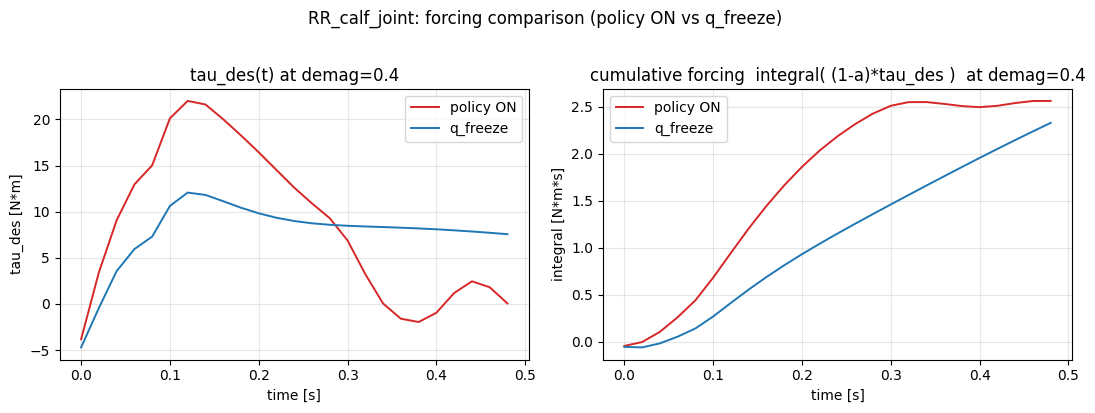

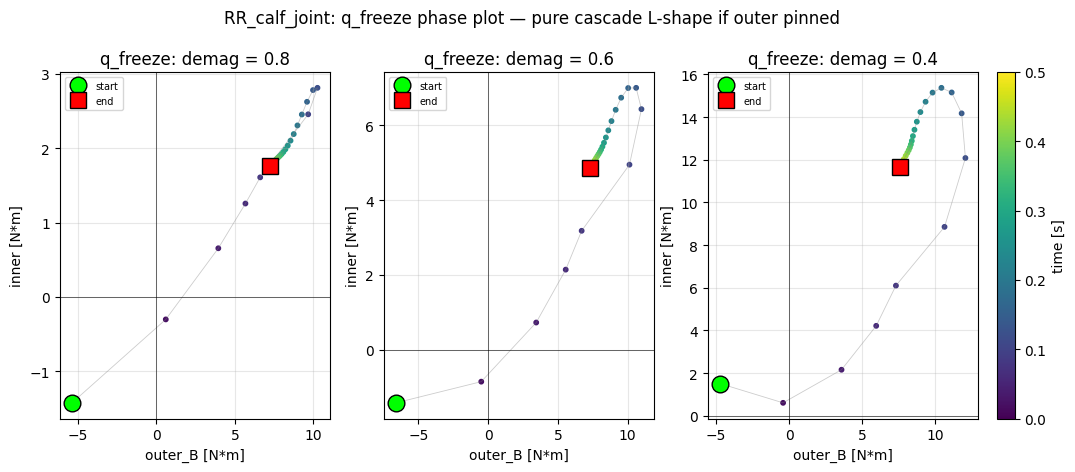

In [84]:
# ═══════════════════════════════════════════════════════════════════════
#  적분기 단독 시상수 측정 — q_freeze 격리 분석
#  데이터: data/aplus_tloop_qfreeze/{healthy,RR_0.8,RR_0.6,RR_0.4}.npz
#  생성: bash results/demag_rerun_aplus_ke_fixed/run_aplus_tloop_qfreeze_RR.sh
#  cell-9 의 KT_GR, KI, rolling_mean, fit_first_order, first_order_step,
#  cell-11 의 cases / get_pd_gains / first_at_frac / CASCADE_SMOOTH_S 재사용.
# ═══════════════════════════════════════════════════════════════════════

QFREEZE_POLICY = 'aplus_tloop_qfreeze'
QF_ZOOM_S      = 0.5    # 격리 transient zoom: 첫 500 ms 만 보면 inner τ 충분
QF_FIT_END_S   = 0.3    # fit window: τ_th ≤ 62 ms 이므로 0.3 s = ≥5τ


def try_load_qfreeze(f):
    try:
        return load_case(QFREEZE_POLICY, f)
    except FileNotFoundError:
        return None, None


# ── 데이터 가용성 확인 ─────────────────────────────────────────
qfreeze_available = []
for f in FACTORS:
    d, m = try_load_qfreeze(f)
    if d is not None:
        qfreeze_available.append(f)

if not qfreeze_available:
    print(f'[INFO] {QFREEZE_POLICY} 데이터 없음. 다음을 실행:')
    print(f'  bash results/demag_rerun_aplus_ke_fixed/run_aplus_tloop_qfreeze_RR.sh')
    print(f'그 후 본 셀 다시 실행.')
else:
    print(f'[OK] {QFREEZE_POLICY} 가용 factor: {qfreeze_available}')


# ── q_freeze cases 빌드 (cascade_analysis 와 같은 구조) ────────
def build_qfreeze_cases(joint=JOINT, factors=FACTORS):
    smooth_n = max(1, int(round(CASCADE_SMOOTH_S / 0.020)))
    cases_qf = {}
    for f in factors:
        d, m = try_load_qfreeze(f)
        if d is None:
            continue
        j = col_idx(m, joint)
        dt = float(m['dt'])
        kp, kd = get_pd_gains(joint)
        n = m['num_steps']
        t = np.arange(n) * dt
        I_int   = d['I_cmd'][:, j] - d['I_des'][:, j]
        inner_t = I_int * KT_GR
        pos_err = d['q_des'][:, j] - d['q_all'][:, j]
        qd      = d['qd_all'][:, j]
        outer_B = kp * pos_err + kd * (0.0 - qd)
        cases_qf[f] = {
            't': t, 'dt': dt, 'kp': kp, 'kd': kd,
            'I_int':            rolling_mean(I_int, smooth_n),
            'inner_torque':     rolling_mean(inner_t, smooth_n),
            'tau_des':          rolling_mean(d['tau_des'][:, j], smooth_n),
            'pos_err':          rolling_mean(pos_err, smooth_n),
            'pos_err_abs':      rolling_mean(np.abs(pos_err), smooth_n),
            'outer_response_B': rolling_mean(outer_B, smooth_n),
        }
    return cases_qf


cases_qf = build_qfreeze_cases(JOINT)


# ════════════════════════════════════════════════════════════════════
#  분석 1 — Step response zoom (정책 ON vs q_freeze)
# ════════════════════════════════════════════════════════════════════
if cases_qf:
    factors_demag = [f for f in FACTORS if f < 1.0 and f in cases]

    fig_qf1, axes_qf = plt.subplots(2, len(factors_demag),
                                      figsize=(4*len(factors_demag), 6.0),
                                      sharex=True)
    if len(factors_demag) == 1:
        axes_qf = axes_qf.reshape(2, 1)

    for ci, f in enumerate(factors_demag):
        ax_top = axes_qf[0, ci]
        ax_bot = axes_qf[1, ci]
        c_on = cases[f]
        zn_on = int(round(QF_ZOOM_S / c_on['dt']))
        ax_top.plot(c_on['t'][:zn_on], c_on['I_int'][:zn_on],
                    color='tab:red', lw=1.4, label='policy ON')
        ax_bot.plot(c_on['t'][:zn_on], c_on['pos_err'][:zn_on],
                    color='tab:red', lw=1.4, label='policy ON')

        # 1차계 fit on policy ON
        tau_th = 1.0 / (f * KT_GR * KI)
        tail_n_on = int(round(TAIL_S / c_on['dt']))
        Iss_on_guess = float(np.mean(c_on['I_int'][-tail_n_on:]))
        res_on = fit_first_order(c_on['t'], c_on['I_int'], tau_th, Iss_on_guess)
        if res_on is not None:
            Iss_on, tau_on, win_on = res_on
            n_show = int(round(min(win_on, QF_ZOOM_S) / c_on['dt']))
            ax_top.plot(c_on['t'][:n_show],
                         first_order_step(c_on['t'][:n_show], Iss_on, tau_on),
                         color='tab:red', ls='--', lw=1.0, alpha=0.6,
                         label=f'fit τ_on={tau_on*1000:.1f}ms')
        else:
            tau_on = float('nan')

        if f in cases_qf:
            c_qf = cases_qf[f]
            zn_qf = int(round(QF_ZOOM_S / c_qf['dt']))
            ax_top.plot(c_qf['t'][:zn_qf], c_qf['I_int'][:zn_qf],
                         color='tab:blue', lw=1.4, label='q_freeze')
            ax_bot.plot(c_qf['t'][:zn_qf], c_qf['pos_err'][:zn_qf],
                         color='tab:blue', lw=1.4, label='q_freeze')

            # 1차계 fit on q_freeze (short window, no tail)
            n_fit = min(int(round(QF_FIT_END_S / c_qf['dt'])), len(c_qf['t']))
            Iss_qf_guess = float(np.mean(c_qf['I_int'][n_fit-min(5,n_fit):n_fit]))
            try:
                from scipy.optimize import curve_fit as _cf
                popt_qf, _ = _cf(
                    first_order_step,
                    c_qf['t'][:n_fit], c_qf['I_int'][:n_fit],
                    p0=[Iss_qf_guess, max(tau_th, 1e-3)],
                    bounds=([-np.inf, 1e-4], [np.inf, 5.0]),
                    maxfev=5000,
                )
                Iss_qf, tau_qf = float(popt_qf[0]), float(popt_qf[1])
                ax_top.plot(c_qf['t'][:n_fit],
                             first_order_step(c_qf['t'][:n_fit], Iss_qf, tau_qf),
                             color='tab:blue', ls='--', lw=1.0, alpha=0.6,
                             label=f'fit τ_qf={tau_qf*1000:.1f}ms')
            except Exception:
                tau_qf = float('nan')

        ax_top.set_title(f'demag = {f}  (theory τ={tau_th*1000:.1f}ms)')
        ax_top.grid(alpha=0.3); ax_bot.grid(alpha=0.3)
        if ci == 0:
            ax_top.set_ylabel('I_int [A]')
            ax_bot.set_ylabel('q_des - q [rad]')
        ax_bot.set_xlabel('time [s]')
        ax_top.legend(fontsize=6, loc='best')
        ax_bot.legend(fontsize=7, loc='best')

    fig_qf1.suptitle(
        f'{JOINT}: integrator step response — policy ON vs q_freeze '
        f'(first {QF_ZOOM_S*1000:.0f}ms)', y=1.02)
    fig_qf1.tight_layout()


# ════════════════════════════════════════════════════════════════════
#  분석 2 — τ_inner 비교 표 (격리 vs 정책 ON vs 이론)
# ════════════════════════════════════════════════════════════════════
if cases_qf:
    from scipy.optimize import curve_fit as _cf

    qf_rows = []
    for f in FACTORS:
        if f >= 1.0 or f not in cases:
            continue
        c_on = cases[f]
        tau_th = 1.0 / (f * KT_GR * KI)

        # Inner τ in policy ON
        tail_n = int(round(TAIL_S / c_on['dt']))
        Iss_on_guess = float(np.mean(c_on['I_int'][-tail_n:]))
        res_on = fit_first_order(c_on['t'], c_on['I_int'], tau_th, Iss_on_guess)
        tau_on = res_on[1] if res_on else float('nan')

        # Inner τ in q_freeze (short window)
        if f in cases_qf:
            c_qf = cases_qf[f]
            n_fit = min(int(round(QF_FIT_END_S / c_qf['dt'])), len(c_qf['t']))
            Iss_qf_guess = float(np.mean(c_qf['I_int'][n_fit-min(5,n_fit):n_fit]))
            try:
                popt, _ = _cf(
                    first_order_step,
                    c_qf['t'][:n_fit], c_qf['I_int'][:n_fit],
                    p0=[Iss_qf_guess, max(tau_th, 1e-3)],
                    bounds=([-np.inf, 1e-4], [np.inf, 5.0]),
                    maxfev=5000,
                )
                tau_qf, Iss_qf = float(popt[1]), float(popt[0])
            except Exception:
                tau_qf, Iss_qf = float('nan'), float('nan')
        else:
            tau_qf, Iss_qf = float('nan'), float('nan')

        qf_rows.append({
            'factor':            f,
            'tau_on [ms]':       tau_on * 1000,
            'tau_qf [ms]':       tau_qf * 1000,
            'tau_theory [ms]':   tau_th * 1000,
            'qf/theory ratio':   tau_qf / tau_th if not np.isnan(tau_qf) and tau_th > 0 else float('nan'),
            'qf/on ratio':       tau_qf / tau_on if not np.isnan(tau_qf) and not np.isnan(tau_on) and tau_on > 0 else float('nan'),
            'I_ss_qf [A]':       Iss_qf,
        })

    print(f'\n=== tau_inner: policy ON vs q_freeze vs theory ===')
    print(f'  hypothesis A (outer forcing compresses tau): qf/theory -> ~1.0 +/- 0.2')
    print(f'  hypothesis B (other artifact): qf/theory still < 0.5')
    qf_df = pd.DataFrame(qf_rows).set_index('factor')
    display(qf_df.style.format('{:.2f}', na_rep='-'))


# ════════════════════════════════════════════════════════════════════
#  분석 3 — Forcing 변화 검증 (τ_des(t), α=0.4 focus)
# ════════════════════════════════════════════════════════════════════
if cases_qf and 0.4 in cases_qf:
    f_focus = 0.4
    c_on  = cases[f_focus]
    c_qf  = cases_qf[f_focus]
    zn_on = int(round(QF_ZOOM_S / c_on['dt']))
    zn_qf = int(round(QF_ZOOM_S / c_qf['dt']))

    fig_qf3, axes_qf3 = plt.subplots(1, 2, figsize=(11, 4))

    ax = axes_qf3[0]
    ax.plot(c_on['t'][:zn_on], c_on['tau_des'][:zn_on],
            color='tab:red', lw=1.4, label='policy ON')
    ax.plot(c_qf['t'][:zn_qf], c_qf['tau_des'][:zn_qf],
            color='tab:blue', lw=1.4, label='q_freeze')
    ax.set_title(f'tau_des(t) at demag={f_focus}')
    ax.set_xlabel('time [s]'); ax.set_ylabel('tau_des [N*m]')
    ax.grid(alpha=0.3); ax.legend()

    ax = axes_qf3[1]
    forcing_on = (1 - f_focus) * c_on['tau_des'][:zn_on]
    forcing_qf = (1 - f_focus) * c_qf['tau_des'][:zn_qf]
    cum_on = np.cumsum(forcing_on) * c_on['dt']
    cum_qf = np.cumsum(forcing_qf) * c_qf['dt']
    ax.plot(c_on['t'][:zn_on], cum_on, color='tab:red', lw=1.4, label='policy ON')
    ax.plot(c_qf['t'][:zn_qf], cum_qf, color='tab:blue', lw=1.4, label='q_freeze')
    ax.set_title(f'cumulative forcing  integral( (1-a)*tau_des )  at demag={f_focus}')
    ax.set_xlabel('time [s]'); ax.set_ylabel('integral [N*m*s]')
    ax.grid(alpha=0.3); ax.legend()

    fig_qf3.suptitle(f'{JOINT}: forcing comparison (policy ON vs q_freeze)', y=1.02)
    fig_qf3.tight_layout()


# ════════════════════════════════════════════════════════════════════
#  분석 4 — Phase plot (q_freeze: 순수 cascade L 자 검증)
# ════════════════════════════════════════════════════════════════════
if cases_qf:
    factors_demag_qf = [f for f in FACTORS if f < 1.0 and f in cases_qf]
    if factors_demag_qf:
        fig_qf4, axes_qf4 = plt.subplots(1, len(factors_demag_qf),
                                           figsize=(4.2*len(factors_demag_qf), 4.5))
        if len(factors_demag_qf) == 1:
            axes_qf4 = [axes_qf4]
        norm = mpl.colors.Normalize(vmin=0, vmax=QF_ZOOM_S)
        for ax, f in zip(axes_qf4, factors_demag_qf):
            c = cases_qf[f]
            zn = int(round(QF_ZOOM_S / c['dt']))
            outer_B = c['outer_response_B'][:zn]
            inner   = c['inner_torque'][:zn]
            t = c['t'][:zn]
            ax.plot(outer_B, inner, color='gray', lw=0.6, alpha=0.4)
            sc = ax.scatter(outer_B, inner, c=t, cmap='viridis', s=10, norm=norm)
            ax.plot(outer_B[0],  inner[0],  'o', color='lime', ms=12, mec='k', label='start')
            ax.plot(outer_B[-1], inner[-1], 's', color='red',  ms=12, mec='k', label='end')
            ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
            ax.set_xlabel('outer_B [N*m]'); ax.set_ylabel('inner [N*m]')
            ax.set_title(f'q_freeze: demag = {f}')
            ax.grid(alpha=0.3); ax.legend(fontsize=7)
        fig_qf4.colorbar(sc, ax=axes_qf4, label='time [s]', fraction=0.04, pad=0.02)
        fig_qf4.suptitle(
            f'{JOINT}: q_freeze phase plot — pure cascade L-shape if outer pinned',
            y=1.02)


## 3'''''. Ki sweep — 적분기 게인 최적화

이전까지 모든 분석은 `Ki = 50` (cfg 기본값) 으로 했는데, 50 이 진짜 튜닝된 최적인지 검증.

**측정 항목** (Ki ∈ {25, 50, 100, 200} × α ∈ {1.0, 0.4, 0.2}):
- **settling time**: 1차계 fit τ_inner_fit. Ki 가 클수록 빨라야 함 (`τ_loop = 1/(α·K_t·g_r·K_i)`, 이론).
- **overshoot**: peak |I_int| / tail. Ki 가 너무 크면 overshoot 폭증, 진동.
- **cap usage**: peak |I_int| / (Ki · integral_max) × 100 %. anti-windup 천장 사용률. 100 % 도달 시 windup 위험.
- **posture tracking**: tail 5 s 윈도우의 `(q_des - q)` RMS [rad]. Ki 효과의 최종 지표.

**예상**:
- Ki ↑ → τ ↓, posture RMS ↓, cap usage ↑ (단조).
- 어느 Ki 에서 overshoot 가 임계 (~1.5×) 넘으면 stability margin 의 시작.
- α 깊을수록 (0.2) 같은 Ki 에서 cap usage 가 더 높음. 어느 α 에서 cap 100 % 닿는지가 cfg 한계.

**실행**: `bash results/demag_rerun_aplus_ke_fixed/run_ki_sweep_RR.sh`. 약 10 분 (12 runs, 3 병렬, 10 s/run, no-video).

데이터 → `data/aplus_tloop_ki025/`, `_ki050/`, `_ki100/`, `_ki200/`.

후속 (필요시): Ki=400 stability boundary 단일 점, 센서 노이즈 + Ki 토크 ripple, α<0.2 더 깊은 demag.

[Ki sweep data availability]
  Ki=25: alpha = [1.0, 0.4, 0.2]
  Ki=50: alpha = [1.0, 0.4]
  Ki=100: alpha = [1.0, 0.4, 0.2]
  Ki=200: alpha = [1.0, 0.4, 0.2]
=== Ki sweep summary table (RR_calf, NUM_STEPS=500, tail=5s) ===
  cap = Ki * integral_max = Ki * 0.5


,,tau_fit [ms],tau_theory [ms],fit/theory,I_int_tail [A],peak |I_int| [A],t_peak [ms],overshoot,cap usage [%],posture RMS [rad],tau_act/tau_des
alpha,Ki,,,,,,,,,,
1.000000,25,-,49.368,-,-0.003,0.924,100.000,-,7.392,0.175,1.006
0.400000,25,24.333,123.420,0.197,6.191,12.500,240.000,2.019,100.000,0.245,0.609
0.200000,25,0.194,246.840,0.001,3.686,11.253,1700.000,3.053,90.023,1.182,0.184
1.000000,50,-,24.684,-,0.014,1.356,40.000,-,5.423,0.178,1.013
0.400000,50,17.217,61.710,0.279,7.523,25.000,160.000,3.323,100.000,0.199,0.846
1.000000,100,-,12.342,-,0.020,1.811,20.000,-,3.622,0.176,1.018
0.400000,100,17.155,30.855,0.556,7.342,32.327,160.000,4.403,64.654,0.184,0.919
0.200000,100,0.226,61.710,0.004,18.129,36.639,1500.000,2.021,73.278,0.259,0.583
1.000000,200,-,6.171,-,0.048,1.560,20.000,-,1.560,0.176,1.008


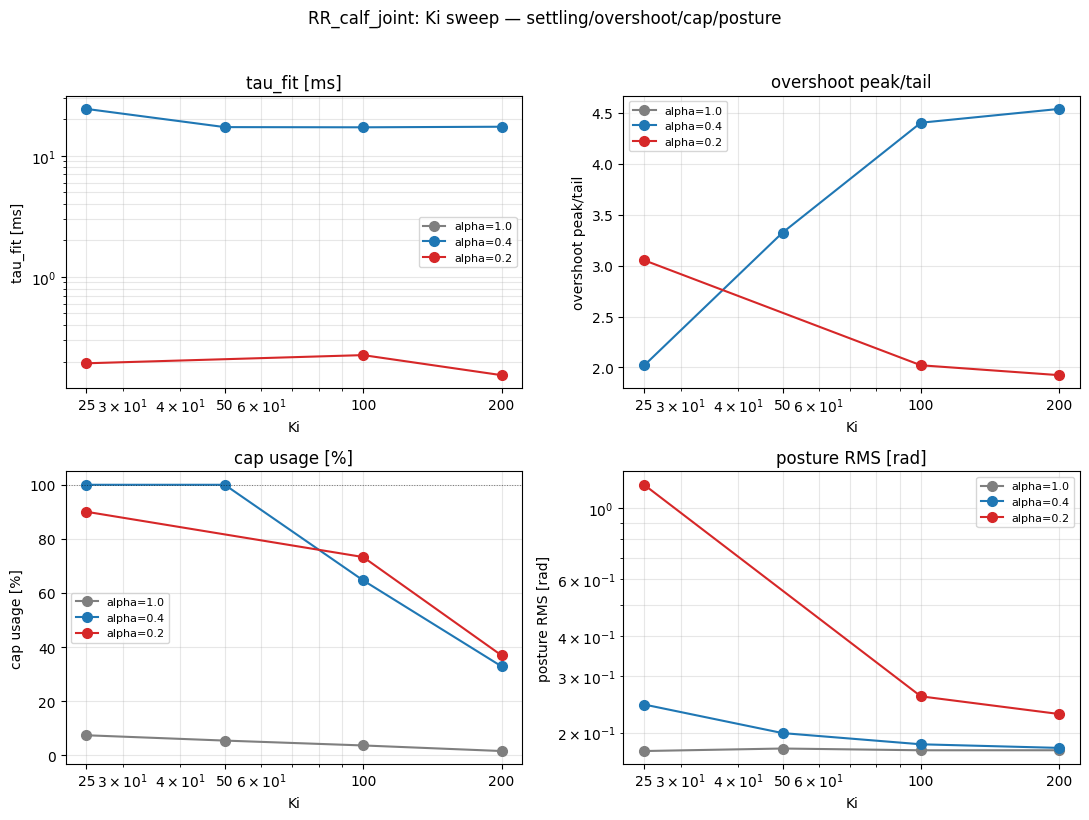

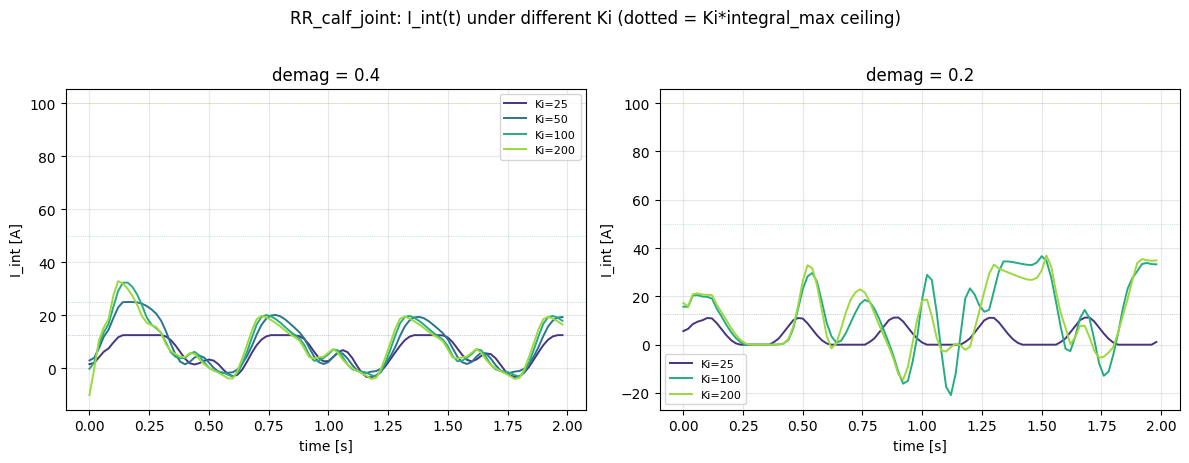

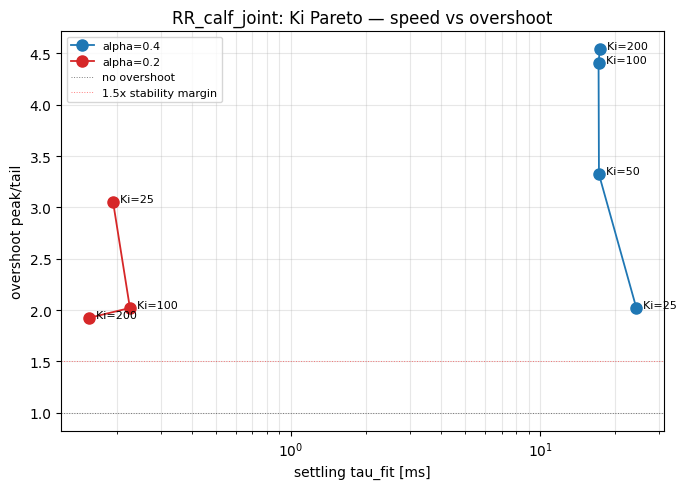

In [85]:
# ═══════════════════════════════════════════════════════════════════════
#  Ki sweep 분석 — 4 Ki x 3 alpha = 12 cases
#  데이터: data/aplus_tloop_ki{025,050,100,200}/{healthy,RR_0.4,RR_0.2}.npz
#  생성: bash results/demag_rerun_aplus_ke_fixed/run_ki_sweep_RR.sh
#  cell-9 의 KT_GR, KI(50, 기본값), rolling_mean, fit_first_order, first_order_step,
#  cell-11 의 get_pd_gains 그대로 재사용. cell 자체에서 Ki 는 자유 변수.
# ═══════════════════════════════════════════════════════════════════════

KI_SWEEP_VALUES = [25, 50, 100, 200]
ALPHA_SWEEP     = [1.0, 0.4, 0.2]
KI_SMOOTH_S     = 0.1
KI_TAIL_S       = 5.0
KI_FIT_END_S    = 2.0
KI_INTEGRAL_MAX = 0.5     # cfg default — 추후 sweep 도입 시 per-run meta 에서 읽기


def ki_dir(ki_int):
    return f'aplus_tloop_ki{ki_int:03d}'


def try_load_ki(ki_int, factor):
    try:
        return load_case(ki_dir(ki_int), factor)
    except FileNotFoundError:
        return None, None


# ── 데이터 가용성 확인 ───────────────────────────────────────────
ki_avail = {}
for ki in KI_SWEEP_VALUES:
    ki_avail[ki] = []
    for f in ALPHA_SWEEP:
        d, m = try_load_ki(ki, f)
        if d is not None:
            ki_avail[ki].append(f)
print('[Ki sweep data availability]')
for ki, fs in ki_avail.items():
    print(f'  Ki={ki}: alpha = {fs}')
if not any(ki_avail.values()):
    print('\n[INFO] 데이터 없음. 먼저 실행:')
    print('  bash results/demag_rerun_aplus_ke_fixed/run_ki_sweep_RR.sh')


# ── 메트릭 계산 ─────────────────────────────────────────────────
def ki_metrics(ki, f, joint=JOINT):
    d, m = try_load_ki(ki, f)
    if d is None:
        return None
    j = col_idx(m, joint)
    dt = float(m['dt'])
    smooth_n = max(1, int(round(KI_SMOOTH_S / dt)))
    tail_n   = int(round(KI_TAIL_S / dt))
    n_fit    = int(round(KI_FIT_END_S / dt))
    n_fit    = min(n_fit, m['num_steps'])

    I_cmd  = d['I_cmd'][:, j]
    I_des  = d['I_des'][:, j]
    I_int  = I_cmd - I_des
    Iint_s = rolling_mean(I_int, smooth_n)

    pos_err = d['q_des'][:, j] - d['q_all'][:, j]
    posture_rms = float(np.sqrt(np.mean(pos_err[-tail_n:] ** 2)))

    tau_des    = d['tau_des'][:, j]
    tau_actual = d['tau_actual'][:, j]
    tau_des_tail = float(np.mean(np.abs(tau_des[-tail_n:])))
    tau_act_tail = float(np.mean(np.abs(tau_actual[-tail_n:])))
    tau_track    = tau_act_tail / max(tau_des_tail, 1e-6)

    Iint_tail = float(np.mean(Iint_s[-tail_n:]))
    pidx      = int(np.argmax(np.abs(Iint_s[:n_fit])))
    peak_signed = float(Iint_s[pidx])
    peak_abs    = abs(peak_signed)
    t_peak      = pidx * dt
    overshoot   = (peak_signed / Iint_tail) if abs(Iint_tail) > 0.05 else float('nan')

    # cap usage % vs Ki·integral_max
    int_max = m.get('integral_max_override') if isinstance(m, dict) else None
    if int_max is None:
        int_max = KI_INTEGRAL_MAX
    cap_amp     = ki * int_max
    cap_usage   = peak_abs / cap_amp * 100.0 if cap_amp > 0 else float('nan')

    # 1차계 fit τ_inner
    tau_th = 1.0 / (f * KT_GR * ki) if f > 0 else float('nan')
    if abs(Iint_tail) >= 0.05:
        try:
            popt, _ = curve_fit(
                first_order_step,
                np.arange(n_fit) * dt, Iint_s[:n_fit],
                p0=[Iint_tail, max(tau_th, 1e-3)],
                bounds=([-np.inf, 1e-4], [np.inf, 5.0]),
                maxfev=5000,
            )
            Iss_fit, tau_fit = float(popt[0]), float(popt[1])
        except Exception:
            Iss_fit, tau_fit = float('nan'), float('nan')
    else:
        Iss_fit, tau_fit = float('nan'), float('nan')

    return {
        'ki':              ki,
        'alpha':           f,
        'tau_fit_ms':      tau_fit * 1000,
        'tau_theory_ms':   tau_th * 1000,
        'I_int_tail':      Iint_tail,
        'peak_I_int':      peak_signed,
        't_peak_ms':       t_peak * 1000,
        'overshoot':       overshoot,
        'cap_usage_pct':   cap_usage,
        'posture_rms_rad': posture_rms,
        'tau_track':       tau_track,
        'tau_des_tail':    tau_des_tail,
        '_t':  np.arange(m['num_steps']) * dt,
        '_dt': dt,
        '_Iint_s':  Iint_s,
        '_pos_err': pos_err,
    }


metrics = {}
for ki in KI_SWEEP_VALUES:
    for f in ALPHA_SWEEP:
        rec = ki_metrics(ki, f)
        if rec is not None:
            metrics[(ki, f)] = rec


# ════════════════════════════════════════════════════════════════════
#  표 — Ki sweep 정량 비교 (alpha 별)
# ════════════════════════════════════════════════════════════════════
if metrics:
    summary_rows = []
    for ki in KI_SWEEP_VALUES:
        for f in ALPHA_SWEEP:
            if (ki, f) not in metrics:
                continue
            m = metrics[(ki, f)]
            summary_rows.append({
                'Ki':                      ki,
                'alpha':                   f,
                'tau_fit [ms]':            m['tau_fit_ms'],
                'tau_theory [ms]':         m['tau_theory_ms'],
                'fit/theory':              m['tau_fit_ms'] / m['tau_theory_ms'] if m['tau_theory_ms'] > 0 else float('nan'),
                'I_int_tail [A]':          m['I_int_tail'],
                'peak |I_int| [A]':        abs(m['peak_I_int']),
                't_peak [ms]':             m['t_peak_ms'],
                'overshoot':               m['overshoot'],
                'cap usage [%]':           m['cap_usage_pct'],
                'posture RMS [rad]':       m['posture_rms_rad'],
                'tau_act/tau_des':         m['tau_track'],
            })
    print(f'=== Ki sweep summary table (RR_calf, NUM_STEPS=500, tail={KI_TAIL_S:.0f}s) ===')
    print(f'  cap = Ki * integral_max = Ki * {KI_INTEGRAL_MAX}')
    summary_df = pd.DataFrame(summary_rows).set_index(['alpha', 'Ki'])
    display(summary_df.style.format('{:.3f}', na_rep='-'))


# ════════════════════════════════════════════════════════════════════
#  그림 1 — Ki vs 4 메트릭 trend (alpha 별 line)
# ════════════════════════════════════════════════════════════════════
if metrics:
    fig_ki, axes_ki = plt.subplots(2, 2, figsize=(11, 8))
    panel_specs = [
        ('tau_fit_ms',      'tau_fit [ms]',         True,  axes_ki[0, 0]),
        ('overshoot',       'overshoot peak/tail',  False, axes_ki[0, 1]),
        ('cap_usage_pct',   'cap usage [%]',        False, axes_ki[1, 0]),
        ('posture_rms_rad', 'posture RMS [rad]',    True,  axes_ki[1, 1]),
    ]
    alpha_colors = {1.0: 'tab:gray', 0.4: 'tab:blue', 0.2: 'tab:red'}
    for key, label, log_y, ax in panel_specs:
        for f in ALPHA_SWEEP:
            xs, ys = [], []
            for ki in KI_SWEEP_VALUES:
                if (ki, f) in metrics:
                    xs.append(ki)
                    ys.append(metrics[(ki, f)][key])
            if xs:
                ax.plot(xs, ys, 'o-', color=alpha_colors.get(f, 'k'),
                        label=f'alpha={f}', lw=1.5, ms=7)
        ax.set_xlabel('Ki')
        ax.set_ylabel(label)
        ax.set_xscale('log')
        if log_y:
            ax.set_yscale('log')
        ax.set_xticks(KI_SWEEP_VALUES)
        ax.set_xticklabels([str(k) for k in KI_SWEEP_VALUES])
        ax.grid(alpha=0.3, which='both')
        ax.legend(fontsize=8)
        ax.set_title(label)
    # cap usage 100 % reference line
    axes_ki[1, 0].axhline(100, color='k', ls=':', lw=0.7, alpha=0.5)
    fig_ki.suptitle(f'{JOINT}: Ki sweep — settling/overshoot/cap/posture', y=1.02)
    fig_ki.tight_layout()


# ════════════════════════════════════════════════════════════════════
#  그림 2 — Ki 별 I_int(t) overlay (alpha=0.4 focus)
# ════════════════════════════════════════════════════════════════════
if metrics:
    fig_iov, axes_iov = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
    ki_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(KI_SWEEP_VALUES)))
    for f, ax in zip([0.4, 0.2], axes_iov):
        for ki, color in zip(KI_SWEEP_VALUES, ki_colors):
            if (ki, f) not in metrics:
                continue
            m = metrics[(ki, f)]
            zn = int(round(KI_FIT_END_S / m['_dt']))
            ax.plot(m['_t'][:zn], m['_Iint_s'][:zn], color=color, lw=1.4,
                    label=f'Ki={ki}')
            cap_amp = ki * KI_INTEGRAL_MAX
            ax.axhline(cap_amp, color=color, ls=':', lw=0.5, alpha=0.5)
        ax.set_xlabel('time [s]')
        ax.set_ylabel('I_int [A]')
        ax.set_title(f'demag = {f}')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    fig_iov.suptitle(f'{JOINT}: I_int(t) under different Ki '
                     f'(dotted = Ki*integral_max ceiling)', y=1.02)
    fig_iov.tight_layout()


# ════════════════════════════════════════════════════════════════════
#  Pareto — settling vs overshoot (alpha 별)
# ════════════════════════════════════════════════════════════════════
if metrics:
    fig_par, ax_par = plt.subplots(1, 1, figsize=(7, 5))
    for f in [0.4, 0.2]:
        xs = [metrics[(ki, f)]['tau_fit_ms']
              for ki in KI_SWEEP_VALUES if (ki, f) in metrics
              and not np.isnan(metrics[(ki, f)]['tau_fit_ms'])]
        ys = [metrics[(ki, f)]['overshoot']
              for ki in KI_SWEEP_VALUES if (ki, f) in metrics
              and not np.isnan(metrics[(ki, f)]['overshoot'])]
        kis = [ki for ki in KI_SWEEP_VALUES if (ki, f) in metrics
               and not np.isnan(metrics[(ki, f)]['tau_fit_ms'])]
        if not xs:
            continue
        ax_par.plot(xs, ys, 'o-', color=alpha_colors.get(f, 'k'),
                    label=f'alpha={f}', lw=1.3, ms=8)
        for x, y, ki in zip(xs, ys, kis):
            ax_par.annotate(f'  Ki={ki}', (x, y), fontsize=8)
    ax_par.set_xlabel('settling tau_fit [ms]')
    ax_par.set_ylabel('overshoot peak/tail')
    ax_par.set_xscale('log')
    ax_par.axhline(1.0, color='k', ls=':', lw=0.7, alpha=0.5,
                   label='no overshoot')
    ax_par.axhline(1.5, color='r', ls=':', lw=0.7, alpha=0.5,
                   label='1.5x stability margin')
    ax_par.grid(alpha=0.3, which='both')
    ax_par.legend(fontsize=8)
    ax_par.set_title(f'{JOINT}: Ki Pareto — speed vs overshoot')
    fig_par.tight_layout()


## 3''''''. K_i 시간 영역 육안 분석 — 적분기 ringing 검증

**가설**: K_i=50 + α=0.4 에서 적분기 시상수 (~62 ms) 와 다리 mechanical 시상수 (~65 ms) 가 비슷해서 3 차 시스템 공명 발생. cell-9 fit 가 17 ms 로 이론 1/4 이 나온 것이 그 증거.

**확인 3 가지**:
1. 현재 K_i=50 에서 τ_actual 가 τ_des 추종 시 출렁이는가?
2. K_i 키우면 (100, 200) 출렁임 사라지는가?
3. K_i 너무 키웠을 때 overshoot/undershoot 새로 나타나는가?

**방법**: 보행 중 τ_des 가 급변하는 시점을 자동 추출해 K_i 별 step response 평균 + ±1σ band. 잔차 (`τ_actual − τ_des`) 의 진동을 시간 영역과 주파수 영역에서 동시 검증.

**데이터 가용**: K_i ∈ {25, 50, 100, 200} × α=0.4 (worst case 공통). K_i=400 은 데이터 없음 (필요 시 후속 sweep).

In [86]:
# ═══════════════════════════════════════════════════════════════════════
#  [Cell 1+2] Multi-K_i 데이터 로드 + transient (step event) 윈도우 자동 추출
# ═══════════════════════════════════════════════════════════════════════
from pathlib import Path

# ── 사용자 조절 변수 ────────────────────────────────────────────
KI_VALUES         = [25, 50, 100, 200, 400]   # 데이터 있는 것만 자동 필터
DEMAG_FACTOR      = 0.4                       # 동일 조건 (worst case)
MAX_DATA_S        = 10.0                      # 모든 K_i 동일 길이 (긴 데이터 자동 truncate)

# Step event 탐지: |dτ_des/dt| > N·σ where σ = std(dτ/dt) post-skip.
# σ 의 의미:
#   - dτ/dt 는 τ_des 의 1차 차분 / dt — 단위 [N·m/s]
#   - σ = standard deviation 은 모든 sample 의 |변화율| 의 "전형적 크기"
#   - 보행 중 τ_des 는 사인파 비슷 → σ 는 약 (peak amplitude) / √2 / period
#   - 2σ 는 분포 상위 ~5 % 의 큰 변화율을 잡음 (Gaussian 가정 시; τ_des 는 실제로
#     비-Gaussian 이라 더 많이 잡힐 수 있음)
#   - σ 자체는 데이터 의존 → K_i 마다 다른 값. 작은 K_i 일수록 보행 진폭 ↑ → σ ↑
#   - SKIP_EARLY_S 이전은 시뮬 startup transient 라 σ 계산에서 제외
STEP_THR_NSIGMA   = 2.0

# Event 정의 — 두 가지 방식 중 선택:
#   'foot_contact' : RR_foot rising edge (heel strike). 물리적, K_i 무관 임계.
#   'tau_step'     : |dτ_des/dt| > N·σ. 일반화된 변화율 탐지.
EVENT_SOURCE      = 'foot_contact'            # 기본: 발 접촉 (권장)
EVENT_FOOT        = 'RR'                      # foot_contact 사용 시 어느 발

# Window: 발 디딤(touchdown) 시점 기준. 보행 주기 ~600 ms (1.67 Hz, trotting).
# 3 사이클 = 1.8 s. transient 응답 + 정상상태 oscillation 둘 다 보기 위함.
GAIT_PERIOD_S     = 0.60                      # 측정값 — `foot_contact` 분석 기반
N_CYCLES_POST     = 3                         # window post-event = N · gait period
WINDOW_PRE_S      = 0.10                      # event 이전 100 ms
WINDOW_POST_S     = N_CYCLES_POST * GAIT_PERIOD_S   # = 1.80 s
MIN_EVENT_GAP_S   = 0.30                      # 인접 event 합치는 최소 간격 (tau_step only)
MIN_EVENTS        = 5
SKIP_EARLY_S      = 0.5                       # 시뮬 초반 transient 무시

OUTPUT_DIR = Path('analysis_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)


def ki_dir(ki_int): return f'aplus_tloop_ki{ki_int:03d}'


# ── Per-K_i 데이터 로드 (MAX_DATA_S 까지 truncate) ─────────────
ki_data = {}
for ki in KI_VALUES:
    try:
        d, m = load_case(ki_dir(ki), DEMAG_FACTOR)
    except FileNotFoundError:
        print(f'  K_i={ki}: MISSING (skip)')
        continue
    j = col_idx(m, JOINT)
    dt = float(m['dt'])
    n_avail = m['num_steps']
    n = min(n_avail, int(round(MAX_DATA_S / dt)))
    truncated = ' (truncated)' if n < n_avail else ''
    ki_data[ki] = {
        't':          np.arange(n) * dt,
        'dt':         dt,
        'n_steps':    n,
        'tau_des':    d['tau_des'][:n, j].astype(np.float64),
        'tau_actual': d['tau_actual'][:n, j].astype(np.float64),
        'q':          d['q_all'][:n, j].astype(np.float64),
        'qd':         d['qd_all'][:n, j].astype(np.float64),
        'q_des':      d['q_des'][:n, j].astype(np.float64),
        'I_int':      (d['I_cmd'][:n, j] - d['I_des'][:n, j]).astype(np.float64),
        'foot_contact': d['foot_contact'][:n, :].copy(),
        'foot_names':   m['foot_contact_names'],
    }
    print(f'  K_i={ki}: {n}/{n_avail} steps @ {dt*1000:.1f}ms = {n*dt:.1f}s{truncated}')


# ── 보행 주기 측정 (참고용 — RR_foot 의 rising edge) ───────────
def measure_gait_period(fc, fc_names, dt, foot_kw='RR'):
    col = next((k for k, n in enumerate(fc_names) if foot_kw in n), 0)
    contact = fc[:, col].astype(int)
    rises = np.where(np.diff(contact) > 0)[0] + 1
    if len(rises) < 2:
        return float('nan')
    periods = np.diff(rises) * dt
    return float(np.median(periods))

if ki_data:
    sample = next(iter(ki_data.values()))
    measured = measure_gait_period(sample['foot_contact'], sample['foot_names'], sample['dt'])
    print(f'\n측정 보행 주기 (RR foot, 첫 K_i 기준): {measured*1000:.0f} ms ({1/measured:.2f} Hz)')
    print(f'설정값 GAIT_PERIOD_S = {GAIT_PERIOD_S*1000:.0f} ms — 차이 크면 위 값으로 수정')


# ── Step event 탐지 ─────────────────────────────────────────────
def detect_step_events(tau_des, dt, thr_n=STEP_THR_NSIGMA,
                        min_gap_s=MIN_EVENT_GAP_S, skip_early_s=SKIP_EARLY_S):
    """σ = std(dτ_des/dt) 의 thr_n 배수를 임계로 큰 변화 시점 탐지."""
    dtau = np.diff(tau_des, prepend=tau_des[0]) / dt   # [N·m/s]
    skip_n = int(round(skip_early_s / dt))
    sigma = float(np.std(dtau[skip_n:]))   # ← σ 계산 (startup 제외)
    threshold = thr_n * sigma
    above = np.abs(dtau) > threshold
    above[:skip_n] = False
    min_gap = max(1, int(round(min_gap_s / dt)))
    events = []
    i = 0
    while i < len(above):
        if not above[i]:
            i += 1; continue
        end = min(len(above), i + min_gap)
        local = i + int(np.argmax(np.abs(dtau[i:end])))
        events.append(local)
        i = local + min_gap
    return np.array(events), sigma, threshold


# ── Per-K_i window stack ────────────────────────────────────────
windows = {}
for ki, d in ki_data.items():
    dt = d['dt']
    n_pre  = int(round(WINDOW_PRE_S  / dt))
    n_post = int(round(WINDOW_POST_S / dt))
    if EVENT_SOURCE == 'foot_contact':
        col = next((k for k, name in enumerate(d['foot_names']) if EVENT_FOOT in name), 0)
        contact = d['foot_contact'][:, col].astype(int)
        rises = np.where(np.diff(contact) > 0)[0] + 1
        skip_n = int(round(SKIP_EARLY_S / dt))
        events = rises[rises >= skip_n]
        sigma = float(np.std(np.diff(d['tau_des'], prepend=d['tau_des'][0]) / dt))  # 참고용
        thr = float('nan')
        print(f'  K_i={ki}: foot_contact ({EVENT_FOOT}) rising edges → {len(events)} events  '
              f'(σ(dτ/dt) reference = {sigma:.1f})')
    else:
        events, sigma, thr = detect_step_events(d['tau_des'], dt)
        print(f'  K_i={ki}: σ(dτ/dt) = {sigma:.1f} N·m/s  →  thr = {STEP_THR_NSIGMA}σ = {thr:.1f}'
              f'  →  {len(events)} events')
    if len(events) < MIN_EVENTS:
        print(f'    [WARN] event 수 < {MIN_EVENTS} — STEP_THR_NSIGMA 낮추거나 더 긴 데이터')

    s_des, s_act, s_int, s_q, s_qd = [], [], [], [], []
    for ev in events:
        if ev < n_pre or ev + n_post >= d['n_steps']:
            continue
        sl = slice(ev - n_pre, ev + n_post + 1)
        s_des.append(d['tau_des'][sl])
        s_act.append(d['tau_actual'][sl])
        s_int.append(d['I_int'][sl])
        s_q.append(d['q'][sl])
        s_qd.append(d['qd'][sl])
    if not s_des:
        continue
    s_des = np.array(s_des); s_act = np.array(s_act); s_int = np.array(s_int)
    s_q   = np.array(s_q);   s_qd  = np.array(s_qd)
    t_window = np.arange(-n_pre, n_post + 1) * dt
    windows[ki] = {
        't_window': t_window, 'dt': dt, 'n_events': len(s_des),
        'sigma': sigma, 'threshold': thr,
        'tau_des_mean': s_des.mean(0), 'tau_des_std': s_des.std(0),
        'tau_act_mean': s_act.mean(0), 'tau_act_std': s_act.std(0),
        'I_int_mean':   s_int.mean(0), 'I_int_std':   s_int.std(0),
        'q_mean':  s_q.mean(0),  'qd_mean': s_qd.mean(0),
    }

print(f'\n총 {len(windows)} 개 K_i 에서 stack 생성 완료. window = '
      f'[-{WINDOW_PRE_S*1000:.0f}, +{WINDOW_POST_S*1000:.0f}] ms ({N_CYCLES_POST} 보행 주기). '
      f'event source: {EVENT_SOURCE}')

  K_i=25: 500/500 steps @ 20.0ms = 10.0s
  K_i=50: 500/1000 steps @ 20.0ms = 10.0s (truncated)
  K_i=100: 500/500 steps @ 20.0ms = 10.0s
  K_i=200: 500/500 steps @ 20.0ms = 10.0s
  K_i=400: 500/500 steps @ 20.0ms = 10.0s

측정 보행 주기 (RR foot, 첫 K_i 기준): 600 ms (1.67 Hz)
설정값 GAIT_PERIOD_S = 600 ms — 차이 크면 위 값으로 수정
  K_i=25: foot_contact (RR) rising edges → 16 events  (σ(dτ/dt) reference = 196.8)
  K_i=50: foot_contact (RR) rising edges → 16 events  (σ(dτ/dt) reference = 162.4)
  K_i=100: foot_contact (RR) rising edges → 16 events  (σ(dτ/dt) reference = 144.5)
  K_i=200: foot_contact (RR) rising edges → 16 events  (σ(dτ/dt) reference = 112.2)
  K_i=400: foot_contact (RR) rising edges → 44 events  (σ(dτ/dt) reference = 470.0)

총 5 개 K_i 에서 stack 생성 완료. window = [-100, +1800] ms (3 보행 주기). event source: foot_contact


=== Gait stats per K_i (α=0.4, first 10s) ===
  duty factor = stance / (stance + swing) — trot 의 정상값 ~0.5


,stance_ms,swing_ms,period_ms,duty_factor,freq_Hz
K_i,,,,,
25,340.90,253.23,594.13,0.57,1.68
50,326.27,268.00,594.27,0.55,1.68
100,325.97,268.31,594.28,0.55,1.68
200,325.07,269.23,594.31,0.55,1.68
400,93.99,134.39,228.37,0.41,4.38


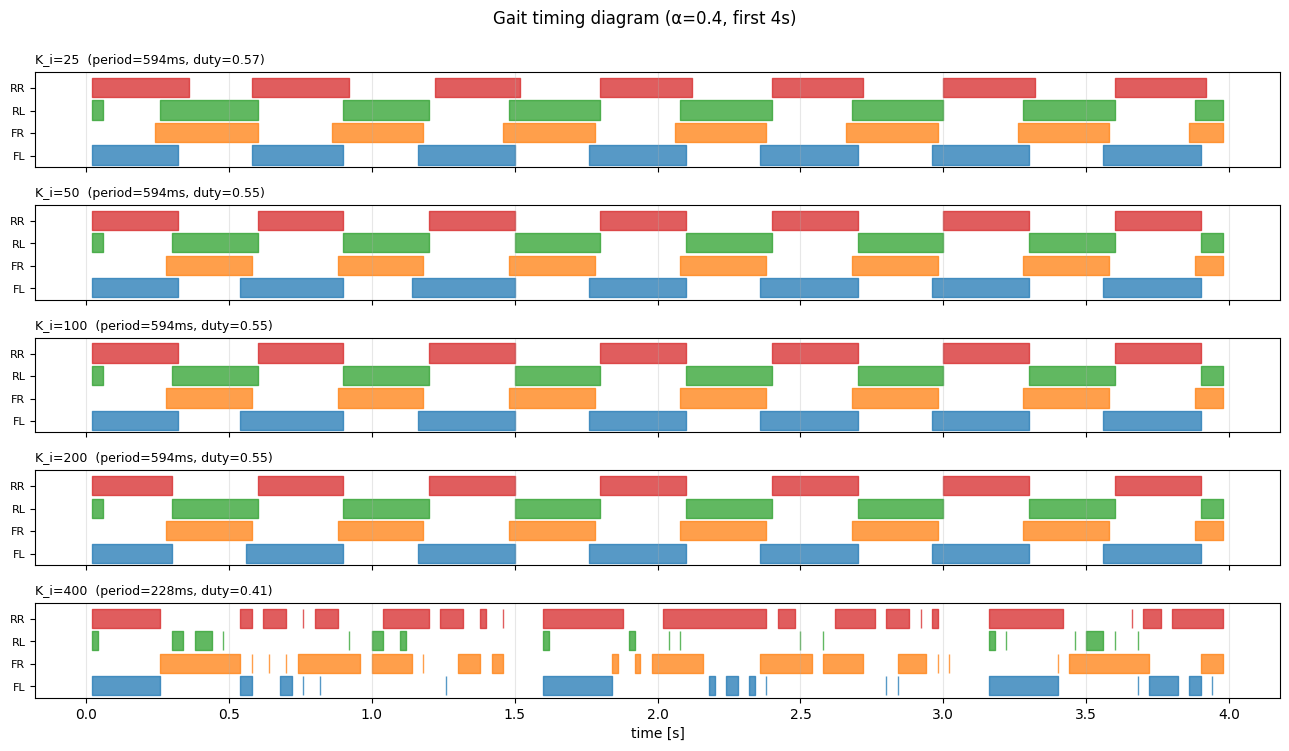

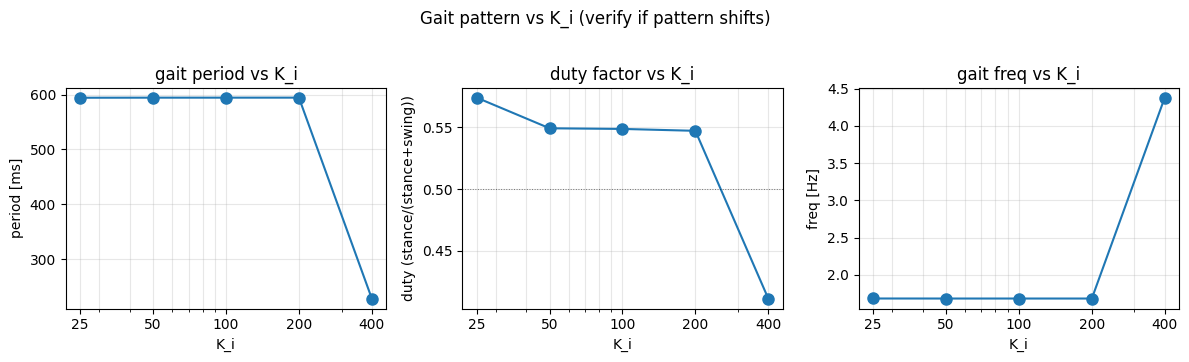

In [118]:
# ═══════════════════════════════════════════════════════════════════════
#  보행 timing diagram (Gantt) + stance/swing/duty factor 통계
#  - 위 셀 (cell 19) 의 ki_data 재사용. K_i 별 4 개 발 패턴을 가로 막대로.
#  - trot 이면 (FL+RR), (FR+RL) 대각 쌍이 동기화돼 교대로 디뎌짐.
# ═══════════════════════════════════════════════════════════════════════

GAIT_T_MAX_S = 4.0   # Gantt 그림에 보일 시간 [s]


def stance_swing_stats(contact, dt):
    """contact: [N] bool array. 한 발의 stance/swing 길이 통계."""
    contact = np.asarray(contact).astype(bool)
    diff = np.diff(contact.astype(int))
    rises = np.where(diff > 0)[0] + 1   # touchdown
    falls = np.where(diff < 0)[0] + 1   # liftoff

    stance, swing = [], []
    if len(rises) > 1 and len(falls) > 1:
        # stance: rise → next fall
        for r in rises:
            f = falls[falls > r]
            if len(f):
                stance.append((f[0] - r) * dt)
        # swing: fall → next rise
        for f in falls:
            r = rises[rises > f]
            if len(r):
                swing.append((r[0] - f) * dt)
    return np.array(stance), np.array(swing)


def gait_summary(fc, fc_names, dt):
    """4 개 발 평균 stance/swing/duty factor."""
    stance_all, swing_all = [], []
    per_foot = {}
    for k, name in enumerate(fc_names):
        s, w = stance_swing_stats(fc[:, k], dt)
        stance_all.extend(s.tolist()); swing_all.extend(w.tolist())
        per_foot[name] = (s.mean() if len(s) else float('nan'),
                          w.mean() if len(w) else float('nan'))
    stance_all = np.array(stance_all); swing_all = np.array(swing_all)
    if len(stance_all) > 0 and len(swing_all) > 0:
        duty = stance_all.mean() / (stance_all.mean() + swing_all.mean())
    else:
        duty = float('nan')
    return dict(stance_mean=stance_all.mean() if len(stance_all) else float('nan'),
                swing_mean=swing_all.mean() if len(swing_all) else float('nan'),
                duty=duty, per_foot=per_foot)


# ── Per-K_i 통계 표 ─────────────────────────────────────────
gait_rows = []
for ki in sorted(ki_data.keys()):
    d = ki_data[ki]
    stats = gait_summary(d['foot_contact'], d['foot_names'], d['dt'])
    gait_rows.append(dict(
        K_i=ki,
        stance_ms=stats['stance_mean']*1000 if not np.isnan(stats['stance_mean']) else float('nan'),
        swing_ms=stats['swing_mean']*1000 if not np.isnan(stats['swing_mean']) else float('nan'),
        period_ms=(stats['stance_mean']+stats['swing_mean'])*1000 if not np.isnan(stats['stance_mean']) else float('nan'),
        duty_factor=stats['duty'],
        freq_Hz=1/(stats['stance_mean']+stats['swing_mean']) if not np.isnan(stats['stance_mean']) and stats['stance_mean']+stats['swing_mean']>0 else float('nan'),
    ))
gait_df = pd.DataFrame(gait_rows).set_index('K_i')
print(f'=== Gait stats per K_i (α={DEMAG_FACTOR}, first {MAX_DATA_S:.0f}s) ===')
print('  duty factor = stance / (stance + swing) — trot 의 정상값 ~0.5')
display(gait_df.style.format('{:.2f}', na_rep='-'))


# ── Per-K_i Gantt 차트 ────────────────────────────────────
n_ki = len(ki_data)
fig_g, axes_g = plt.subplots(n_ki, 1, figsize=(13, 1.4*n_ki + 0.5),
                              sharex=True)
if n_ki == 1:
    axes_g = [axes_g]
foot_colors = {'FL': 'tab:blue', 'FR': 'tab:orange',
               'RL': 'tab:green', 'RR': 'tab:red'}

for ax, ki in zip(axes_g, sorted(ki_data.keys())):
    d = ki_data[ki]
    dt = d['dt']
    n_show = min(d['n_steps'], int(round(GAIT_T_MAX_S / dt)))
    t_arr = np.arange(n_show) * dt
    for k, name in enumerate(d['foot_names']):
        contact = d['foot_contact'][:n_show, k] > 0
        # 'leg' (FL/FR/RL/RR) 키만 추출
        leg = next((kw for kw in foot_colors if kw in name), '')
        c = foot_colors.get(leg, 'gray')
        ax.fill_between(t_arr, k, k + 0.85, where=contact, step='post',
                        color=c, alpha=0.75)
    ax.set_yticks(np.arange(len(d['foot_names'])) + 0.4)
    ax.set_yticklabels([name.replace('_foot_collision', '') for name in d['foot_names']],
                        fontsize=8)
    ax.set_ylim(-0.1, len(d['foot_names']) + 0.1)
    period = gait_df.loc[ki, 'period_ms']
    duty   = gait_df.loc[ki, 'duty_factor']
    ax.set_title(f'K_i={ki}  (period={period:.0f}ms, duty={duty:.2f})',
                  fontsize=9, loc='left')
    ax.grid(True, axis='x', alpha=0.3)

axes_g[-1].set_xlabel('time [s]')
fig_g.suptitle(f'Gait timing diagram (α={DEMAG_FACTOR}, first {GAIT_T_MAX_S:.0f}s)',
                y=0.995)
fig_g.tight_layout()
fig_g.savefig(OUTPUT_DIR / f'fig_gait_gantt_a{DEMAG_FACTOR:.2f}.png',
               dpi=120, bbox_inches='tight')
plt.show()


# ── Duty factor + period vs K_i 작은 그래프 ───────────────
fig_dp, axes_dp = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, key, title, ylab in [
    (axes_dp[0], 'period_ms', 'gait period vs K_i', 'period [ms]'),
    (axes_dp[1], 'duty_factor', 'duty factor vs K_i', 'duty (stance/(stance+swing))'),
    (axes_dp[2], 'freq_Hz', 'gait freq vs K_i', 'freq [Hz]')]:
    ax.plot(gait_df.index, gait_df[key], 'o-', color='tab:blue', lw=1.5, ms=8)
    ax.set_xscale('log'); ax.set_xticks(list(gait_df.index))
    ax.set_xticklabels([str(k) for k in gait_df.index])
    ax.set_xlabel('K_i'); ax.set_ylabel(ylab); ax.set_title(title)
    ax.grid(alpha=0.3, which='both')
axes_dp[1].axhline(0.5, color='k', ls=':', lw=0.7, alpha=0.5)   # trot reference
fig_dp.suptitle('Gait pattern vs K_i (verify if pattern shifts)', y=1.02)
fig_dp.tight_layout()
fig_dp.savefig(OUTPUT_DIR / f'fig_gait_metrics_a{DEMAG_FACTOR:.2f}.png',
                dpi=120, bbox_inches='tight')
plt.show()


[Gantt 비교] 9 (Ki, α) 쌍 로드
=== Gait stats: healthy vs demag (α=0.4, first 10s) ===


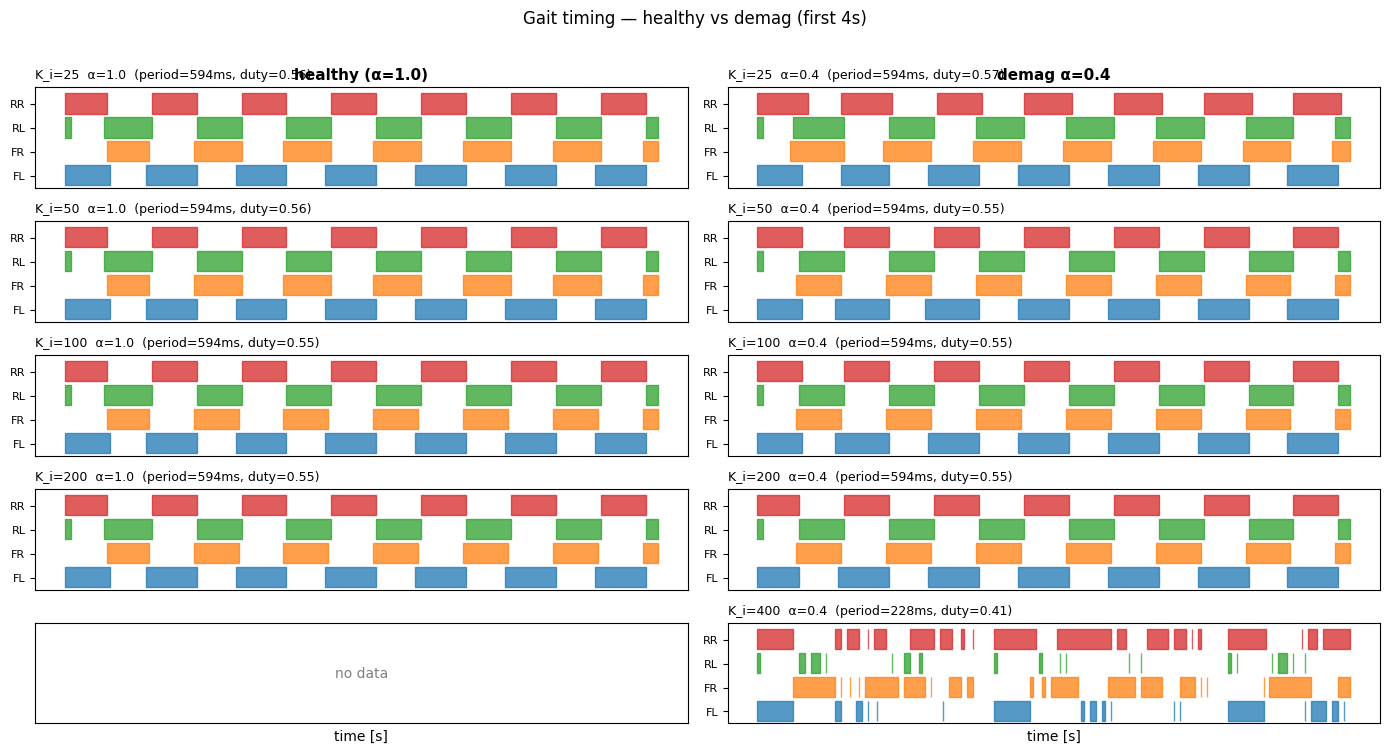

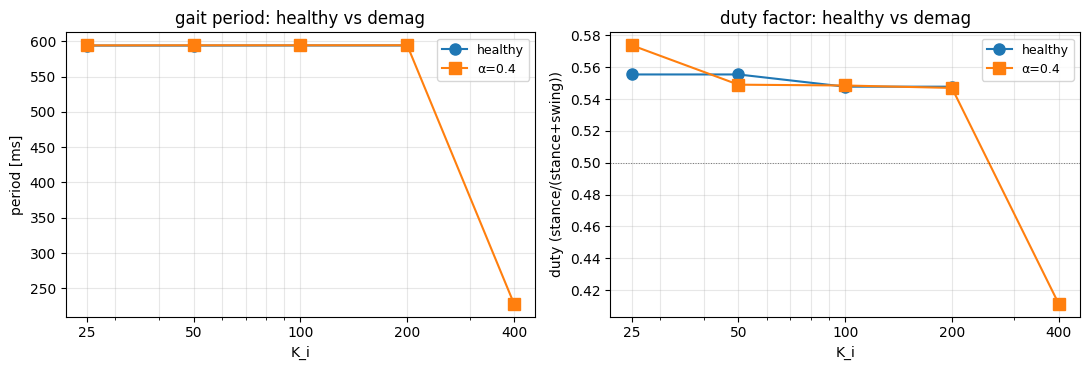

In [119]:
# ═══════════════════════════════════════════════════════════════════════
#  Gait timing diagram — healthy(α=1.0) vs demag(α=DEMAG_FACTOR) 비교
#  K_i 별 보행 패턴 변화를 좌우 나란히 (left=healthy, right=demag) 표시.
#  + α 별 (stance, swing, period, duty) 통계 표.
#  cell 19 의 ki_dir, OUTPUT_DIR, DEMAG_FACTOR, MAX_DATA_S, GAIT_T_MAX_S 재사용.
# ═══════════════════════════════════════════════════════════════════════

# 비교할 alpha 목록. 추가 demag 조건도 columns 로 더 붙일 수 있음.
COMPARE_ALPHAS = [1.0, DEMAG_FACTOR]


def _load_fc(ki, alpha):
    """foot_contact + meta 만 가볍게 로드."""
    try:
        d, m = load_case(ki_dir(ki), alpha)
    except FileNotFoundError:
        return None
    dt = float(m['dt'])
    n = min(m['num_steps'], int(round(MAX_DATA_S / dt)))
    return dict(fc=d['foot_contact'][:n, :].copy(),
                fc_names=m['foot_contact_names'],
                dt=dt, n=n)


# 가용 (ki, alpha) 만 자동 선별
fc_grid = {}
for ki in sorted(ki_data.keys()):
    for a in COMPARE_ALPHAS:
        rec = _load_fc(ki, a)
        if rec is not None:
            fc_grid[(ki, a)] = rec
print(f'[Gantt 비교] {len(fc_grid)} (Ki, α) 쌍 로드')


# ── 통계 표 ─────────────────────────────────────────────────────
stat_rows = []
for ki in sorted(ki_data.keys()):
    for a in COMPARE_ALPHAS:
        if (ki, a) not in fc_grid:
            continue
        rec = fc_grid[(ki, a)]
        s = gait_summary(rec['fc'], rec['fc_names'], rec['dt'])
        period = s['stance_mean'] + s['swing_mean']
        stat_rows.append(dict(
            K_i=ki, alpha=a,
            stance_ms=s['stance_mean']*1000 if not np.isnan(s['stance_mean']) else float('nan'),
            swing_ms=s['swing_mean']*1000 if not np.isnan(s['swing_mean']) else float('nan'),
            period_ms=period*1000 if not np.isnan(period) else float('nan'),
            duty=s['duty'],
            freq_Hz=1/period if not np.isnan(period) and period > 0 else float('nan'),
        ))
stat_df = pd.DataFrame(stat_rows).set_index(['K_i', 'alpha'])
print(f'=== Gait stats: healthy vs demag (α={DEMAG_FACTOR}, first {MAX_DATA_S:.0f}s) ===')
display(stat_df.style.format('{:.2f}', na_rep='-'))


# ── Gantt 그림: K_i 행 x α 열 ────────────────────────────────
n_ki = len(ki_data)
n_a  = len(COMPARE_ALPHAS)
fig_g, axes_g = plt.subplots(n_ki, n_a, figsize=(7*n_a, 1.4*n_ki + 0.5),
                              sharex=True, squeeze=False)
foot_colors = {'FL': 'tab:blue', 'FR': 'tab:orange',
               'RL': 'tab:green', 'RR': 'tab:red'}

for r, ki in enumerate(sorted(ki_data.keys())):
    for c, a in enumerate(COMPARE_ALPHAS):
        ax = axes_g[r, c]
        if (ki, a) not in fc_grid:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                     transform=ax.transAxes, fontsize=10, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
            continue
        rec = fc_grid[(ki, a)]
        dt = rec['dt']
        n_show = min(rec['n'], int(round(GAIT_T_MAX_S / dt)))
        t_arr = np.arange(n_show) * dt
        for k, name in enumerate(rec['fc_names']):
            contact = rec['fc'][:n_show, k] > 0
            leg = next((kw for kw in foot_colors if kw in name), '')
            col_color = foot_colors.get(leg, 'gray')
            ax.fill_between(t_arr, k, k + 0.85, where=contact, step='post',
                             color=col_color, alpha=0.75)
        ax.set_yticks(np.arange(len(rec['fc_names'])) + 0.4)
        ax.set_yticklabels([name.replace('_foot_collision', '')
                            for name in rec['fc_names']], fontsize=8)
        ax.set_ylim(-0.1, len(rec['fc_names']) + 0.1)

        # title with stats
        try:
            row = stat_df.loc[(ki, a)]
            title = f'K_i={ki}  α={a}  (period={row["period_ms"]:.0f}ms, duty={row["duty"]:.2f})'
        except Exception:
            title = f'K_i={ki}  α={a}'
        ax.set_title(title, fontsize=9, loc='left')
        ax.grid(True, axis='x', alpha=0.3)

# Column headers (top row 중앙 위)
for c, a in enumerate(COMPARE_ALPHAS):
    label = 'healthy (α=1.0)' if a >= 1.0 else f'demag α={a}'
    axes_g[0, c].annotate(label, xy=(0.5, 1.08), xycoords='axes fraction',
                            ha='center', fontsize=11, fontweight='bold')

axes_g[-1, 0].set_xlabel('time [s]')
if n_a > 1:
    axes_g[-1, -1].set_xlabel('time [s]')

fig_g.suptitle(f'Gait timing — healthy vs demag (first {GAIT_T_MAX_S:.0f}s)',
                y=0.998)
fig_g.tight_layout(rect=[0, 0, 1, 0.985])
fig_g.savefig(OUTPUT_DIR / f'fig_gait_gantt_compare.png',
                dpi=120, bbox_inches='tight')
plt.show()


# ── duty / period 변화량 시각화 ─────────────────────────────
fig_dp, axes_dp = plt.subplots(1, 2, figsize=(11, 3.8))
for c, key, ylab, title in [
    (0, 'period_ms', 'period [ms]', 'gait period: healthy vs demag'),
    (1, 'duty',      'duty (stance/(stance+swing))', 'duty factor: healthy vs demag'),
]:
    ax = axes_dp[c]
    for a in COMPARE_ALPHAS:
        kis = sorted({ki for (ki, aa) in stat_df.index if aa == a})
        ys = [stat_df.loc[(ki, a), key] for ki in kis if (ki, a) in stat_df.index]
        kis_avail = [ki for ki in kis if (ki, a) in stat_df.index]
        marker = 'o' if a >= 1.0 else 's'
        lbl = f'α={a}' if a < 1.0 else 'healthy'
        ax.plot(kis_avail, ys, '-', marker=marker, ms=8, lw=1.5, label=lbl)
    ax.set_xscale('log')
    ax.set_xticks(sorted(ki_data.keys()))
    ax.set_xticklabels([str(ki) for ki in sorted(ki_data.keys())])
    ax.set_xlabel('K_i')
    ax.set_ylabel(ylab); ax.set_title(title)
    ax.grid(alpha=0.3, which='both')
    ax.legend(fontsize=9)
axes_dp[1].axhline(0.5, color='k', ls=':', lw=0.7, alpha=0.5)
fig_dp.tight_layout()
fig_dp.savefig(OUTPUT_DIR / f'fig_gait_metrics_compare.png',
                dpi=120, bbox_inches='tight')
plt.show()


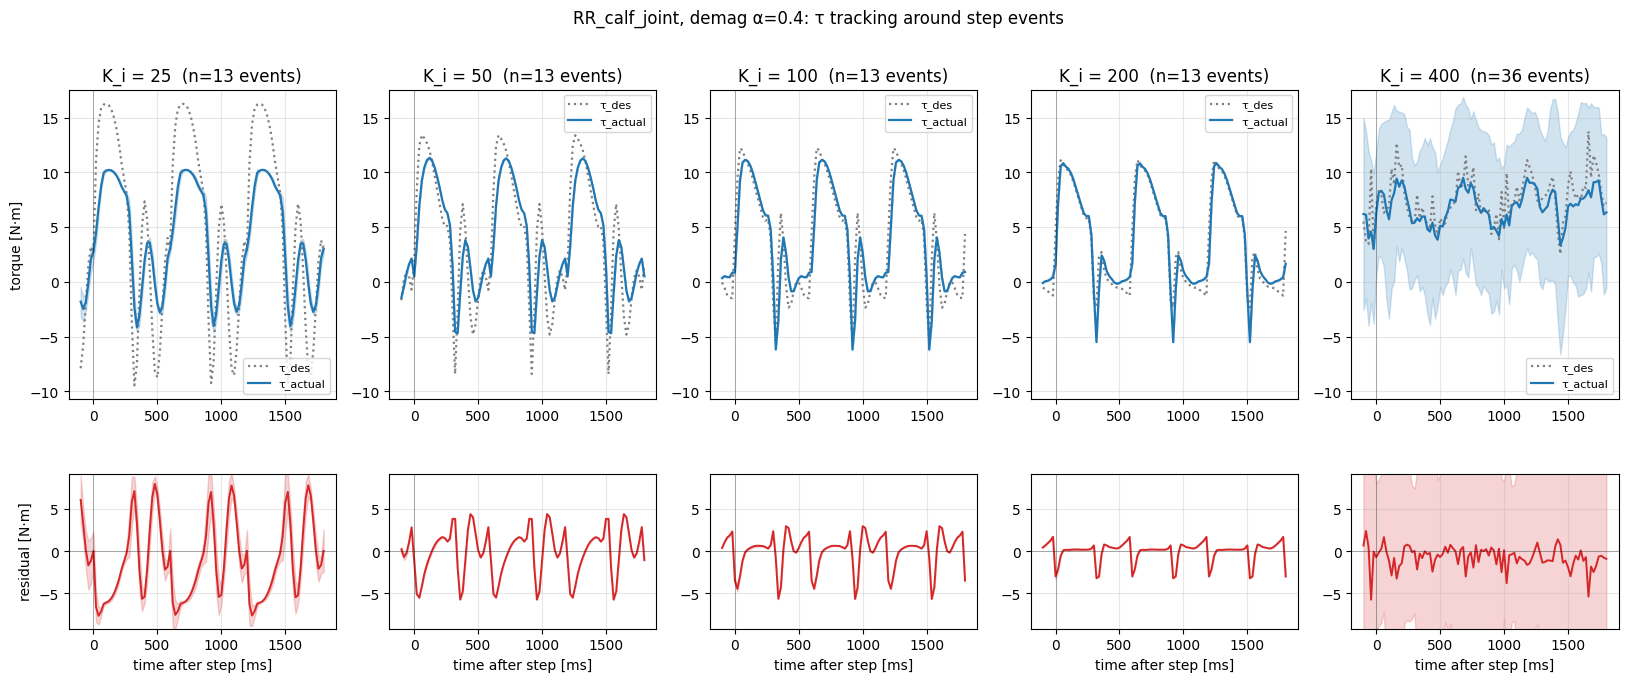

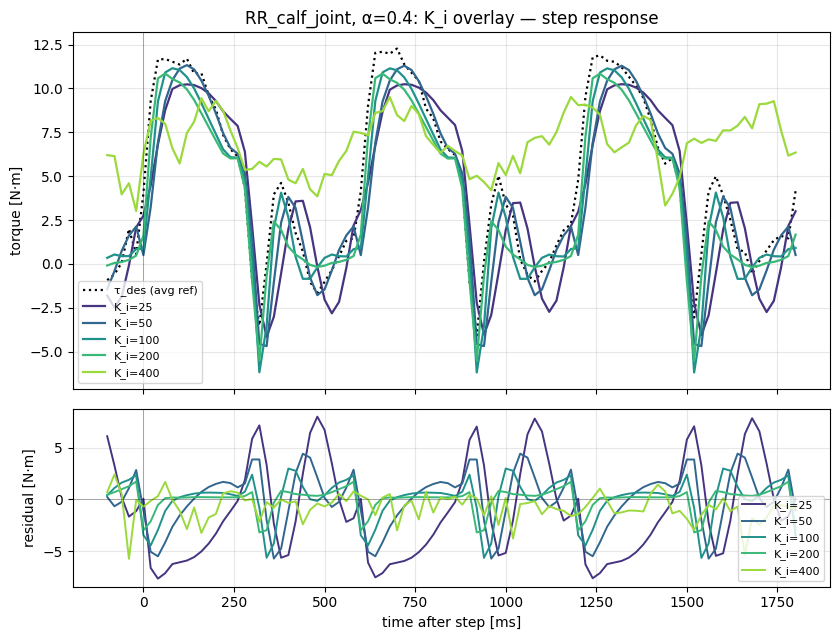

In [116]:
# ═══════════════════════════════════════════════════════════════════════
#  [Cell 3] 시간 영역 시각화 — Figure A (per-Ki panels) + Figure B (overlay)
# ═══════════════════════════════════════════════════════════════════════

if not windows:
    print('[SKIP] windows 비어있음. 위 셀 먼저 실행.')
else:
    ki_sorted = sorted(windows.keys())

    # 글로벌 y-범위 (Figure A panel 통일용)
    all_tau_lo = min(min(w['tau_des_mean'].min(), w['tau_act_mean'].min()) for w in windows.values())
    all_tau_hi = max(max(w['tau_des_mean'].max(), w['tau_act_mean'].max()) for w in windows.values())
    pad_t = 0.05 * (all_tau_hi - all_tau_lo)
    TAU_YLIM = (all_tau_lo - pad_t, all_tau_hi + pad_t)

    res_max = max(np.abs(w['tau_act_mean'] - w['tau_des_mean']).max() for w in windows.values())
    RES_YLIM = (-res_max * 1.15, res_max * 1.15)

    # ─── Figure A: per-Ki panels ───
    n_ki = len(windows)
    fig_a = plt.figure(figsize=(4 * n_ki, 7))
    gs = fig_a.add_gridspec(2, n_ki, height_ratios=[2, 1], hspace=0.32)

    for col, ki in enumerate(ki_sorted):
        w = windows[ki]
        n_pre = int(round(WINDOW_PRE_S / w['dt']))
        t = w['t_window'] * 1000  # ms

        ax_top = fig_a.add_subplot(gs[0, col])
        ax_top.plot(t, w['tau_des_mean'], color='gray', ls=':', lw=1.6, label='τ_des')
        ax_top.plot(t, w['tau_act_mean'], color='tab:blue', lw=1.6, label='τ_actual')
        ax_top.fill_between(t,
                             w['tau_act_mean'] - w['tau_act_std'],
                             w['tau_act_mean'] + w['tau_act_std'],
                             color='tab:blue', alpha=0.2)
        ax_top.axvline(0, color='k', lw=0.4, alpha=0.5)
        ax_top.set_ylim(*TAU_YLIM)
        ax_top.set_title(f'K_i = {ki}  (n={w["n_events"]} events)')
        ax_top.grid(alpha=0.3)
        if col == 0:
            ax_top.set_ylabel('torque [N·m]')
        ax_top.legend(fontsize=8, loc='best')

        ax_bot = fig_a.add_subplot(gs[1, col], sharex=ax_top)
        res_mean = w['tau_act_mean'] - w['tau_des_mean']
        res_std  = np.sqrt(w['tau_act_std']**2 + w['tau_des_std']**2)
        ax_bot.plot(t, res_mean, color='tab:red', lw=1.4)
        ax_bot.fill_between(t, res_mean - res_std, res_mean + res_std,
                             color='tab:red', alpha=0.2)
        ax_bot.axhline(0, color='k', lw=0.4, alpha=0.5)
        ax_bot.axvline(0, color='k', lw=0.4, alpha=0.5)

        # ±5 % band relative to post-step τ_des
        # tau_ss_post = float(w['tau_des_mean'][n_pre + 5:].mean())
        # band = 0.05 * abs(tau_ss_post)
        # ax_bot.axhline(+band, color='k', ls='--', lw=0.6, alpha=0.5,
        #                 label=f'±5% (={band:.2f})')
        # ax_bot.axhline(-band, color='k', ls='--', lw=0.6, alpha=0.5)
        ax_bot.set_ylim(*RES_YLIM)
        ax_bot.set_xlabel('time after step [ms]')
        if col == 0:
            ax_bot.set_ylabel('residual [N·m]')
        ax_bot.grid(alpha=0.3)
        # ax_bot.legend(fontsize=7, loc='best')

    fig_a.suptitle(f'{JOINT}, demag α={DEMAG_FACTOR}: τ tracking around step events',
                    y=0.995)
    fig_a.savefig(OUTPUT_DIR / f'fig_A_panels_a{DEMAG_FACTOR:.2f}.png',
                   dpi=120, bbox_inches='tight')
    plt.show()

    # ─── Figure B: overlay ───
    fig_b, (ax_b1, ax_b2) = plt.subplots(2, 1, figsize=(8.5, 6.5), sharex=True,
                                           gridspec_kw=dict(height_ratios=[2, 1]))
    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0.15, 0.85, len(ki_sorted)))

    # 모든 K_i 의 τ_des 평균을 reference 로 (보통 거의 동일)
    ref_des = np.mean([windows[ki]['tau_des_mean'] for ki in ki_sorted], axis=0)
    t_ref = windows[ki_sorted[0]]['t_window'] * 1000
    ax_b1.plot(t_ref, ref_des, color='k', ls=':', lw=1.6, label='τ_des (avg ref)')

    for ki, color in zip(ki_sorted, colors):
        w = windows[ki]
        t = w['t_window'] * 1000
        ax_b1.plot(t, w['tau_act_mean'], color=color, lw=1.6, label=f'K_i={ki}')
        ax_b2.plot(t, w['tau_act_mean'] - w['tau_des_mean'], color=color, lw=1.4,
                    label=f'K_i={ki}')

    ax_b1.axvline(0, color='k', lw=0.4, alpha=0.5)
    ax_b1.set_ylabel('torque [N·m]'); ax_b1.grid(alpha=0.3)
    ax_b1.legend(fontsize=8, loc='best')
    ax_b1.set_title(f'{JOINT}, α={DEMAG_FACTOR}: K_i overlay — step response')
    ax_b2.axvline(0, color='k', lw=0.4, alpha=0.5)
    ax_b2.axhline(0, color='k', lw=0.4, alpha=0.5)
    ax_b2.set_ylabel('residual [N·m]')
    ax_b2.set_xlabel('time after step [ms]')
    ax_b2.grid(alpha=0.3); ax_b2.legend(fontsize=8, loc='best')
    fig_b.tight_layout()
    fig_b.savefig(OUTPUT_DIR / f'fig_B_overlay_a{DEMAG_FACTOR:.2f}.png',
                   dpi=120, bbox_inches='tight')
    plt.show()

[multi-α] 가용 (Ki, α) 쌍: 23 개


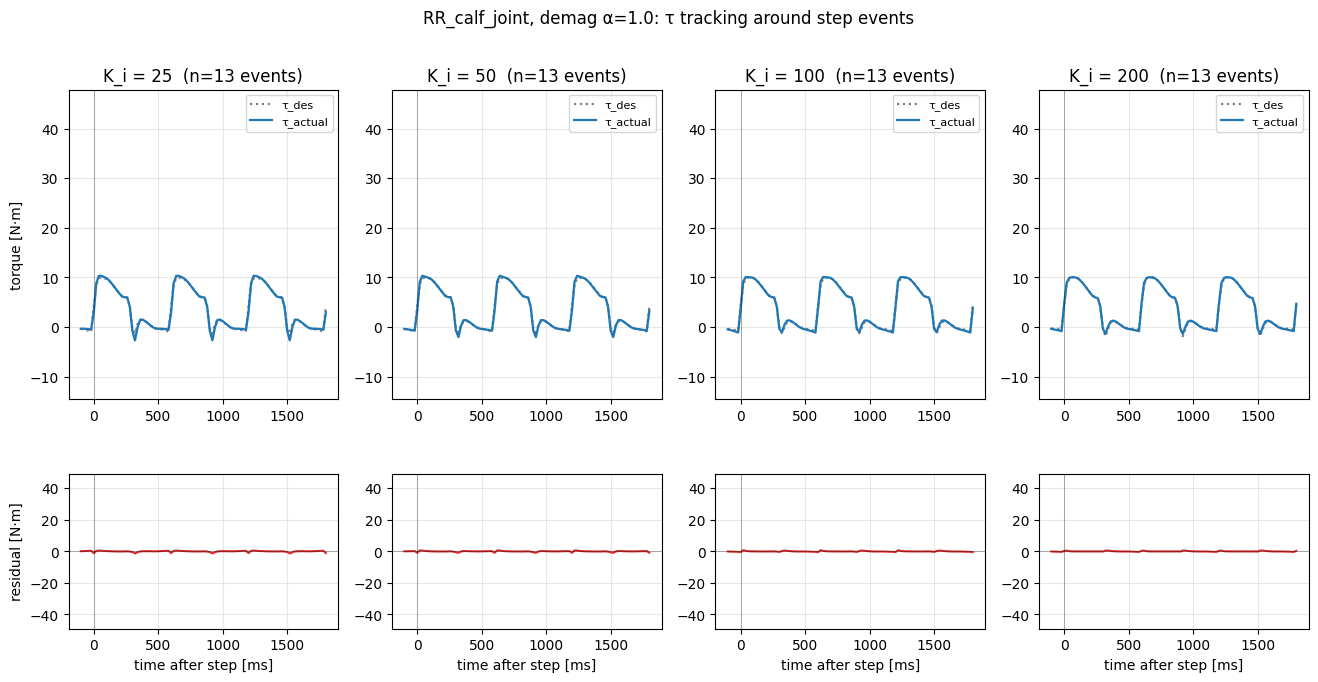

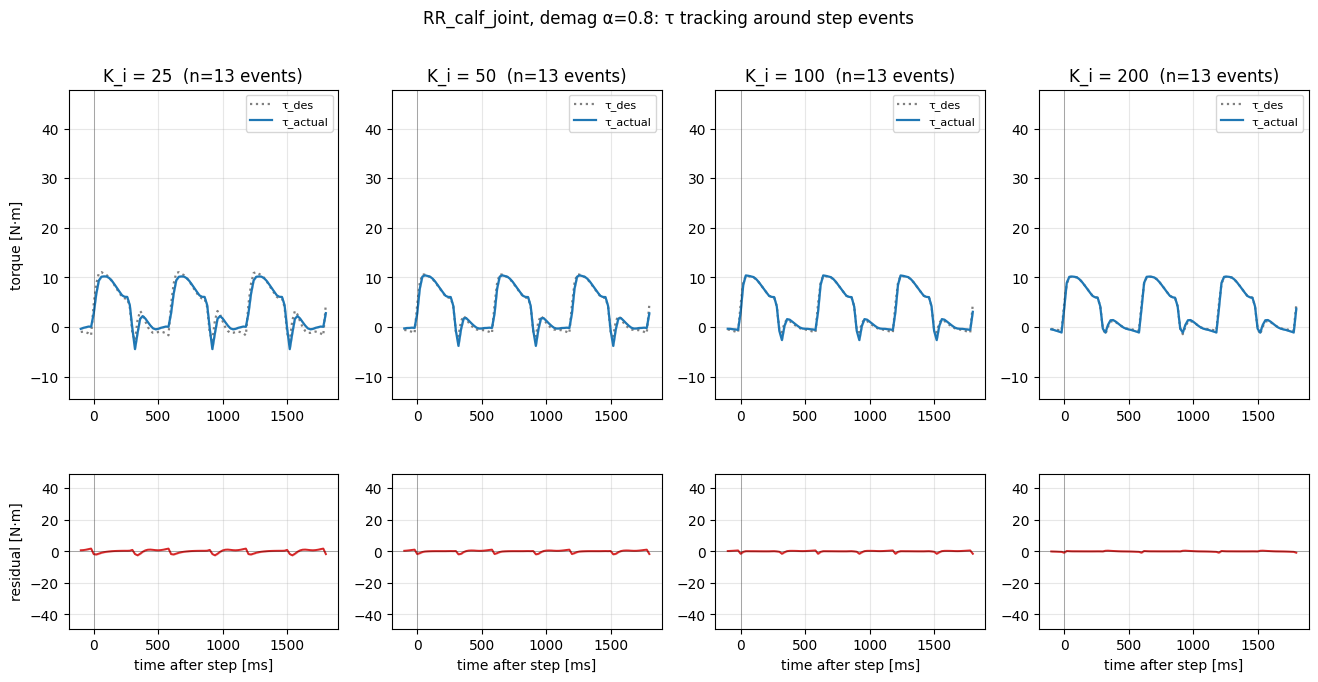

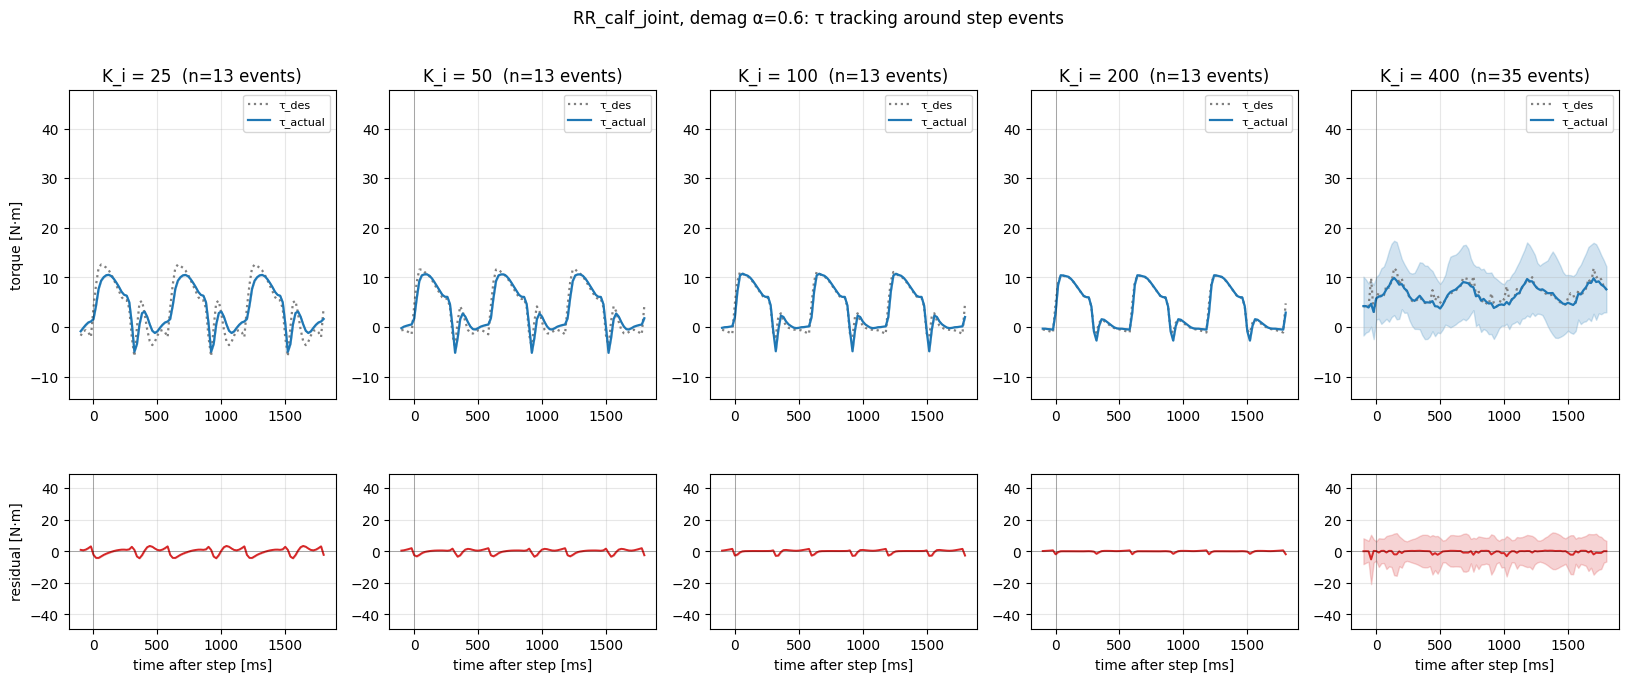

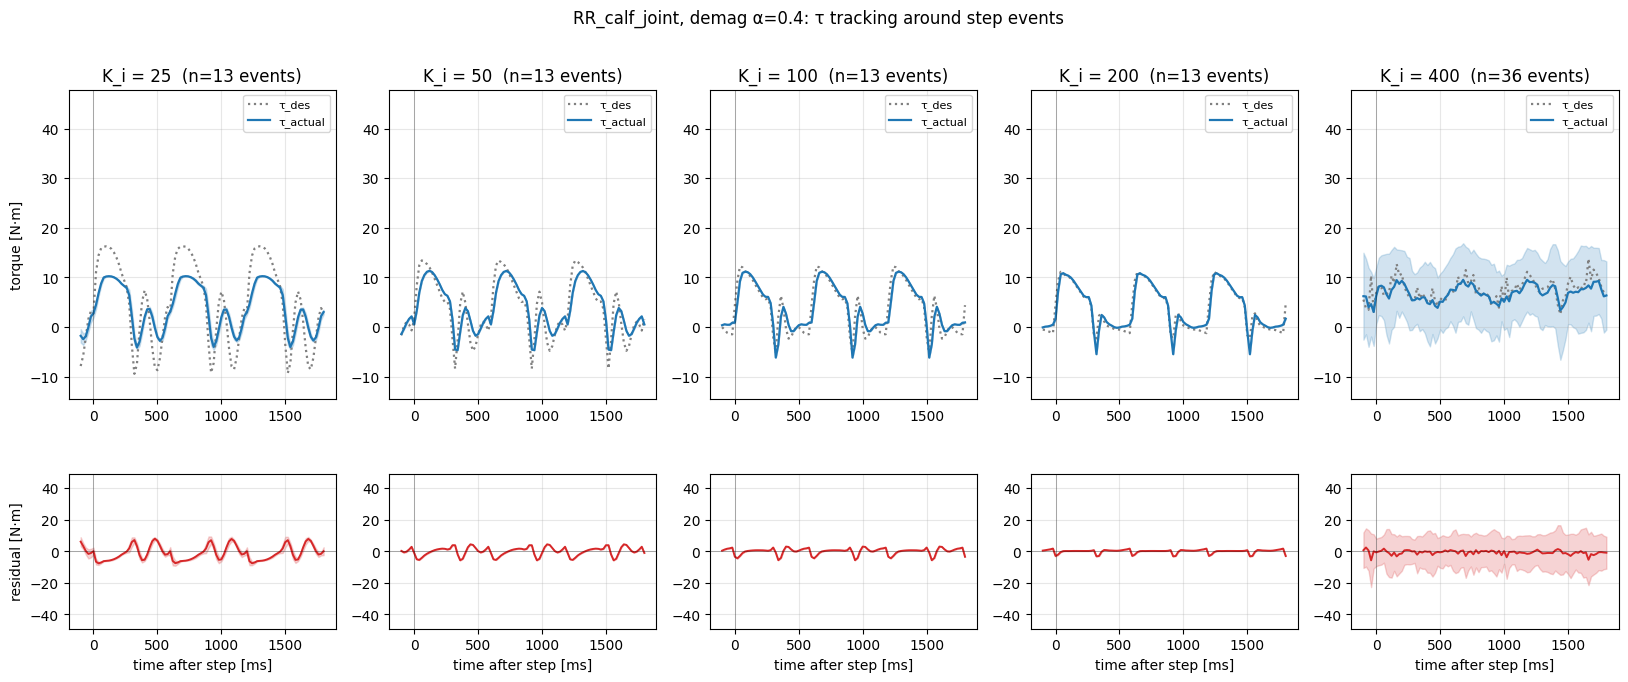

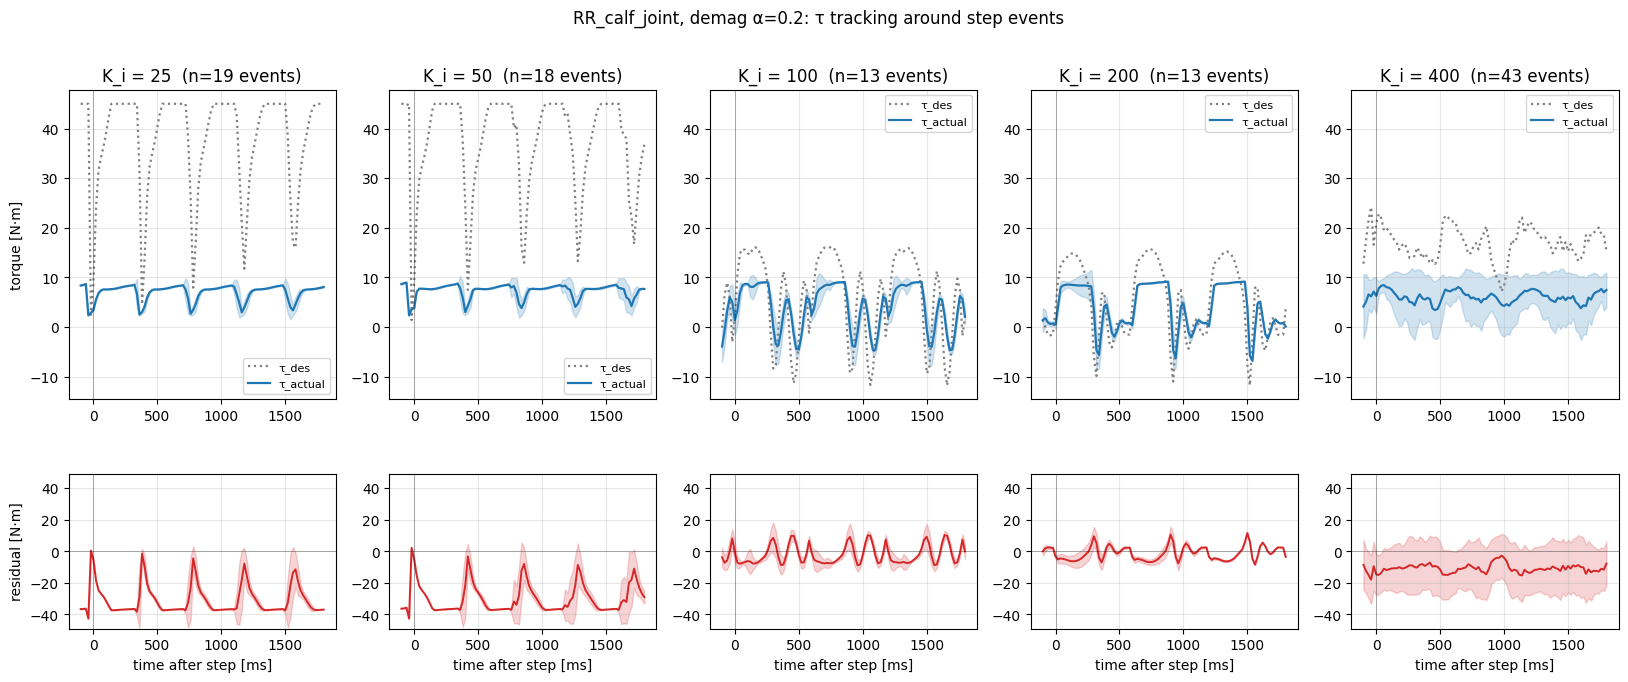


GLOBAL_TAU_YLIM=True, GLOBAL_RES_YLIM=True
  → True: 모든 α 그림 같은 y-범위 (직접 비교 쉬움)
  → False: per-α 자동 스케일 (작은 α 도 잘 보임)


In [117]:
# ═══════════════════════════════════════════════════════════════════════
#  Multi-α Fig A — 여러 demag 조건에 대해 K_i 별 panel 자동 생성
#  cell 19 의 헬퍼 (load_case, col_idx, rolling_mean, OUTPUT_DIR, 등) 재사용.
#  각 α 마다 (Ki x panel) 그림 1 장씩 + PNG 저장.
# ═══════════════════════════════════════════════════════════════════════

ALPHA_LIST       = [1.0, 0.8, 0.6, 0.4, 0.2]   # 보고 싶은 demag 조건
KI_FOR_MULTI     = [25, 50, 100, 200, 400]     # 각 α 에서 가용한 K_i 만 자동 선별
GLOBAL_TAU_YLIM  = True   # True: 모든 α / K_i 공통 y축 (직접 비교) / False: per-figure 자동
GLOBAL_RES_YLIM  = True


def _build_windows(ki, alpha):
    """단일 (Ki, α) → window stack. cell 19 와 동일 로직 (foot_contact 이벤트)."""
    try:
        d, m = load_case(ki_dir(ki), alpha)
    except FileNotFoundError:
        return None
    j = col_idx(m, JOINT)
    dt = float(m['dt'])
    n = min(m['num_steps'], int(round(MAX_DATA_S / dt)))
    td = d['tau_des'][:n, j].astype(np.float64)
    ta = d['tau_actual'][:n, j].astype(np.float64)
    fc = d['foot_contact'][:n, :]
    fc_names = m['foot_contact_names']

    n_pre  = int(round(WINDOW_PRE_S  / dt))
    n_post = int(round(WINDOW_POST_S / dt))

    if EVENT_SOURCE == 'foot_contact':
        col = next((k for k, name in enumerate(fc_names) if EVENT_FOOT in name), 0)
        contact = fc[:, col].astype(int)
        rises = np.where(np.diff(contact) > 0)[0] + 1
        skip_n = int(round(SKIP_EARLY_S / dt))
        events = rises[rises >= skip_n]
    else:
        events, _, _ = detect_step_events(td, dt)

    s_des, s_act = [], []
    for ev in events:
        if ev < n_pre or ev + n_post >= n:
            continue
        s_des.append(td[ev - n_pre : ev + n_post + 1])
        s_act.append(ta[ev - n_pre : ev + n_post + 1])
    if not s_des:
        return None
    s_des = np.array(s_des); s_act = np.array(s_act)
    return dict(
        t_window=np.arange(-n_pre, n_post + 1) * dt,
        dt=dt, n_events=len(s_des),
        tau_des_mean=s_des.mean(0), tau_des_std=s_des.std(0),
        tau_act_mean=s_act.mean(0), tau_act_std=s_act.std(0),
        n_pre=n_pre,
    )


# ── 모든 (Ki, α) windows 미리 계산 (글로벌 y-범위 산출용) ─────
all_windows = {}
for alpha in ALPHA_LIST:
    for ki in KI_FOR_MULTI:
        w = _build_windows(ki, alpha)
        if w is not None:
            all_windows[(ki, alpha)] = w
print(f'[multi-α] 가용 (Ki, α) 쌍: {len(all_windows)} 개')

# 글로벌 y-범위
if all_windows:
    tau_lo = min(min(w['tau_des_mean'].min(), w['tau_act_mean'].min())
                 for w in all_windows.values())
    tau_hi = max(max(w['tau_des_mean'].max(), w['tau_act_mean'].max())
                 for w in all_windows.values())
    pad = 0.05 * (tau_hi - tau_lo)
    G_TAU_YLIM = (tau_lo - pad, tau_hi + pad)
    res_max = max(np.abs(w['tau_act_mean'] - w['tau_des_mean']).max()
                   for w in all_windows.values())
    G_RES_YLIM = (-res_max * 1.15, res_max * 1.15)
else:
    G_TAU_YLIM = G_RES_YLIM = None


# ── α 별로 Figure A 그리기 ─────────────────────────────────
for alpha in ALPHA_LIST:
    avail_ki = [ki for ki in KI_FOR_MULTI if (ki, alpha) in all_windows]
    if not avail_ki:
        print(f'[skip α={alpha}] 가용 데이터 없음')
        continue
    n_ki = len(avail_ki)

    # Per-α 자체 y-범위 (옵션)
    sub_w = [all_windows[(ki, alpha)] for ki in avail_ki]
    tau_lo_a = min(min(w['tau_des_mean'].min(), w['tau_act_mean'].min()) for w in sub_w)
    tau_hi_a = max(max(w['tau_des_mean'].max(), w['tau_act_mean'].max()) for w in sub_w)
    pad_a = 0.05 * (tau_hi_a - tau_lo_a if tau_hi_a > tau_lo_a else 1.0)
    LOC_TAU_YLIM = (tau_lo_a - pad_a, tau_hi_a + pad_a)
    res_max_a = max(np.abs(w['tau_act_mean'] - w['tau_des_mean']).max() for w in sub_w)
    LOC_RES_YLIM = (-res_max_a * 1.15, res_max_a * 1.15)

    tau_ylim = G_TAU_YLIM if GLOBAL_TAU_YLIM else LOC_TAU_YLIM
    res_ylim = G_RES_YLIM if GLOBAL_RES_YLIM else LOC_RES_YLIM

    fig = plt.figure(figsize=(4 * n_ki, 7))
    gs = fig.add_gridspec(2, n_ki, height_ratios=[2, 1], hspace=0.32)

    for col, ki in enumerate(avail_ki):
        w = all_windows[(ki, alpha)]
        n_pre = w['n_pre']
        t = w['t_window'] * 1000  # ms

        ax_top = fig.add_subplot(gs[0, col])
        ax_top.plot(t, w['tau_des_mean'], color='gray', ls=':', lw=1.6, label='τ_des')
        ax_top.plot(t, w['tau_act_mean'], color='tab:blue', lw=1.6, label='τ_actual')
        ax_top.fill_between(t,
                             w['tau_act_mean'] - w['tau_act_std'],
                             w['tau_act_mean'] + w['tau_act_std'],
                             color='tab:blue', alpha=0.2)
        ax_top.axvline(0, color='k', lw=0.4, alpha=0.5)
        ax_top.set_ylim(*tau_ylim)
        ax_top.set_title(f'K_i = {ki}  (n={w["n_events"]} events)')
        ax_top.grid(alpha=0.3)
        if col == 0:
            ax_top.set_ylabel('torque [N·m]')
        ax_top.legend(fontsize=8, loc='best')

        ax_bot = fig.add_subplot(gs[1, col], sharex=ax_top)
        res_mean = w['tau_act_mean'] - w['tau_des_mean']
        res_std  = np.sqrt(w['tau_act_std']**2 + w['tau_des_std']**2)
        ax_bot.plot(t, res_mean, color='tab:red', lw=1.4)
        ax_bot.fill_between(t, res_mean - res_std, res_mean + res_std,
                             color='tab:red', alpha=0.2)
        ax_bot.axhline(0, color='k', lw=0.4, alpha=0.5)
        ax_bot.axvline(0, color='k', lw=0.4, alpha=0.5)
        # tau_ss_post = float(w['tau_des_mean'][n_pre + 5:].mean())
        # band = 0.05 * abs(tau_ss_post)
        # ax_bot.axhline(+band, color='k', ls='--', lw=0.6, alpha=0.5,
        #                 label=f'±5% (={band:.2f})')
        # ax_bot.axhline(-band, color='k', ls='--', lw=0.6, alpha=0.5)
        ax_bot.set_ylim(*res_ylim)
        ax_bot.set_xlabel('time after step [ms]')
        if col == 0:
            ax_bot.set_ylabel('residual [N·m]')
        ax_bot.grid(alpha=0.3)
        # ax_bot.legend(fontsize=7, loc='best')

    fig.suptitle(f'{JOINT}, demag α={alpha}: τ tracking around step events',
                  y=0.995)
    fig.savefig(OUTPUT_DIR / f'fig_A_panels_a{alpha:.2f}.png',
                  dpi=120, bbox_inches='tight')
    plt.show()

print(f'\nGLOBAL_TAU_YLIM={GLOBAL_TAU_YLIM}, GLOBAL_RES_YLIM={GLOBAL_RES_YLIM}')
print('  → True: 모든 α 그림 같은 y-범위 (직접 비교 쉬움)')
print('  → False: per-α 자동 스케일 (작은 α 도 잘 보임)')

=== K_i tuning step-response metrics (α=0.4, window 3 gait cycles) ===
  rise/overshoot/undershoot: 첫 200 ms 안에서 측정
  ringing: 전체 post-event (1.8s) residual FFT
  sigma: σ(dτ_des/dt) — step event 탐지 임계 = 2.0σ


,n_events,sigma,rise_ms,overshoot_pct,undershoot_pct,ringing_hz,ringing_amp,step_amp
K_i,,,,,,,,
25,13.00,196.84,-,0.00,0.00,1.56,2.69,17.61
50,13.00,162.40,80.00,5.17,0.19,3.12,1.49,10.88
100,13.00,144.54,60.00,17.68,0.00,3.12,0.95,10.28
200,13.00,112.23,40.00,18.63,0.00,3.12,0.50,9.87
400,36.00,470.01,160.00,0.00,0.00,3.12,0.38,4.62


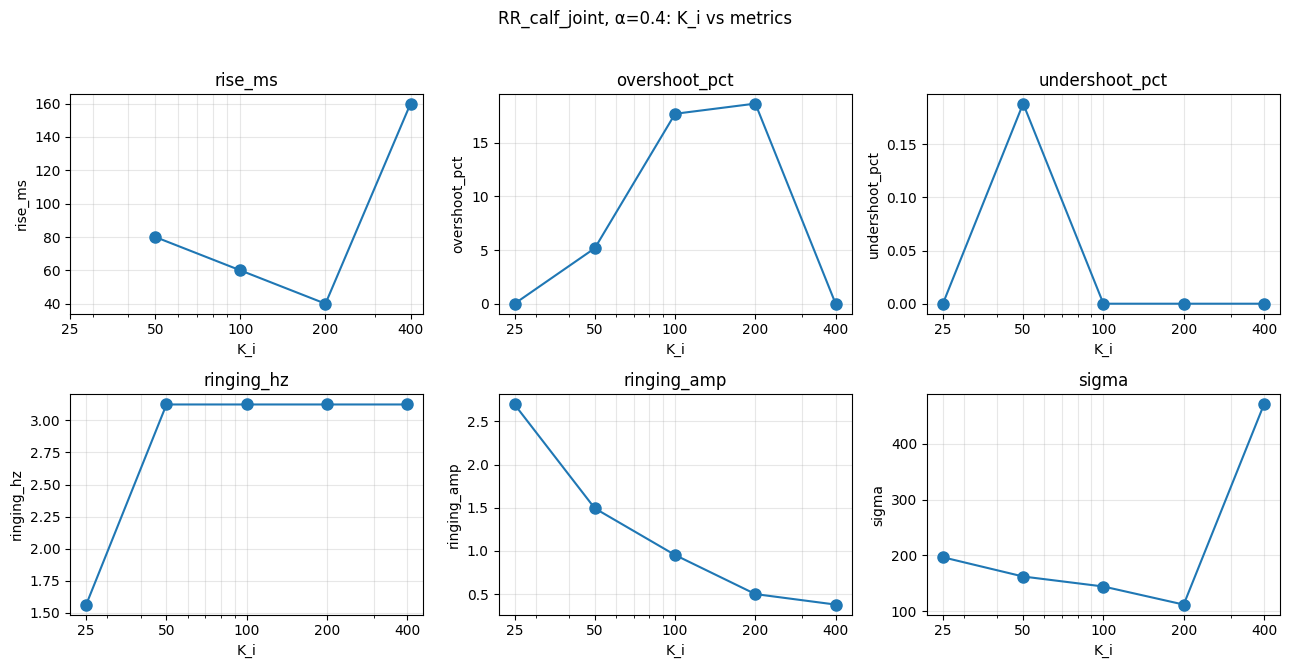

In [89]:
# ═══════════════════════════════════════════════════════════════════════
#  [Cell 4] 정량 지표 표 — rise / overshoot / undershoot / ringing
#
#  변화: window 가 길어져 (3 보행 주기) τ_des 가 주기적으로 진동 →
#  "settling time" 정의가 모호해짐. 대신:
#    - rise/overshoot/undershoot: 첫 200 ms (immediate transient) 내에서만 측정
#    - ringing: 전체 post-event window 의 residual FFT (긴 window → freq 해상도 향상)
# ═══════════════════════════════════════════════════════════════════════
from scipy.signal import welch

IMMEDIATE_TRANSIENT_S = 0.20   # rise/overshoot/undershoot 측정 윈도우


def step_metrics(w):
    """평균 윈도우에서 step response 지표 추출."""
    n_pre = int(round(WINDOW_PRE_S / w['dt']))
    n_imm = int(round(IMMEDIATE_TRANSIENT_S / w['dt']))
    tau_des = w['tau_des_mean']
    tau_act = w['tau_act_mean']
    res     = tau_act - tau_des

    # Immediate post-event range
    pre_des  = float(tau_des[:n_pre].mean())
    post_des = float(tau_des[n_pre + 5 : n_pre + n_imm].mean())
    pre_act  = float(tau_act[:n_pre].mean())
    step_amp = post_des - pre_des

    # Rise time (10→90 % of step) — within immediate window
    if abs(step_amp) > 1.0:    # 가드: step_amp 너무 작으면 % 분모 폭발
        target_90 = pre_act + 0.9 * step_amp
        post = tau_act[n_pre : n_pre + n_imm]
        if step_amp > 0:
            cross = np.where(post >= target_90)[0]
        else:
            cross = np.where(post <= target_90)[0]
        rise_ms = (cross[0] * w['dt'] * 1000) if len(cross) else float('nan')
    else:
        rise_ms = float('nan')

    # Overshoot / undershoot — within immediate window
    if abs(step_amp) > 1.0:    # 가드: step_amp 너무 작으면 % 분모 폭발
        post = tau_act[n_pre : n_pre + n_imm]
        if step_amp > 0:
            peak = float(post.max()); trough = float(post.min())
            overshoot  = max(0.0, (peak - post_des) / abs(step_amp) * 100)
            undershoot = max(0.0, (pre_act - trough) / abs(step_amp) * 100) if trough < pre_act else 0.0
        else:
            peak = float(post.max()); trough = float(post.min())
            overshoot  = max(0.0, (post_des - trough) / abs(step_amp) * 100)
            undershoot = max(0.0, (peak - pre_act) / abs(step_amp) * 100) if peak > pre_act else 0.0
    else:
        overshoot = undershoot = float('nan')

    # Ringing — residual FFT over FULL post-event window
    res_post = res[n_pre:]
    if len(res_post) >= 16:
        fs = 1.0 / w['dt']
        nperseg = min(len(res_post), 64)
        f_arr, Pxx = welch(res_post, fs=fs, nperseg=nperseg)
        if len(f_arr) > 2:
            peak_i = int(np.argmax(Pxx[1:]) + 1)
            ring_freq = float(f_arr[peak_i])
            ring_amp  = float(np.sqrt(Pxx[peak_i]))
        else:
            ring_freq = ring_amp = float('nan')
    else:
        ring_freq = ring_amp = float('nan')

    return dict(rise_ms=rise_ms,
                overshoot_pct=overshoot, undershoot_pct=undershoot,
                ringing_hz=ring_freq, ringing_amp=ring_amp,
                step_amp=step_amp,
                sigma=w.get('sigma', float('nan')))


if not windows:
    print('[SKIP]')
else:
    rows = []
    for ki in sorted(windows.keys()):
        w = windows[ki]
        m = step_metrics(w)
        m['K_i'] = ki
        m['n_events'] = w['n_events']
        rows.append(m)
    metrics_df = pd.DataFrame(rows).set_index('K_i')[
        ['n_events', 'sigma', 'rise_ms',
         'overshoot_pct', 'undershoot_pct',
         'ringing_hz', 'ringing_amp', 'step_amp']
    ]
    print(f'=== K_i tuning step-response metrics (α={DEMAG_FACTOR}, window {N_CYCLES_POST} gait cycles) ===')
    print(f'  rise/overshoot/undershoot: 첫 {IMMEDIATE_TRANSIENT_S*1000:.0f} ms 안에서 측정')
    print(f'  ringing: 전체 post-event ({WINDOW_POST_S:.1f}s) residual FFT')
    print(f'  sigma: σ(dτ_des/dt) — step event 탐지 임계 = {STEP_THR_NSIGMA}σ')
    display(metrics_df.style.format('{:.2f}', na_rep='-'))

    fig_m, axes_m = plt.subplots(2, 3, figsize=(13, 6.5))
    keys = ['rise_ms', 'overshoot_pct', 'undershoot_pct',
            'ringing_hz', 'ringing_amp', 'sigma']
    for ax, k in zip(axes_m.flat, keys):
        ax.plot(metrics_df.index, metrics_df[k], 'o-', color='tab:blue', lw=1.5, ms=8)
        ax.set_xlabel('K_i'); ax.set_xscale('log')
        ax.set_xticks(list(metrics_df.index))
        ax.set_xticklabels([str(k) for k in metrics_df.index])
        ax.set_ylabel(k); ax.set_title(k)
        ax.grid(alpha=0.3, which='both')
    fig_m.suptitle(f'{JOINT}, α={DEMAG_FACTOR}: K_i vs metrics', y=1.02)
    fig_m.tight_layout()
    fig_m.savefig(OUTPUT_DIR / f'fig_metrics_a{DEMAG_FACTOR:.2f}.png',
                   dpi=120, bbox_inches='tight')
    plt.show()

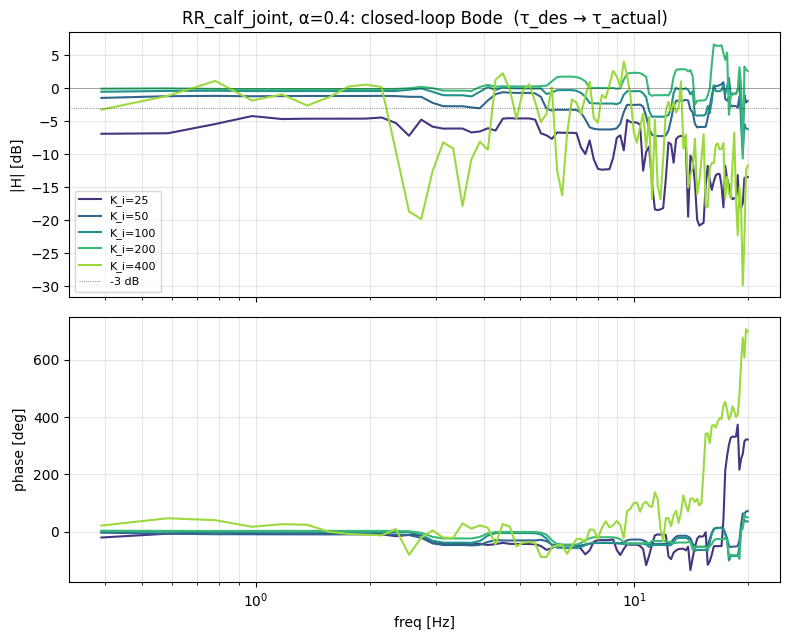

해석 가이드:
  - magnitude peak (>0 dB) at some freq f_r → resonance, 시간 영역 ringing 과 일치 검증
  - K_i ↑ 따라 -3 dB 코너가 오른쪽 (높은 freq) 로 이동하면 settling 빨라짐의 주파수 증거
  - phase −90° 도달 freq 도 K_i 와 함께 이동


In [98]:
# ═══════════════════════════════════════════════════════════════════════
#  [Cell 5, optional] Bode plot — 시간 영역 ringing 의 주파수 영역 검증
#  H(jω) = G_xy(τ_des, τ_actual) / G_xx(τ_des) 추정
# ═══════════════════════════════════════════════════════════════════════
from scipy.signal import csd

if not ki_data:
    print('[SKIP]')
else:
    fig_bode, (ax_mag, ax_ph) = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)
    ki_sorted2 = sorted(ki_data.keys())
    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0.15, 0.85, len(ki_sorted2)))

    for ki, color in zip(ki_sorted2, colors):
        d = ki_data[ki]
        fs = 1.0 / d['dt']
        # Welch: nperseg ~ 5s 윈도우 (250 step), overlap 50 %
        nperseg = min(len(d['tau_des']), 256)
        # 시뮬 초반 transient 제외
        skip_n = int(round(SKIP_EARLY_S / d['dt']))
        x = d['tau_des'][skip_n:] - d['tau_des'][skip_n:].mean()
        y = d['tau_actual'][skip_n:] - d['tau_actual'][skip_n:].mean()
        f, Pxx = welch(x, fs=fs, nperseg=nperseg)
        f, Pxy = csd(x, y, fs=fs, nperseg=nperseg)
        H = Pxy / np.where(Pxx > 1e-12, Pxx, 1e-12)
        mask = (f > 0.2) & (f < fs/2 * 0.8)
        ax_mag.semilogx(f[mask], 20*np.log10(np.abs(H[mask])),
                         color=color, lw=1.5, label=f'K_i={ki}')
        ax_ph.semilogx(f[mask], np.unwrap(np.angle(H[mask])) * 180 / np.pi,
                        color=color, lw=1.5)

    ax_mag.axhline(-3, color='k', ls=':', lw=0.6, alpha=0.6, label='-3 dB')
    ax_mag.axhline(0, color='k', ls='-', lw=0.4, alpha=0.5)
    ax_mag.set_ylabel('|H| [dB]')
    ax_mag.set_title(f'{JOINT}, α={DEMAG_FACTOR}: closed-loop Bode  (τ_des → τ_actual)')
    ax_mag.legend(fontsize=8, loc='best')
    ax_mag.grid(alpha=0.3, which='both')

    ax_ph.set_ylabel('phase [deg]')
    ax_ph.set_xlabel('freq [Hz]')
    ax_ph.grid(alpha=0.3, which='both')
    fig_bode.tight_layout()
    fig_bode.savefig(OUTPUT_DIR / f'fig_bode_a{DEMAG_FACTOR:.2f}.png',
                      dpi=120, bbox_inches='tight')
    plt.show()

    print('해석 가이드:')
    print('  - magnitude peak (>0 dB) at some freq f_r → resonance, 시간 영역 ringing 과 일치 검증')
    print('  - K_i ↑ 따라 -3 dB 코너가 오른쪽 (높은 freq) 로 이동하면 settling 빨라짐의 주파수 증거')
    print('  - phase −90° 도달 freq 도 K_i 와 함께 이동')

## 4. 정상상태 |I_actual| 비교 — 진단 신호 강도

감자 비율 vs 정상상태 |I_actual| (RR_calf, 마지막 10초 평균). ON 정책에서 1/α 배 가까운 비례성이 나오면 적분기가 정상 동작.

In [90]:
rows = []
for f in FACTORS:
    for p in ('aplus', 'aplus_tloop_ki200'):
        try:
            d, m = load_case(p, f)
        except FileNotFoundError:
            continue
        j = col_idx(m, JOINT)
        I_abs_ss = float(np.mean(np.abs(d['I_actual'][-500:, j])))
        tau_abs_ss = float(np.mean(np.abs(d['tau_actual'][-500:, j])))
        tcmd_abs_ss = float(np.mean(np.abs(d['tau_cmd'][-500:, j])))
        rows.append({'factor': f, 'policy': p,
                     '|I|_ss': I_abs_ss,
                     '|τ_actual|_ss': tau_abs_ss,
                     '|τ_cmd|_ss': tcmd_abs_ss,
                     'τ_actual/τ_cmd': tau_abs_ss / max(tcmd_abs_ss, 1e-6)})
ss = pd.DataFrame(rows).set_index(['factor', 'policy'])
ss.style.format('{:.4f}')

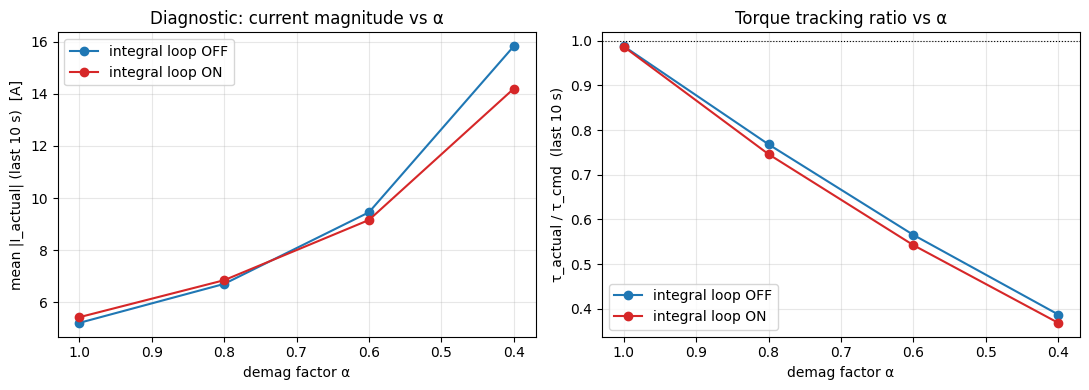

In [91]:
# Self-contained palette so this cell doesn't depend on cell-5's dicts.
_PALETTE = {
    'aplus':             ('tab:blue', 'integral loop OFF'),
    'aplus_tloop_ki200': ('tab:red',  'integral loop ON'),
}

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for p in ('aplus', 'aplus_tloop_ki200'):
    if p not in ss.index.get_level_values('policy'):
        print(f'[skip] policy {p!r} not in ss')
        continue
    sub = ss.xs(p, level='policy')
    c, lab = _PALETTE.get(p, ('k', p))
    ax[0].plot(sub.index, sub['|I|_ss'], 'o-', color=c, label=lab)
    ax[1].plot(sub.index, sub['τ_actual/τ_cmd'], 'o-', color=c, label=lab)
ax[0].set_xlabel('demag factor α')
ax[0].set_ylabel('mean |I_actual| (last 10 s)  [A]')
ax[0].set_title('Diagnostic: current magnitude vs α')
ax[0].invert_xaxis()
ax[1].set_xlabel('demag factor α')
ax[1].set_ylabel('τ_actual / τ_cmd  (last 10 s)')
ax[1].set_title('Torque tracking ratio vs α')
ax[1].axhline(1.0, color='k', ls=':', lw=0.8)
ax[1].invert_xaxis()
for a in ax:
    a.grid(alpha=0.3)
    a.legend()
fig.tight_layout()

## 5. 비교용 비디오 경로

프레임 by 프레임 비교는 jupyter 안에서 mp4 임베딩으로:

In [92]:
from IPython.display import Video, display, HTML

for f in FACTORS:
    tag = 'healthy' if f >= 1.0 else f'RR_{f:.1f}'
    paths = {
        'OFF': Path(f'./videos/aplus_{tag}.mp4'),
        'ON':  Path(f'./videos/aplus_tloop_{tag}.mp4'),
    }
    print(f'=== demag={f} ({tag}) ===')
    for k, p in paths.items():
        if p.exists():
            print(f'  {k}: {p}')
        else:
            print(f'  {k}: MISSING ({p})')

=== demag=1.0 (healthy) ===
  OFF: videos/aplus_healthy.mp4
  ON: videos/aplus_tloop_healthy.mp4
=== demag=0.8 (RR_0.8) ===
  OFF: videos/aplus_RR_0.8.mp4
  ON: videos/aplus_tloop_RR_0.8.mp4
=== demag=0.6 (RR_0.6) ===
  OFF: videos/aplus_RR_0.6.mp4
  ON: videos/aplus_tloop_RR_0.6.mp4
=== demag=0.4 (RR_0.4) ===
  OFF: videos/aplus_RR_0.4.mp4
  ON: videos/aplus_tloop_RR_0.4.mp4
